In [1]:
import sys
print(sys.executable) # Permet de vérifier que mon environnement est bien utilisé dans ce notebook

/home/turpinli/micromamba/stageM2_micro/bin/python


In [2]:
!which pip

/home/turpinli/micromamba/stageM2_micro/bin/pip


In [3]:
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from scipy import stats
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas


In [4]:
# ds_SMB = SMB sur la période 1980 - 2025
# ds_SMBy = SMB sur une année 
# SMB_day = Valeur de SMB à la date 
# SH_MAR = Altitude grille de MAR
# SMB_MAR = Valeur du SMB de MAR à la date de l'obs

In [5]:
k = 15 # Pixels à retirer aux bords du domaine (éviter effet de bord)

In [6]:
# MAR topography (pas la même correction que Xavier appliqué, car non nécessaire ici)

GridPath='/home/amoryc/'## Plot de la Temperature de surface de la grille correspondant au glacier Mera
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM) # ds pour DataSet
#print(ds_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

# Carte de la région du Népal

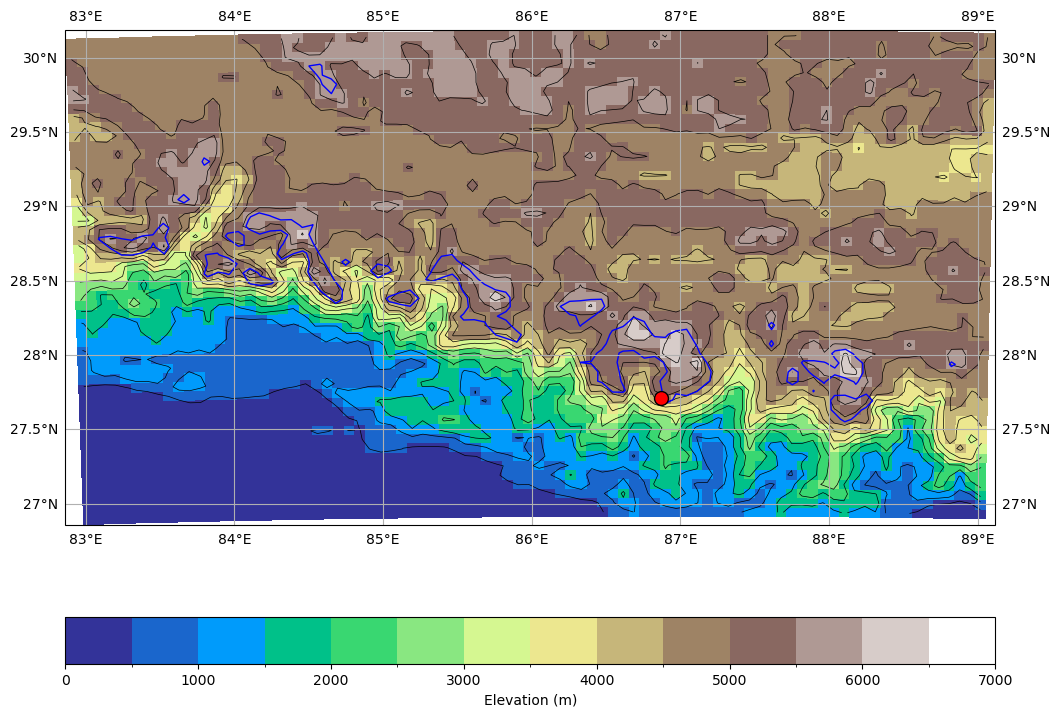

In [7]:
ice_level = 40 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tous les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Topographie ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                   cmap=cmap, norm=norm, # Affiche la couleur de la topographie
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Elevation (m)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

# Carte de la région du Mera 

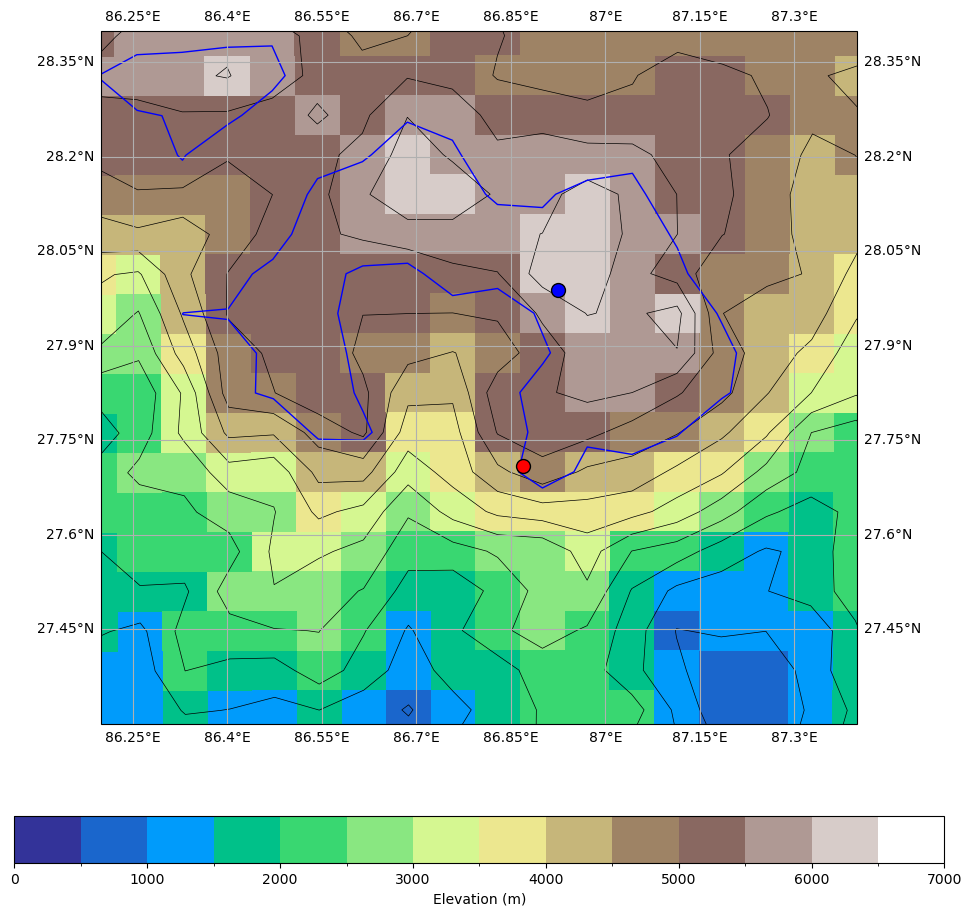

In [8]:
ice_level = 40 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tous les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Everest coord ####
ax.plot(everest_lon, everest_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='b',
        transform=ccrs.PlateCarree())

#### Topographie ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                   cmap=cmap, norm=norm, # Affiche la couleur de la topographie
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.4, 27.3, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Elevation (m)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

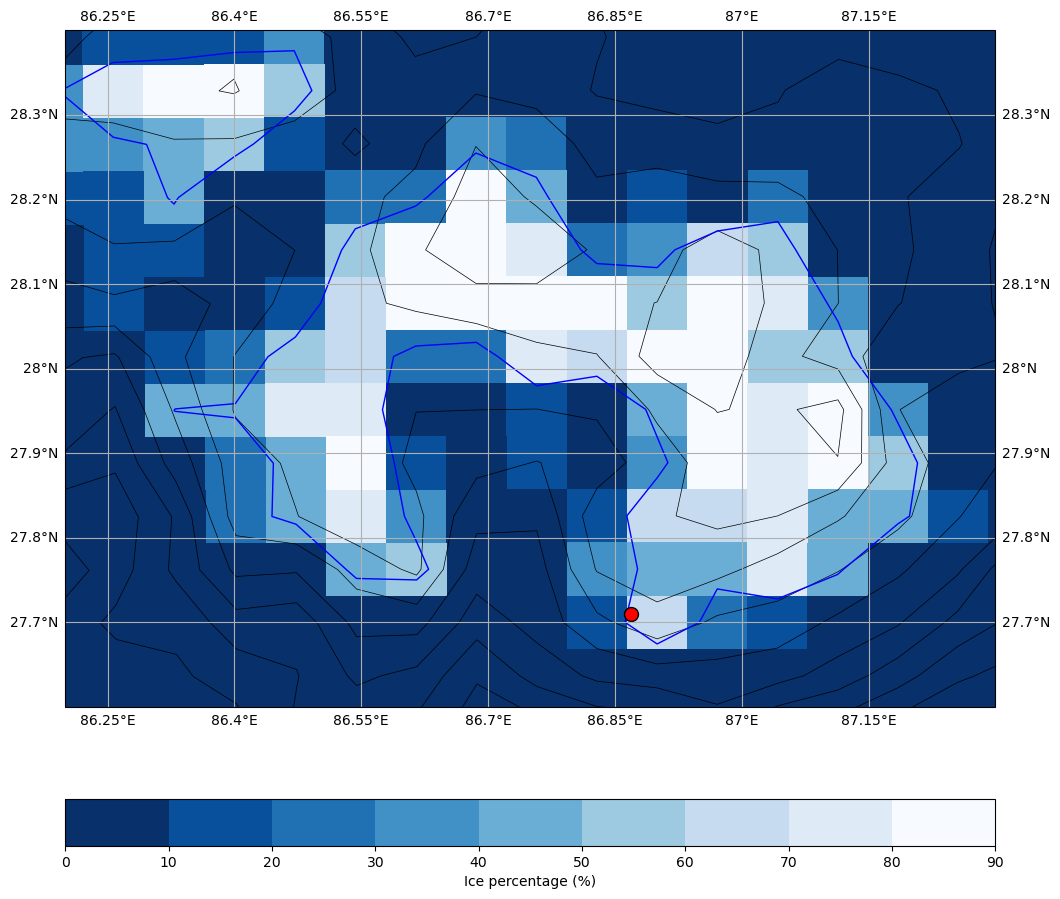

In [9]:
ice_level = 40 # Seuil à partir duquel on considère qu'on observe de la glace

clevs = np.arange(0, 100, 10) # Echelle de couleur de 0 à 100% tous les 10%
cmap = plt.get_cmap("Blues_r") # Palette de couleur bleu (reverse) pour voir le % de glace par grille
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) 


fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

#### Courbes de niveau (tous les 500m) ####
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=[500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000], # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())
#ax.clabel(SH, SH.levels, inline=True, fontsize=6, fmt="%d", inline_spacing=1) # Affiche valeur sur les courbes

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

#### Percentage of ice ####
im = ax.pcolormesh(ds_lon, ds_lat, ds_ICE,
                   cmap=cmap, norm=norm, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 
#ax.set_extent([86.7, 87.1, 27.6, 27.9], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable zoom

ax.gridlines(draw_labels=True) # Grille de lattitude et longitude
plt.colorbar(im, orientation="horizontal", pad=0.1, label="Ice percentage (%)") # Paramètres de la barre d'altitude (disposition horizontale / taille / légende)
plt.show()

### Identification des indices X et Y de la grille correspondant au glacier Mera 
#### C'est à dire le point de grille le plus proche des coordonnées réelles


In [10]:
#### Récupération des indices de la grille pour afficher des variables uniquement sur cette grille ####

dist = np.sqrt((ds_lat - merap_lat)**2 + (ds_lon - merap_lon)**2) # Calcul des distances entre les centres des grilles et coordonnées du Mera Peak
 
# index 1D du minimum
idx_1d = dist.argmin().item() # Recherche de la distance minimale avec argmin

# conversion en indices 2D (Y,X) 
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude trouvée :", ds_lat[iY, iX].item())
print("Longitude trouvée :", ds_lon[iY, iX].item())

Indice Y : 12
Indice X : 55
Latitude trouvée : 27.69999885559082
Longitude trouvée : 86.89999389648438


In [11]:
"""print(ds_TT_surf.dims)
print(ds_grM.TT.dims)
print(ds_grM.TT.time.values[:100])

plt.figure(figsize=(10,5))
ds_TT = ds_grM.TT.isel(y=iY, x=iX) - 273.15 
ds_TT.plot()

plt.title("TTZ – Mera grid")
plt.ylabel("TTZ (°C)")
plt.show()"""

'print(ds_TT_surf.dims)\nprint(ds_grM.TT.dims)\nprint(ds_grM.TT.time.values[:100])\n\nplt.figure(figsize=(10,5))\nds_TT = ds_grM.TT.isel(y=iY, x=iX) - 273.15 \nds_TT.plot()\n\nplt.title("TTZ – Mera grid")\nplt.ylabel("TTZ (°C)")\nplt.show()'

# Temperature de surface de la grille du Mera

In [12]:
variable = 'TTZ'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' # Chemin vers les fichiers contenant les données
file = variable+'_day_MARv3.14_ER5_spin2_GRq_1980-2024.nc' # Fichier de données sur la période 1980-2024 pour la 'variable' associée

ds_TTZ = xr.open_dataset(DataPath+file) 
ds_TTZ_surf = ds_TTZ.isel(ZTQLEV=0).TTZ.load() # ZTQLEV indique le niveau observé (ici 0=surface ?)

ds_TTZ_surf = ds_TTZ_surf[:,k:-k,k:-k] # Correction des effets de bord (k pixel)

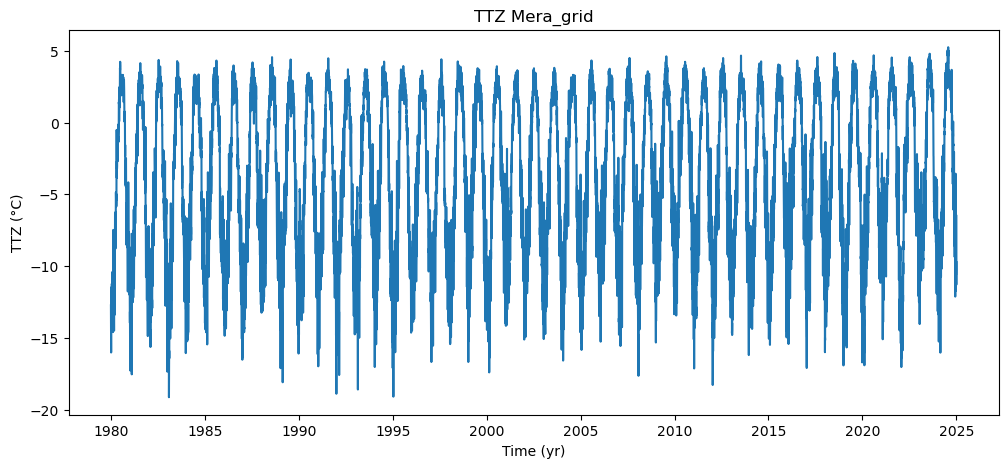

In [13]:
# Plot de la temperature de surface (ZTQLEV=0) du point de grille du Mera glacier
plt.figure(figsize=(12,5))

ds_TTZ_surf.isel(Y=iY, X=iX).plot() # Affiche la temperature pour la grille à l'index iY,iX

plt.title("TTZ Mera_grid")
plt.ylabel("TTZ (°C)")
plt.xlabel("Time (yr)")
plt.show()

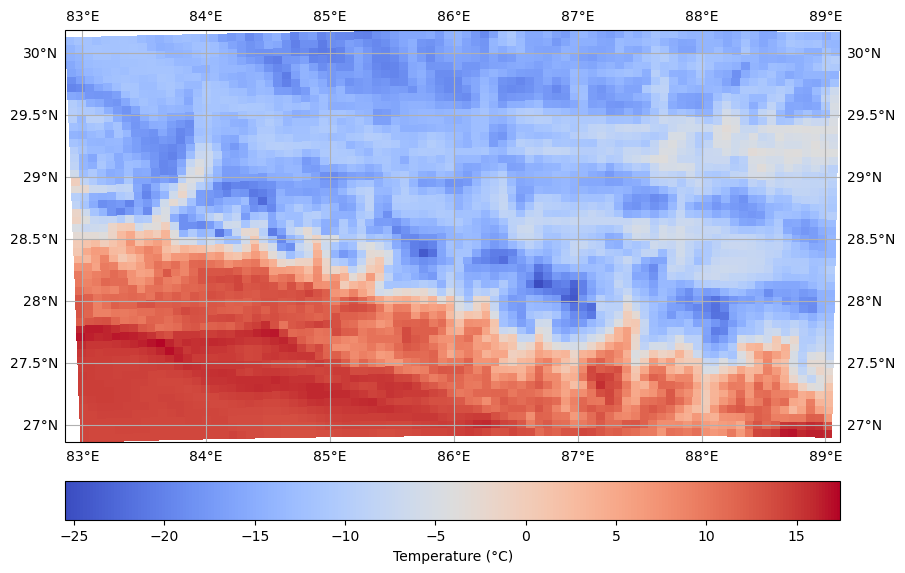

In [14]:
# isel() selectionne l'index dans un tableau --> level=0 sélectionne le niveau vertical 0 --> time=0 est le premier temps du fichier
# Faire .TTZ.isel() permet de passer de xarray.Dataset en xarray.DataArray --> On ne sélectionne qu'une variable qu'on peut afficher avec pcolormesh après
ds_TTZ_map = ds_TTZ.TTZ.isel(TIME=0, ZTQLEV=0)[k:-k, k:-k] # Correction longitude latitude sur la variable

fig, ax = plt.subplots(figsize=(10,10),
                       subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(ds_lon, 
                   ds_lat, 
                   ds_TTZ_map, 
                   cmap="coolwarm", 
                   shading="auto",
                   transform=ccrs.PlateCarree())

ax.gridlines(draw_labels=True)

plt.colorbar(im, orientation="horizontal", pad=0.05, label="Temperature (°C)")
plt.show()

# SMB de la grille correspondant au glacier Mera

In [15]:
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 
file = variable+'_day_MARv3.14_ER5_spin2_GRq_1980-2024.nc'

ds_SMB = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
ds_SMB = ds_SMB[:,k:-k,k:-k]

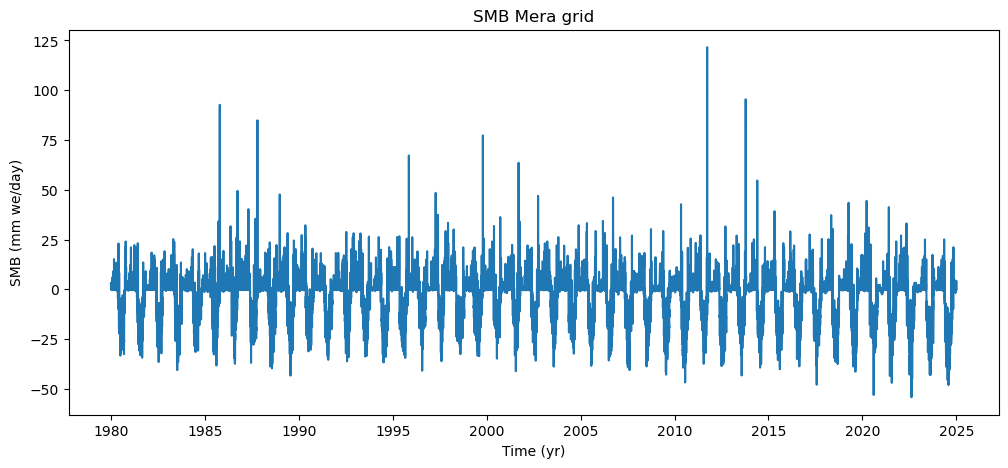

In [16]:
# Plot du SMB du point de grille du Mera glacier
plt.figure(figsize=(12,5))

ds_SMB.isel(Y=iY, X=iX).plot() 

plt.title("SMB Mera grid")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (yr)")
plt.show()

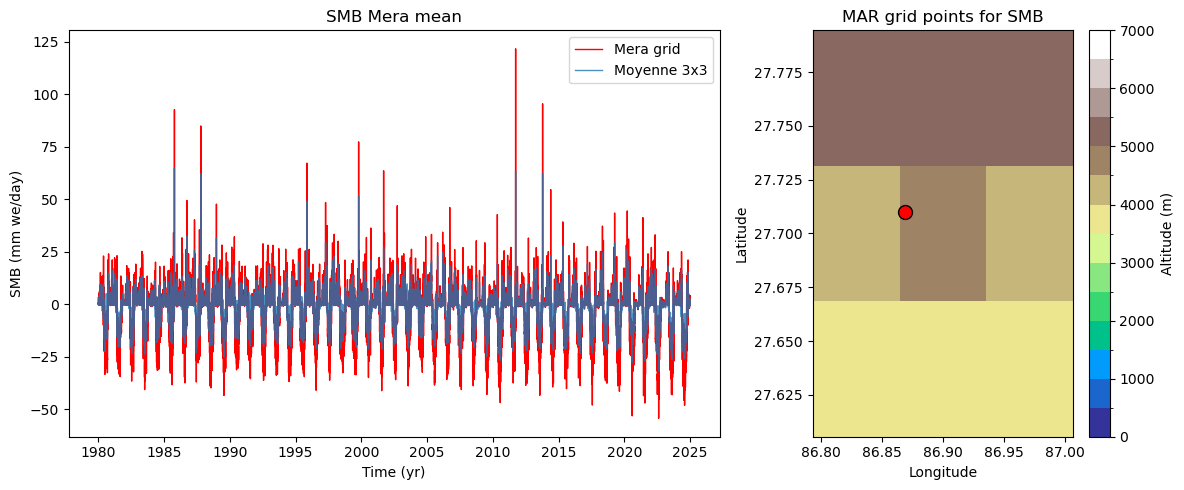

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), gridspec_kw={'width_ratios': [2, 1]}) # Défini le ratio de taille entre les deux figures

###### SMB time series ######
plt.sca(axes[0])
ds_SMB.isel(Y=iY, X=iX).plot(label="Mera grid", linewidth=1, color='r') # Plot le SMB de la grille Mera

# Slice permet d'extraire les points voisins au point iY,iX (le dernier indice iX est exclu) et mean fait la moyenne des SMB du bloc
ds_SMB.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2)).mean(dim=["Y", "X"]).plot(label="Moyenne 3x3", linewidth=1, alpha=0.8) # Moyenne de la grille Mera et ses voisins proches

plt.title("SMB Mera mean")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (yr)")
plt.legend()

####### Grid ######
plt.sca(axes[1])
ds_SH2 = ds_SH.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)) # Selectionne le SMB sur les grilles données
ds_lat_mera2 = ds_lat.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)) # Selectionne les lon lat pour les plot
ds_lon_mera2 = ds_lon.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

plt.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

plt.pcolormesh(ds_lon_mera2, ds_lat_mera2, ds_SH2, cmap=cmap, norm=norm, shading='auto')
#plt.pcolormesh(x, y, ds_SH3X3, cmap='terrain', shading='auto', vmin=0, vmax=7000) # Pour ne pas lisser l'échelle d'altitude
plt.colorbar(label="Altitude (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("MAR grid points for SMB")
plt.tight_layout()

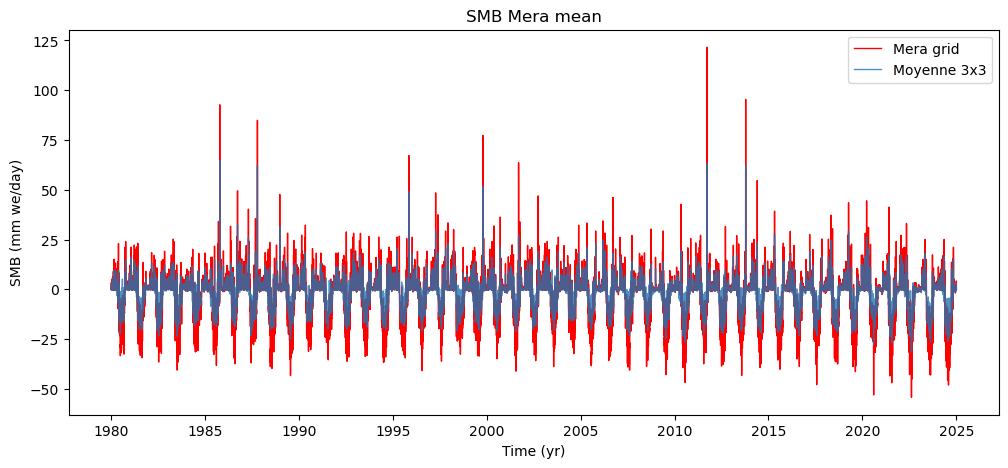

In [18]:
plt.figure(figsize=(12,5))

ds_SMB.isel(Y=iY, X=iX).plot(label="Mera grid", linewidth=1, color='r') # Plot le SMB de la grille Mera

# Slice permet d'extraire les points voisins au point iY,iX (le dernier indice iX est exclu) et mean fait la moyenne des SMB du bloc
ds_SMB.isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2)).mean(dim=["Y", "X"]).plot(label="Moyenne 3x3", linewidth=1, alpha=0.8) # Moyenne de la grille Mera et ses voisins proches

plt.title("SMB Mera mean")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (yr)")
plt.legend()
plt.show()

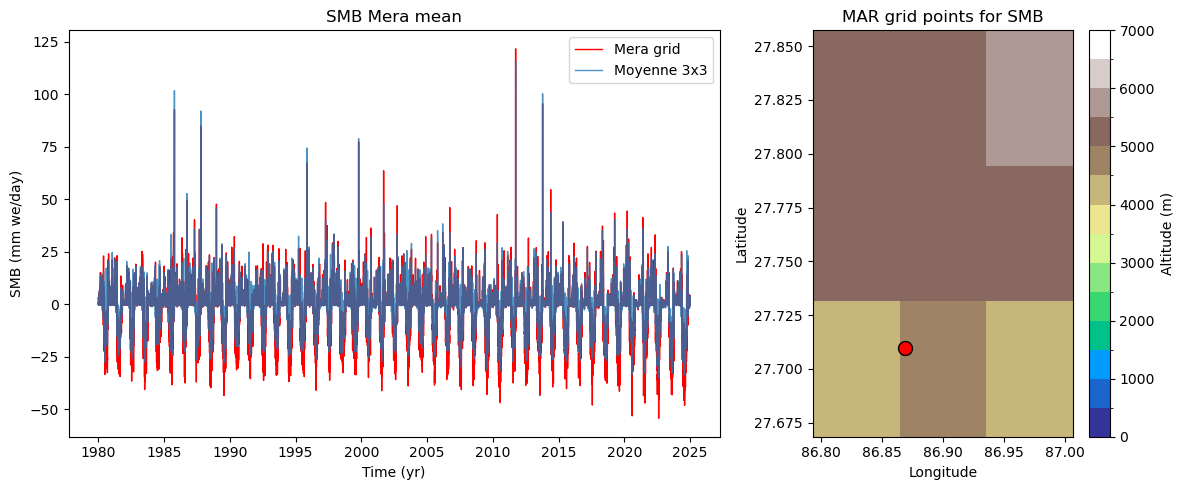

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), gridspec_kw={'width_ratios': [2, 1]}) # Défini le ratio de taille entre les deux figures

###### SMB time series ######
plt.sca(axes[0])
ds_SMB.isel(Y=iY, X=iX).plot(label="Mera grid", linewidth=1, color='r') # Plot le SMB de la grille Mera

# Slice permet d'extraire les points voisins au point iY,iX (le dernier indice iX est exclu) et mean fait la moyenne des SMB du bloc
ds_SMB.isel(Y=slice(iY, iY+3), X=slice(iX-1, iX+2)).mean(dim=["Y", "X"]).plot(label="Moyenne 3x3", linewidth=1, alpha=0.8) # Moyenne de la grille Mera et ses voisins (au nord?!)

plt.title("SMB Mera mean")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (yr)")
plt.legend()

####### Grid ######
plt.sca(axes[1])
ds_SH3 = ds_SH.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)) # /!\/!\/!\ Ici 'y' est lu de bas en haut comme dans meshgrid. Cherher à afficher des points au dessus de Mera grid revient à ajouter des indices à 'y'
ds_lat_mera3 = ds_lat.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)) # Selectionne les lon lat pour les plot
ds_lon_mera3 = ds_lon.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"
plt.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

plt.pcolormesh(ds_lon_mera3, ds_lat_mera3, ds_SH3, cmap=cmap, norm=norm, shading='auto')
#plt.pcolormesh(x, y, ds_SH3X3UP, cmap='terrain', shading='auto', vmin=0, vmax=7000) # Pour ne pas lisser l'échelle d'altitude
plt.colorbar(label="Altitude (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("MAR grid points for SMB")
plt.tight_layout()

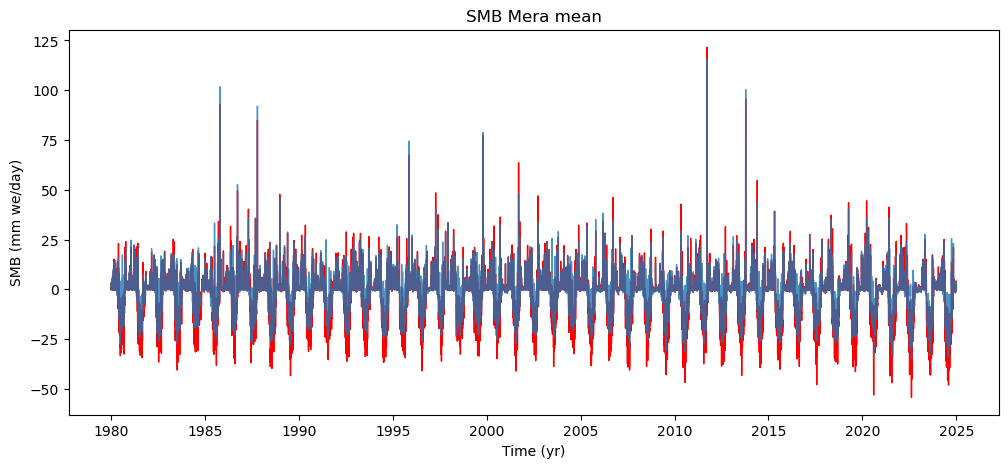

In [20]:
plt.figure(figsize=(12,5))

ds_SMB.isel(Y=iY, X=iX).plot(label="Mera grid", linewidth=1, color='r') # Plot le SMB de la grille Mera

ds_SMB.isel(Y=slice(iY, iY+3), X=slice(iX-1, iX+2)).mean(dim=["Y", "X"]).plot(label="Moyenne 3x3", linewidth=1, alpha=0.8) # Moyenne de la grille Mera et ses voisins (au nord?!)

plt.title("SMB Mera mean")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (yr)")
plt.show()

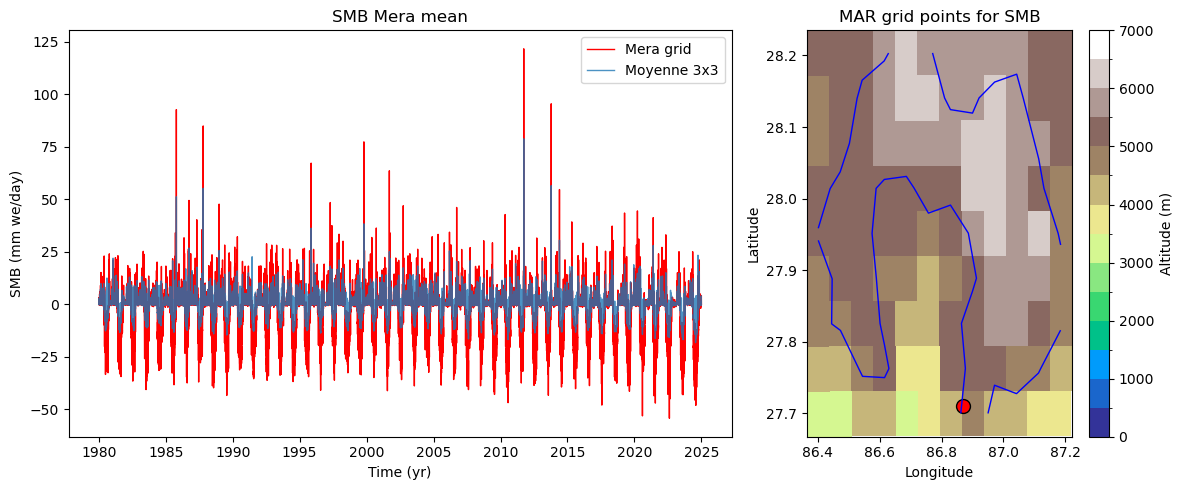

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), gridspec_kw={'width_ratios': [2, 1]}) # Défini le ratio de taille entre les deux figures

###### SMB time series ######
plt.sca(axes[0])
ds_SMB.isel(Y=iY, X=iX).plot(label="Mera grid", linewidth=1, color='r') # Plot le SMB de la grille Mera

# Slice permet d'extraire les points voisins au point iY,iX (le dernier indice iX est exclu) et mean fait la moyenne des SMB du bloc
ds_SMB.isel(Y=slice(iY, iY+9), X=slice(iX-7, iX+5)).mean(dim=["Y", "X"]).plot(label="Moyenne 3x3", linewidth=1, alpha=0.8) # Moyenne de la grille Mera et ses voisins (au nord?!)

plt.title("SMB Mera mean")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (yr)")
plt.legend()

####### Grid ######
plt.sca(axes[1])
ds_SH_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # /!\/!\/!\ Ici 'y' est lu de bas en haut comme dans meshgrid. Cherher à afficher des points au dessus de Mera grid revient à ajouter des indices à 'y'
ds_ICE_khumbu = ds_ICE.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5))
ds_lat_khumbu = ds_lat.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"
plt.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers

plt.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
#plt.pcolormesh(x, y, ds_SH3X3UP, cmap='terrain', shading='auto', vmin=0, vmax=7000) # Pour ne pas lisser l'échelle d'altitude
plt.colorbar(label="Altitude (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("MAR grid points for SMB")
plt.tight_layout()

In [22]:
SMB_day = ds_SMB.isel(TIME=100, Y=iY, X=iX) # Valeur du SMB au 100 jour de la série (10/04/1980)

print(SMB_day.values)
print(ds_SMB.TIME[100].values)

3.0039062
1980-04-10T12:00:00.000000000


# SMB Mera grid point for 2007-2008

In [23]:
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 
file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_2007.nc'

ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
ds_SMBy = ds_SMBy[:,k:-k,k:-k]

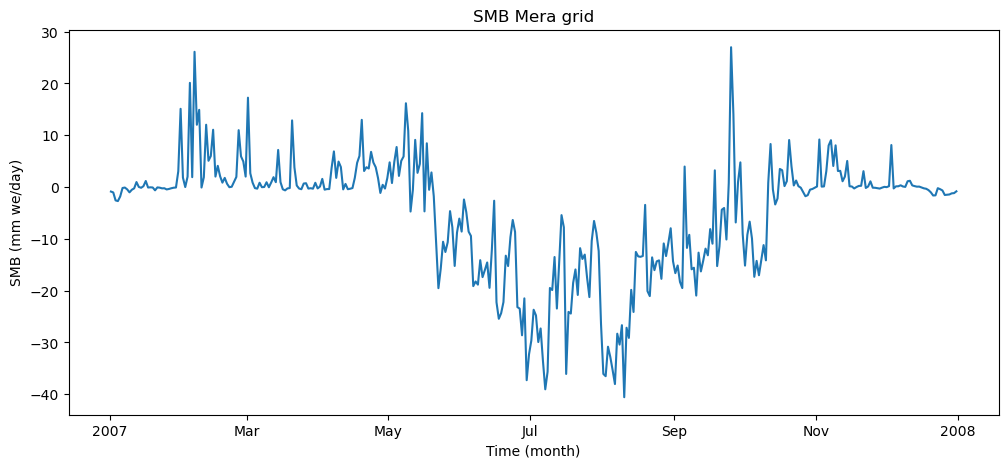

In [24]:
# Plot du SMB du point de grille du Mera glacier
plt.figure(figsize=(12,5))

ds_SMBy.isel(Y=iY, X=iX).plot() 

plt.title("SMB Mera grid")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (month)")
plt.show()

# SMB Mera grid point for novembre_decemebre 2007

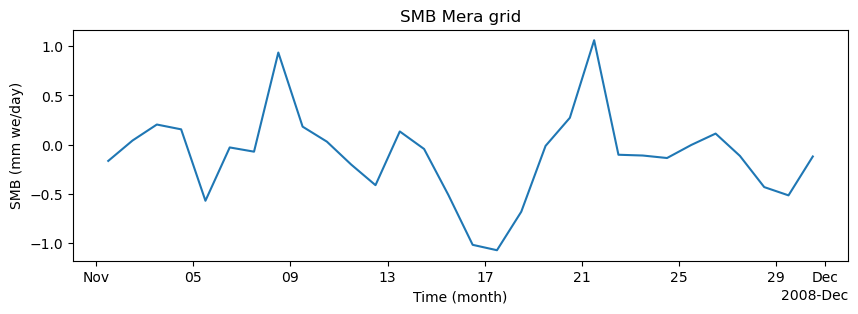

In [25]:
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 
file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_2008.nc'

ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # SECTOR ?
ds_SMBy = ds_SMBy[:,k:-k,k:-k]

# Plot du SMB du point de grille du Mera glacier sur Novembre
plt.figure(figsize=(10,3))

ds_SMBy.sel(TIME=ds_SMBy.TIME.dt.month == 11).isel(Y=iY, X=iX).plot() # dt.month récupère les valeurs des mois dans la série (ici 11ème mois)

plt.title("SMB Mera grid")
plt.ylabel("SMB (mm we/day)")
plt.xlabel("Time (month)")
plt.show()

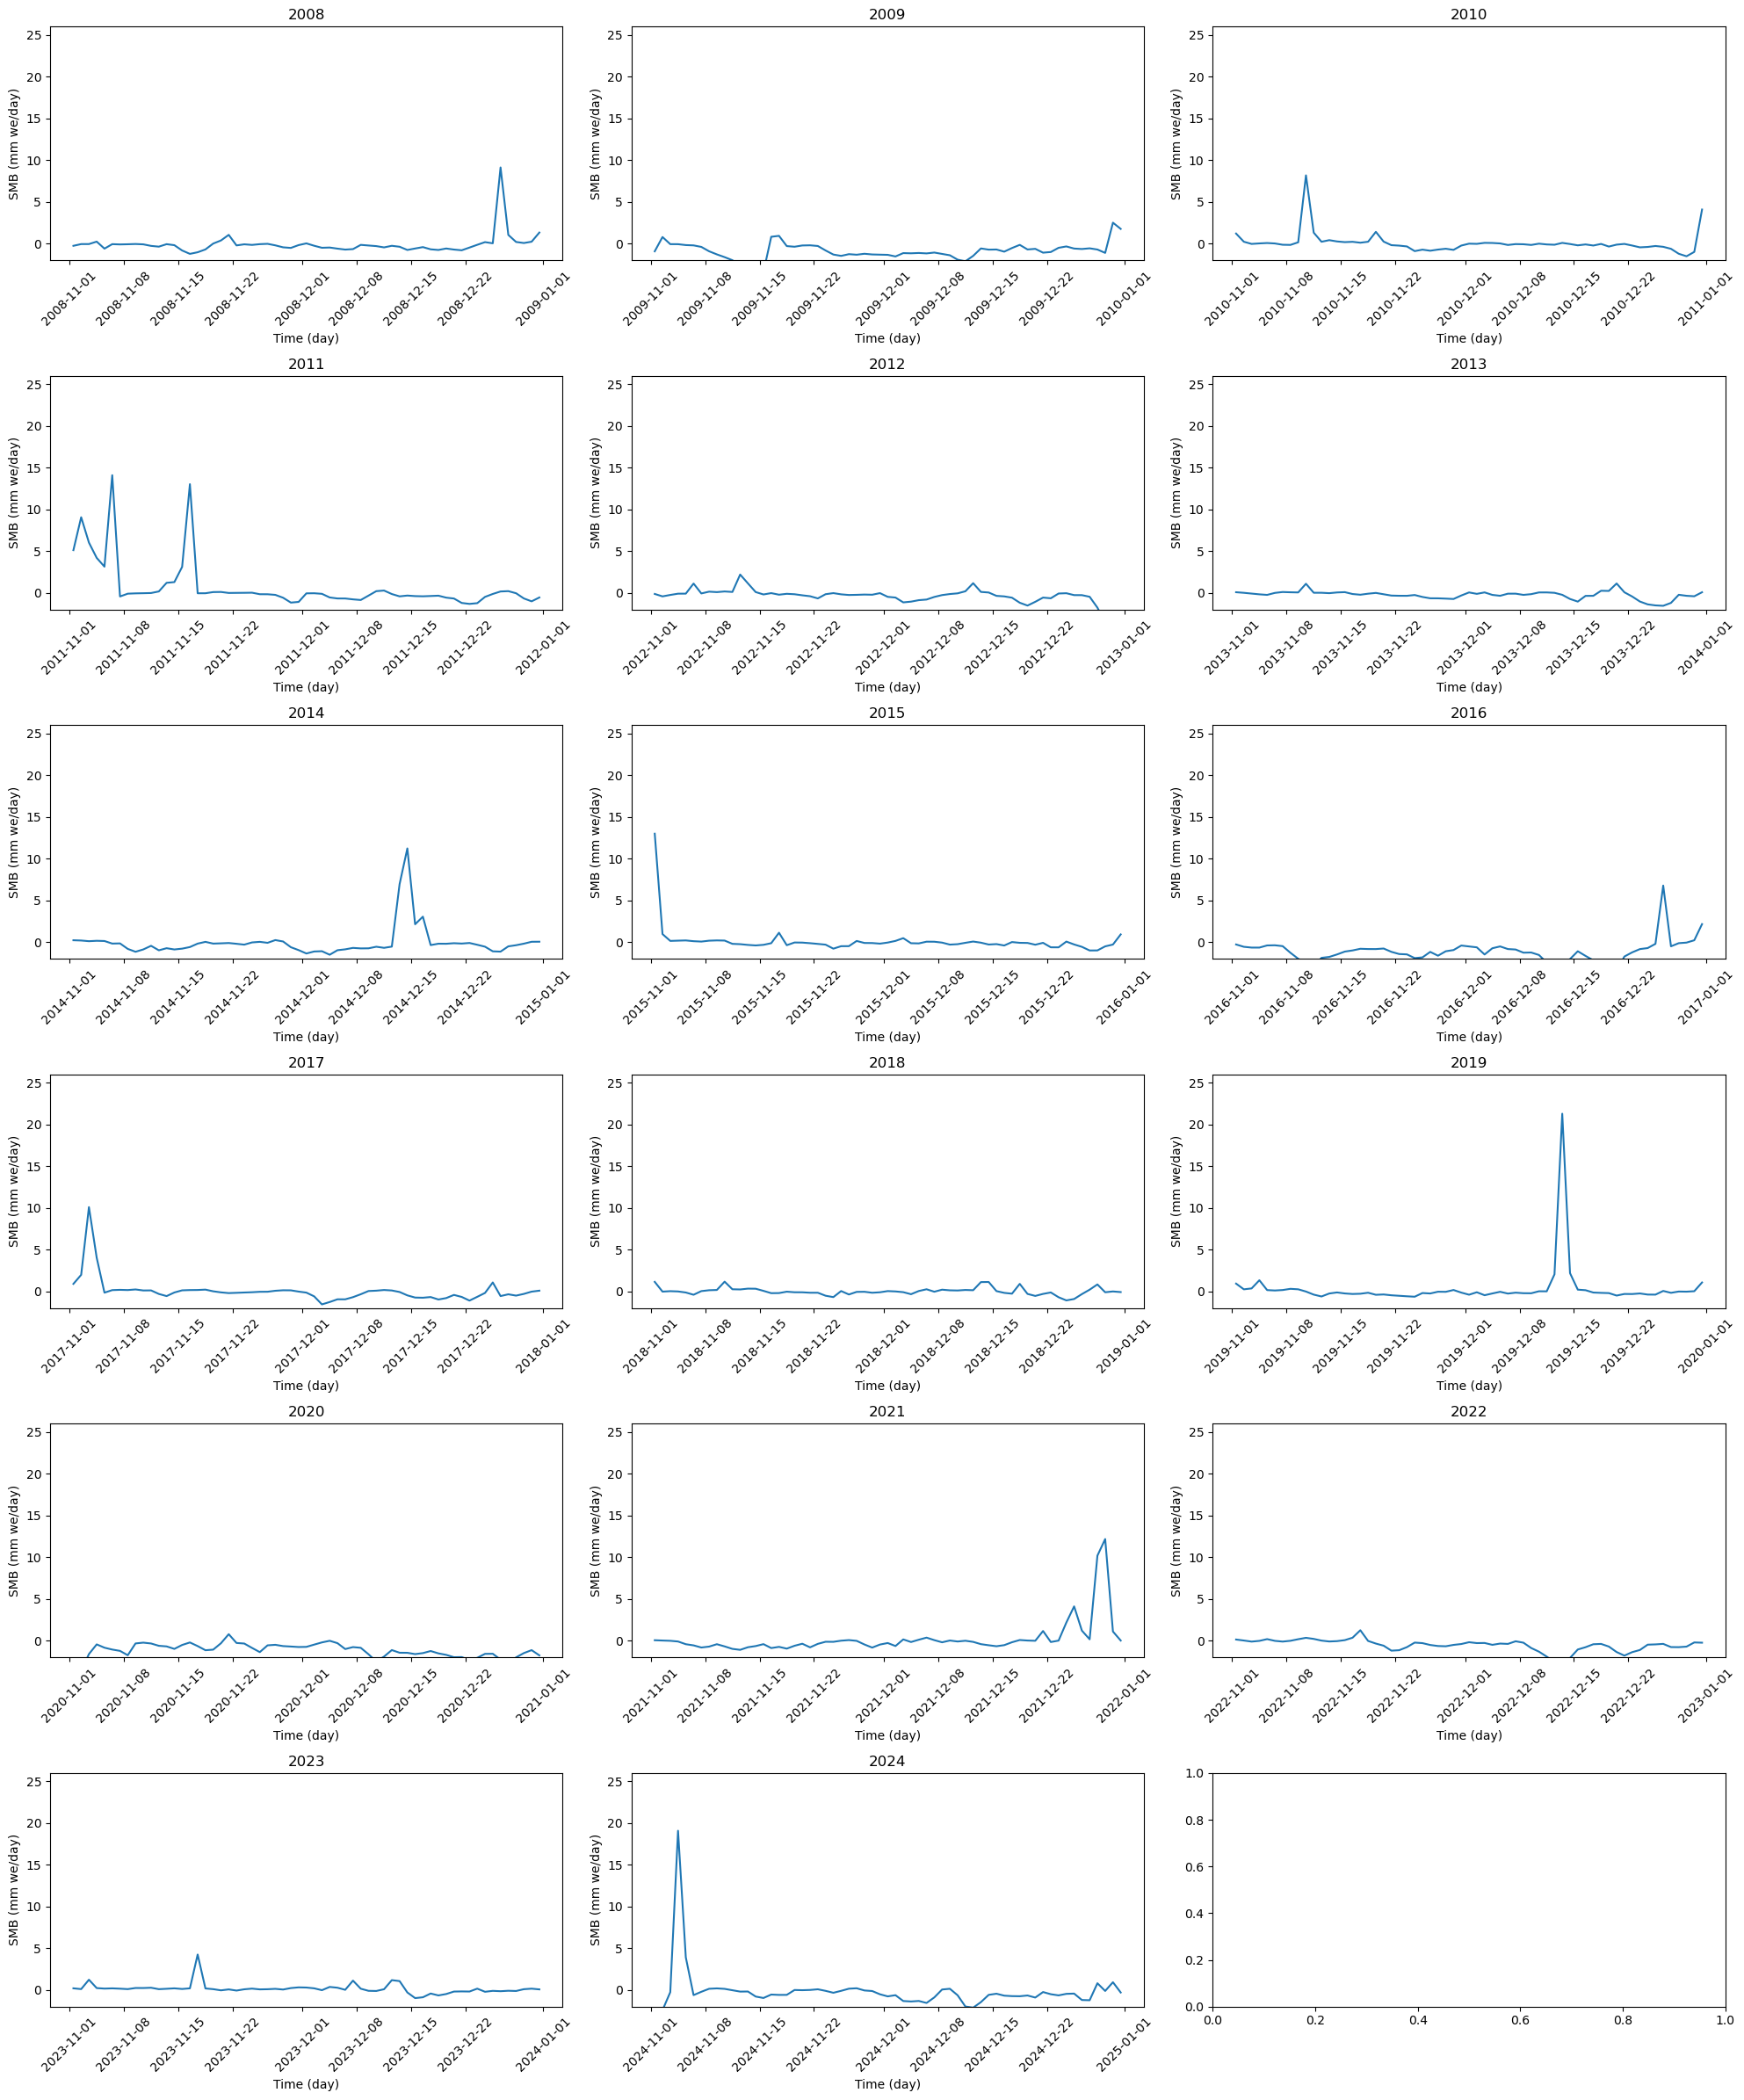

In [26]:
### SMB variability in November and December
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(20,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


for j in range(n):
    ax = axes[j] 
    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'

    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]

    # Plot du SMB du point de grille du Mera glacier sur Novembre
    ds_SMBm = ds_SMBy.sel(TIME= (ds_SMBy.TIME.dt.month == 11) | (ds_SMBy.TIME.dt.month == 12)).isel(Y=iY, X=iX) # dt.month récupère les valeurs des mois dans la série (ici 11ème mois)
    
    ax.plot(ds_SMBm.TIME, ds_SMBm) # Plot la série temporelle associée à la variable SMB
    ax.set_ylim(-2, 26) # Restriction du domaine 
    ax.tick_params(axis='x', rotation=45) # Met à 45° les dates affichés
    
    ax.set_title(f"20{yy[j+1]}")
    ax.set_ylabel("SMB (mm we/day)")
    ax.set_xlabel("Time (day)")

plt.tight_layout()

 ## Attention, ici j'ai choisi 'iloc[4]', cad prends la 4ème valeur de la colonne arbitrairement, mais il faudrait faire une moyenne pondérée sur tous les jours d'acquisitions

SMB_MAR07-08 = -1.2976035 m w.e/yr
SMB_MAR08-09 = -1.847461 m w.e/yr
SMB_MAR09-10 = -2.1969433 m w.e/yr
SMB_MAR10-11 = -1.1478868 m w.e/yr
SMB_MAR11-12 = -2.1298008 m w.e/yr
SMB_MAR12-13 = -1.2639941 m w.e/yr
SMB_MAR13-14 = -1.5904101 m w.e/yr
SMB_MAR14-15 = -1.9338906 m w.e/yr
SMB_MAR15-16 = -1.708416 m w.e/yr
SMB_MAR16-17 = -2.1635098 m w.e/yr
SMB_MAR17-18 = -1.728916 m w.e/yr
SMB_MAR18-19 = -1.8564922 m w.e/yr
SMB_MAR19-20 = -1.5654316 m w.e/yr
SMB_MAR20-21 = -1.9348379 m w.e/yr
SMB_MAR21-22 = -2.2361991 m w.e/yr
SMB_MAR22-23 = -2.0383966 m w.e/yr
SMB_MAR23-24 = -2.7864044 m w.e/yr
Grid alt = 4831.3545 m


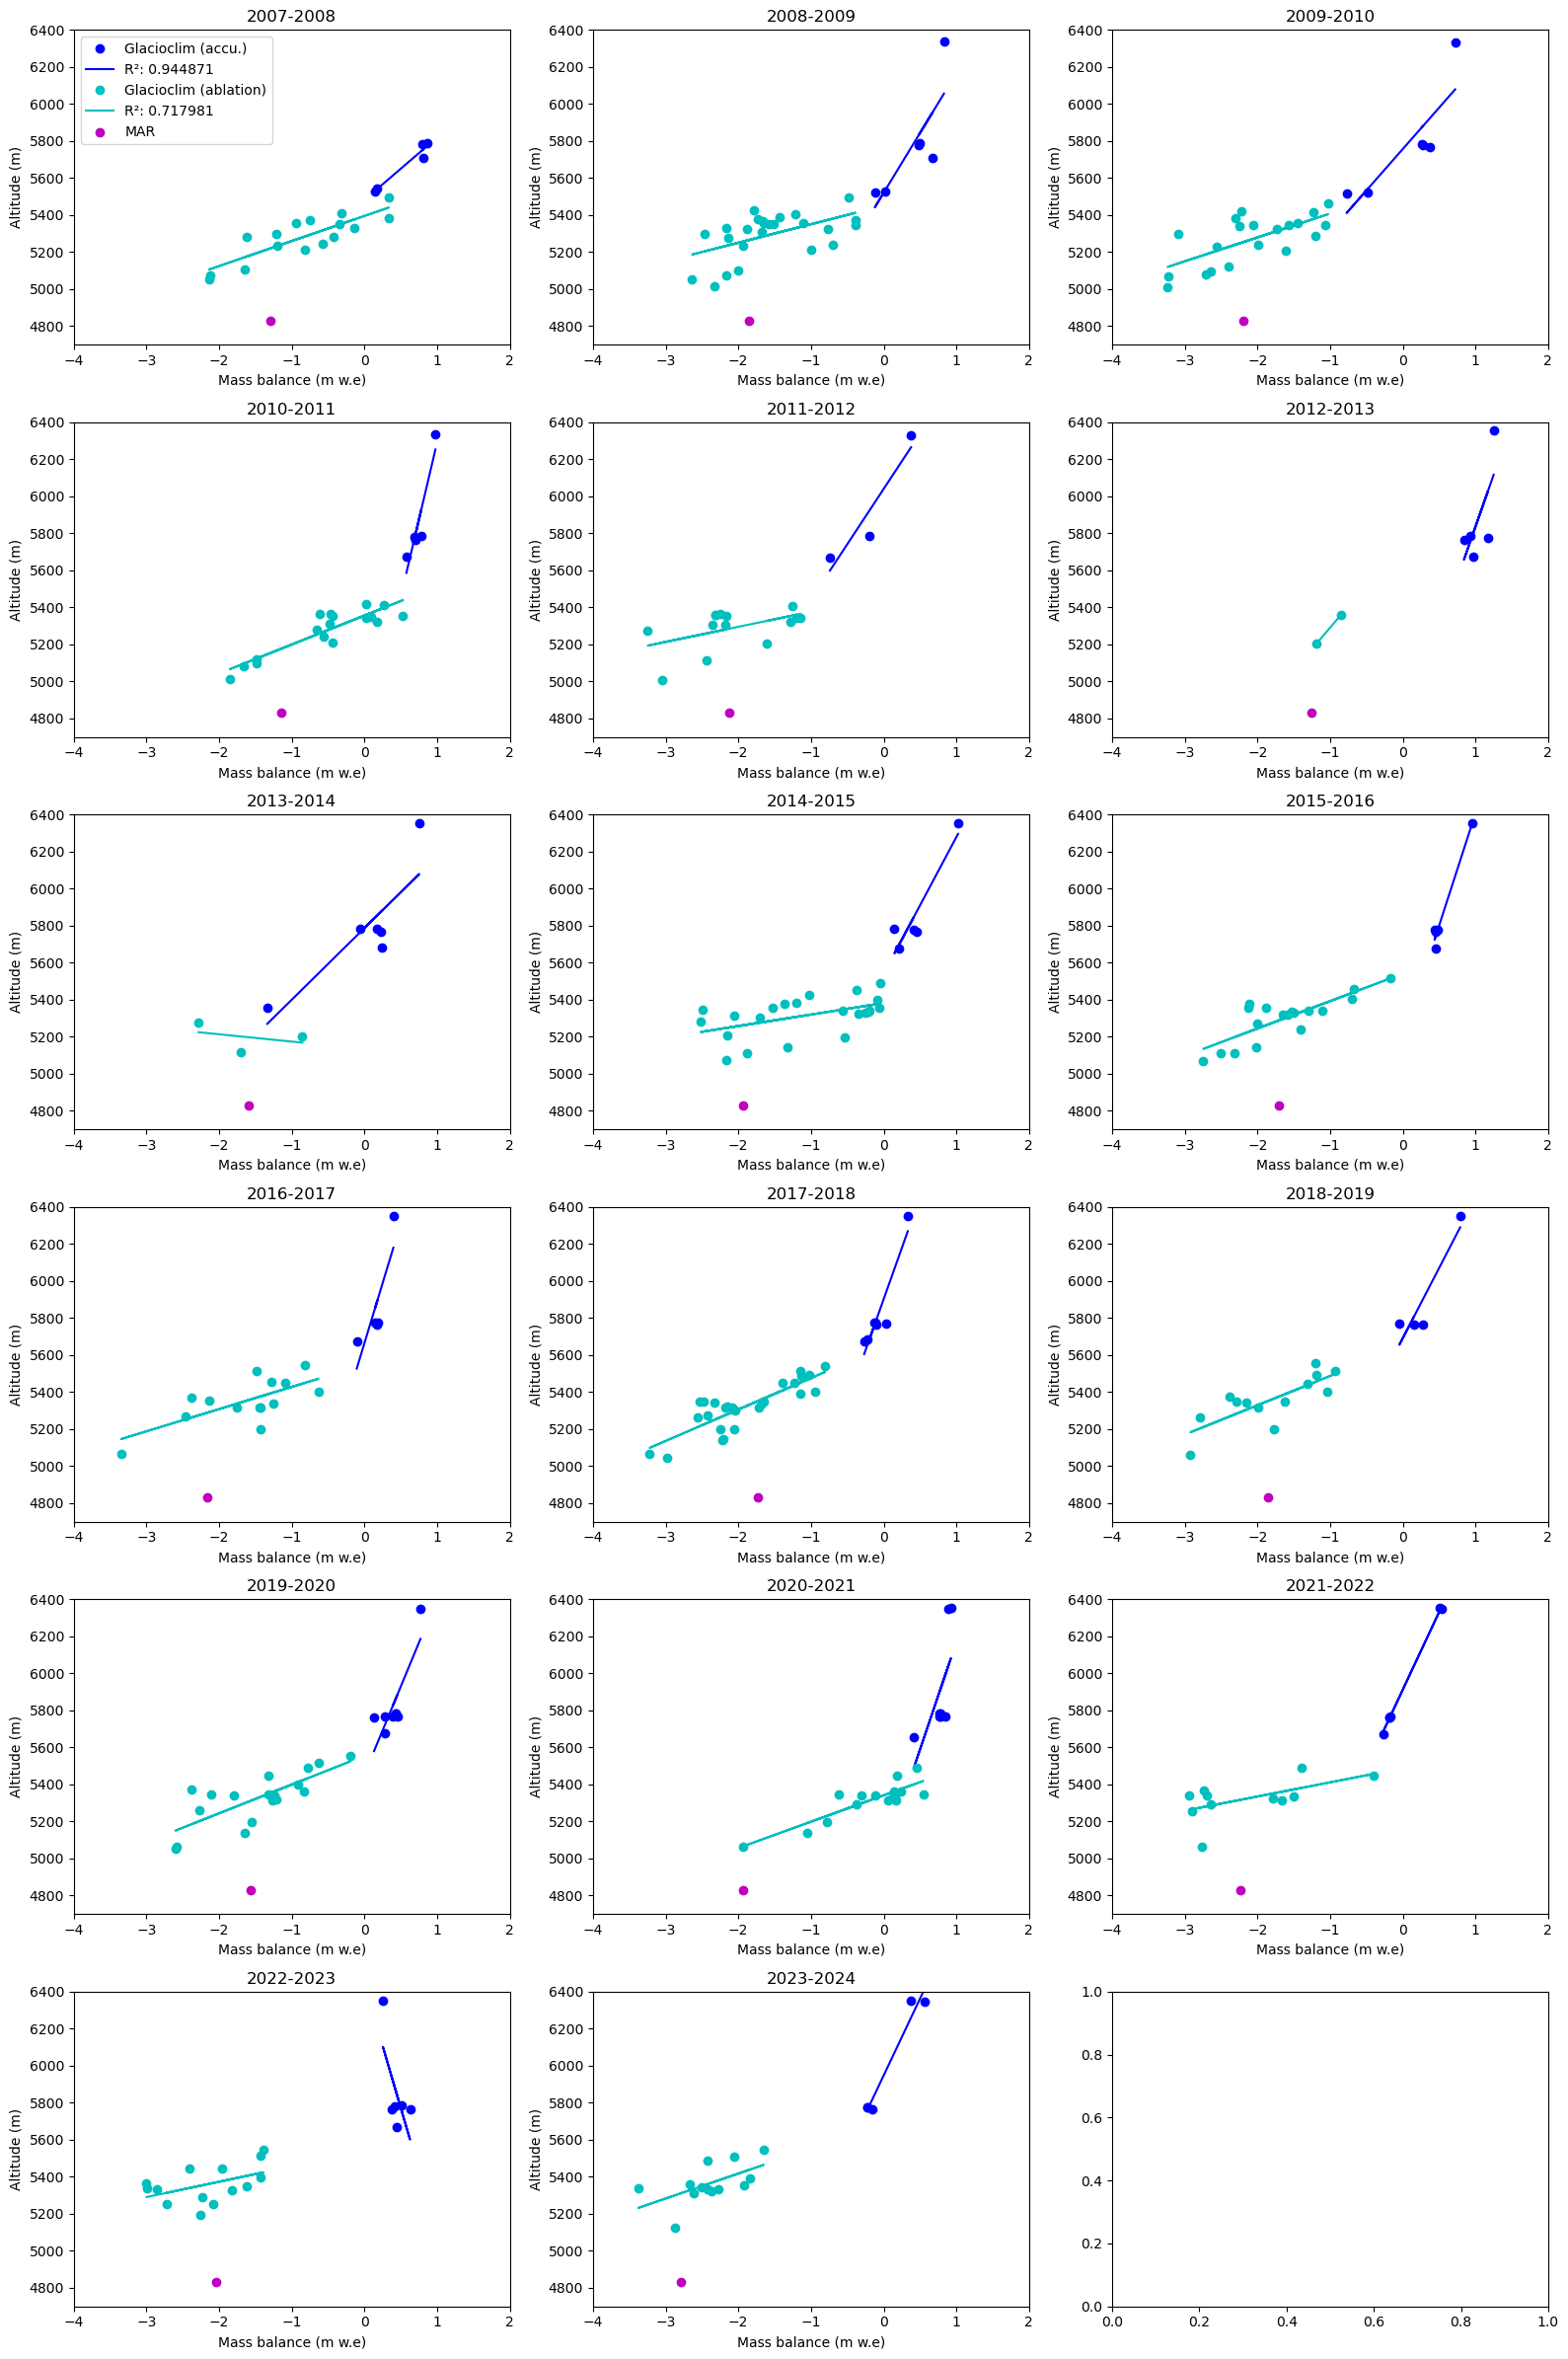

In [27]:
### Mera grid point
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list = []

for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4] # Je pensais que le format de date qui diffère de glacioclim à MAR était un pb, mais excel est bien en format datetime et non texte donc cela fonctionne sans correction

    date_ref = df["Date_start"].iloc[4] # Récupère la précédente date de mesure de SMB pour cette balise

    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        # La régression linéaire contient naturellement des informations comme slope = pente de regression / intercept = ordonnée à l'origine / rvalue = coeff de corrélation / pvalue
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=iY, X=iX) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list.append(SMB_MAR)
    print('SMB_MAR'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR, 'm w.e/yr')
#    print('Date_MAR:', ds_SMBy.sel(TIME=date_obs).TIME.values) # Affiche la date dans le fichier

    SH_MAR = ds_SH.isel(y=iY, x=iX) # Altitude de la grille de MAR au Peak Mera (coord iY,iX)
#    print('Grid alt =', SH_MAR.values, 'm')
    
    ax.scatter(SMB_MAR, SH_MAR, color="m", label="MAR") # Affiche le point de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-4, 2)
    ax.set_ylim(4700, 6400)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()
print('Grid alt =', SH_MAR.values, 'm')
plt.tight_layout()


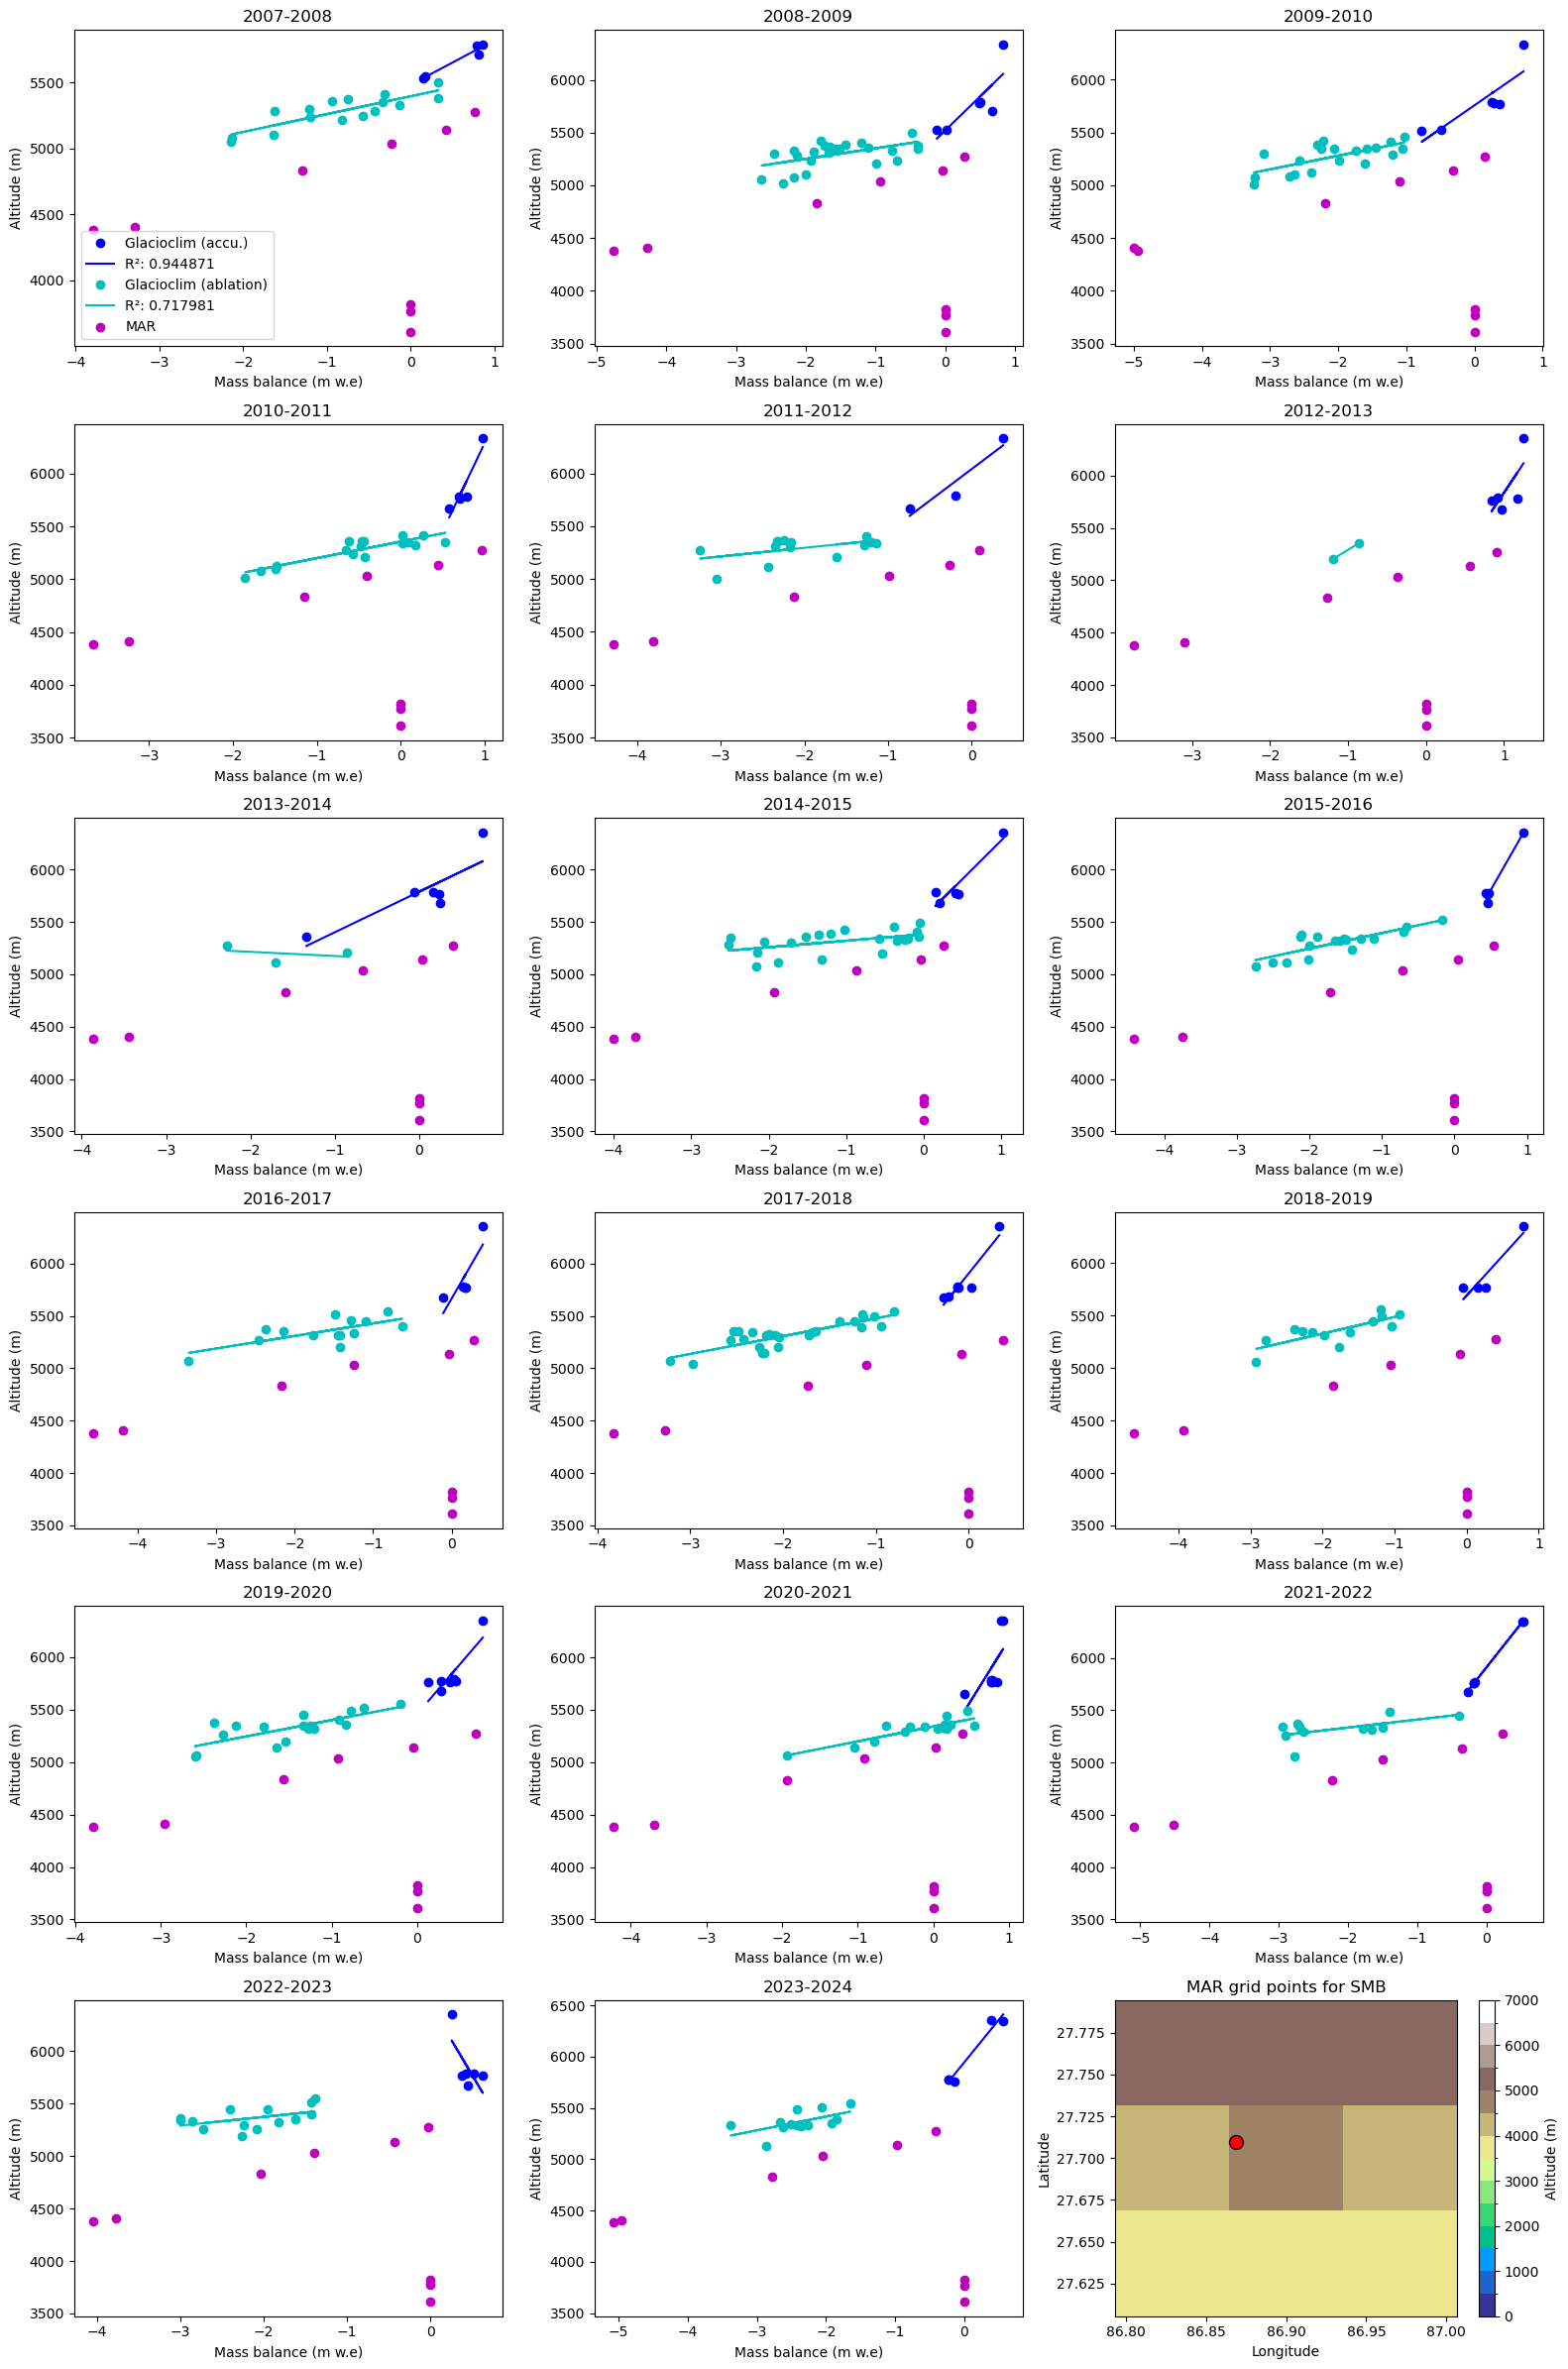

In [28]:
### 3x3 grid around Mera
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))



for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
    date_obs = date_obs.strftime("%Y-%m-%dT%H:%M:%S") # Formate l'écriture de la date au format MAR

    date_ref = df["Date_start"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    date_ref = date_ref.strftime("%Y-%m-%dT%H:%M:%S")
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day2 = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum2 = SMB_day2.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR2 = SMB_sum2.values.flatten() 

    SH_MAR2 = ds_SH.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)).values.flatten() # Altitude des grilles de MAR

    ax.scatter(SMB_MAR2, SH_MAR2, color="m", label="MAR") # Affiche les points de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

####### Grid on last subplot ######
ax = axes[n]
ds_SH2 = ds_SH.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)) # Selectionne le SMB sur les grilles données
ds_lat_mera2 = ds_lat.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)) # Selectionne les lon lat pour les plot
ds_lon_mera2 = ds_lon.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_mera2, ds_lat_mera2, ds_SH2, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")
plt.tight_layout()

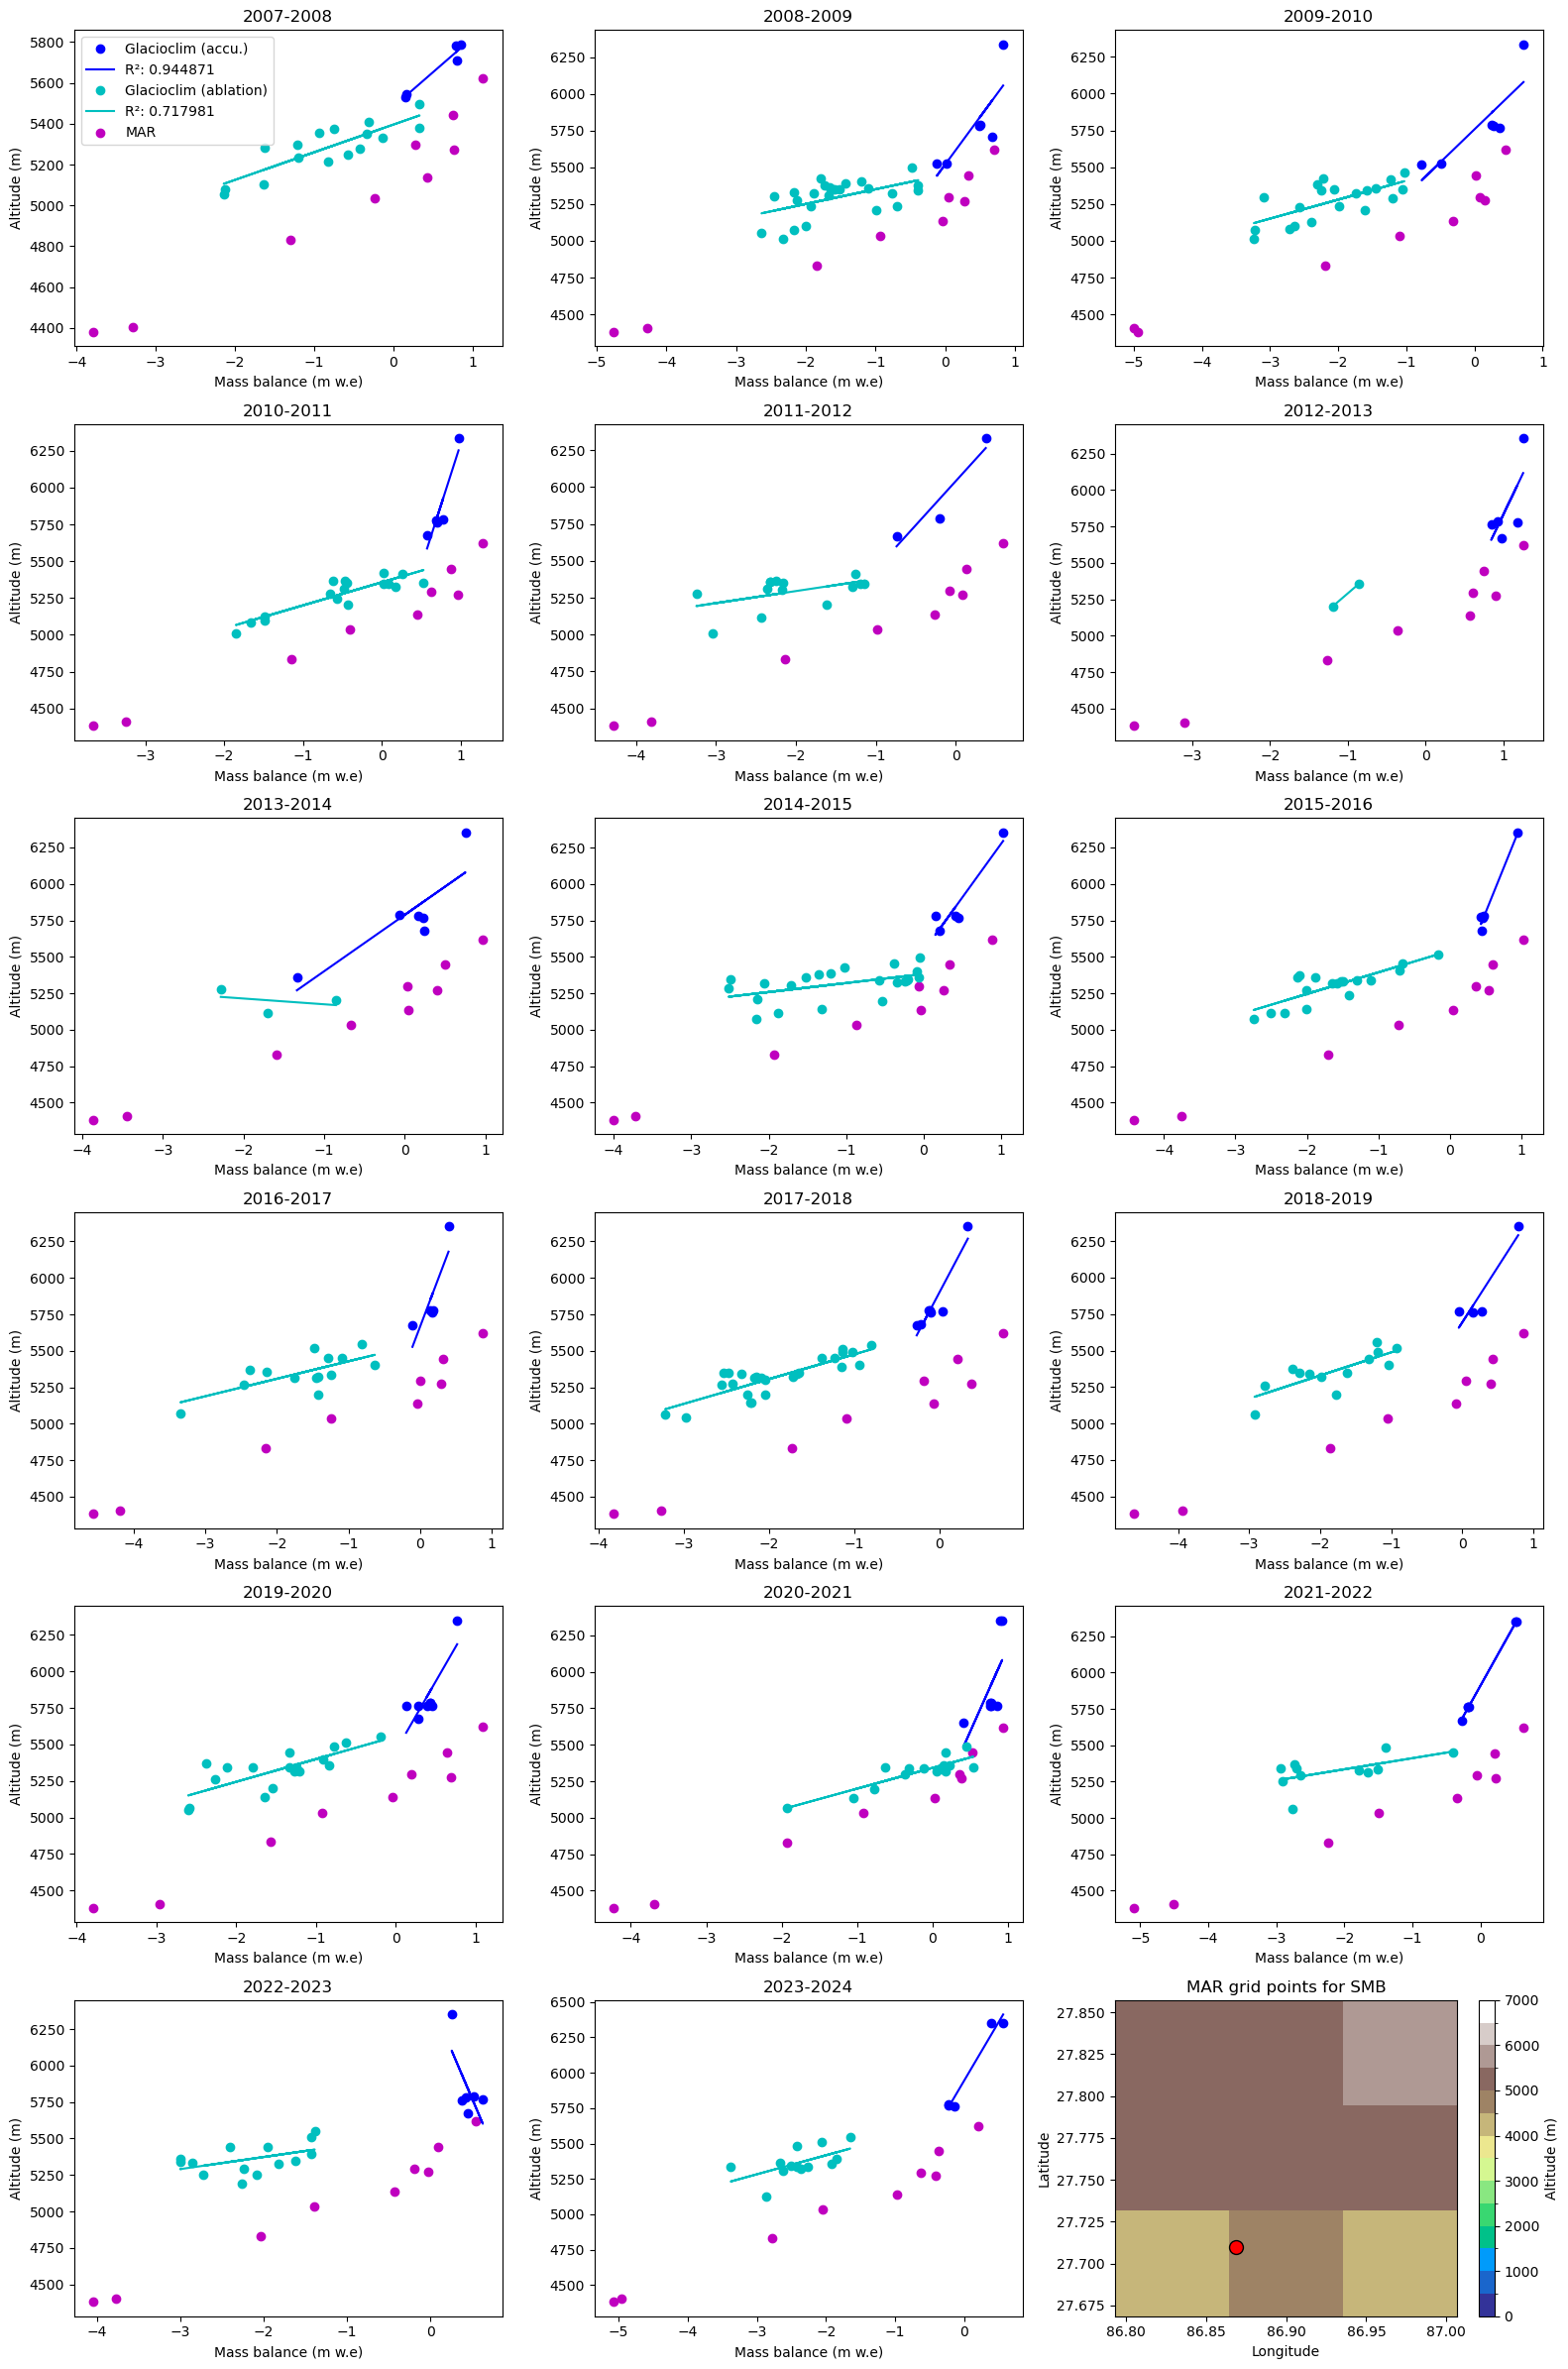

In [29]:
### 3x3 grid North of Mera
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))



for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
    date_obs = date_obs.strftime("%Y-%m-%dT%H:%M:%S") # Formate l'écriture de la date au format MAR
    
    date_ref = df["Date_start"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    date_ref = date_ref.strftime("%Y-%m-%dT%H:%M:%S")
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day3 = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY, iY+3), X=slice(iX-1, iX+2)) # Valeur du SMB à la date exact de l'obs (glacioclim)
    SMB_sum3 = SMB_day3.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR3 = SMB_sum3.values.flatten() 

    SH_MAR3 = ds_SH.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)).values.flatten() # Altitude des grilles de MAR

    ax.scatter(SMB_MAR3, SH_MAR3, color="m", label="MAR") # Affiche les points de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

####### Grid on last subplot ######
ax = axes[n]
ds_SH3 = ds_SH.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)) # Selectionne le SMB sur les grilles données
ds_lat_mera3 = ds_lat.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)) # Selectionne les lon lat pour les plot
ds_lon_mera3 = ds_lon.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_mera3, ds_lat_mera3, ds_SH3, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")
plt.tight_layout()

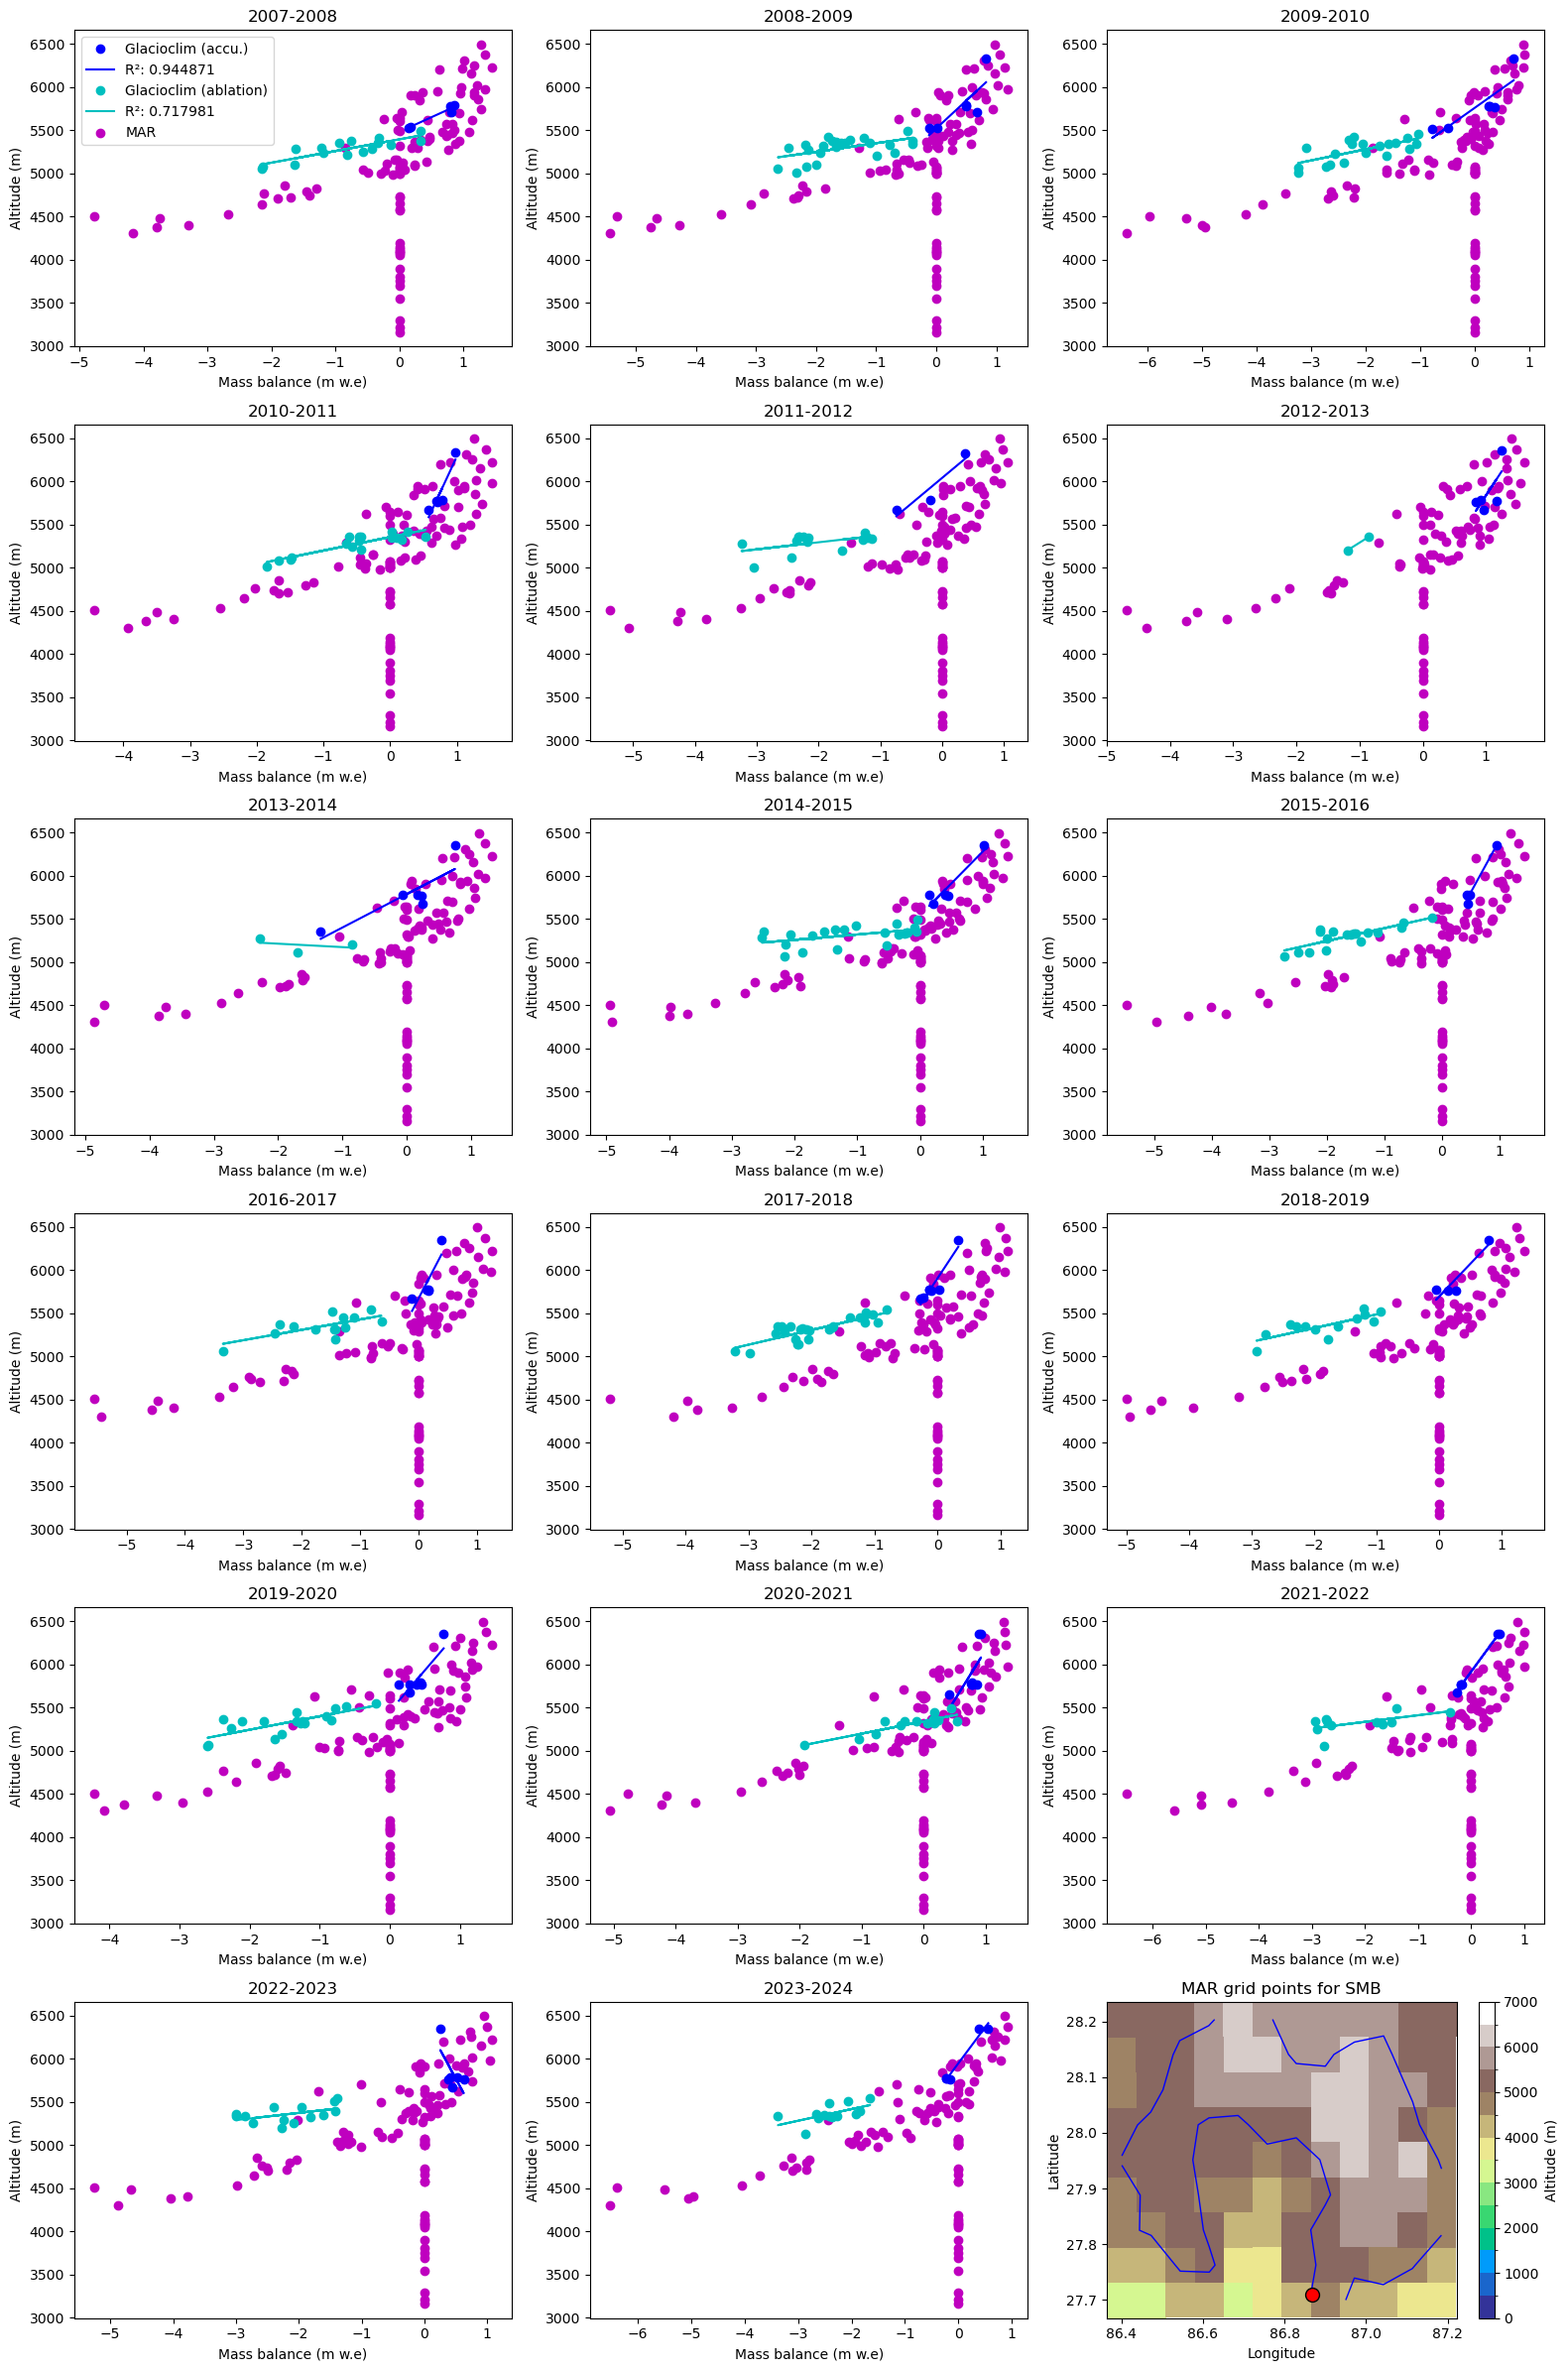

In [30]:
### Khumbu domain
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))



for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
    date_obs = date_obs.strftime("%Y-%m-%dT%H:%M:%S") # Formate l'écriture de la date au format MAR

    date_ref = df["Date_start"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    date_ref = date_ref.strftime("%Y-%m-%dT%H:%M:%S")
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day_khumbu = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY, iY+9), X=slice(iX-7, iX+5)) # Valeur du SMB à la date exact de l'obs (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)).values.flatten() # Altitude des grilles de MAR

    ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="m", label="MAR") # Affiche les points de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

####### Grid on last subplot ######
ax = axes[n]
ds_SH_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne le SMB sur les grilles données
ds_lat_khumbu = ds_lat.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")
plt.tight_layout()

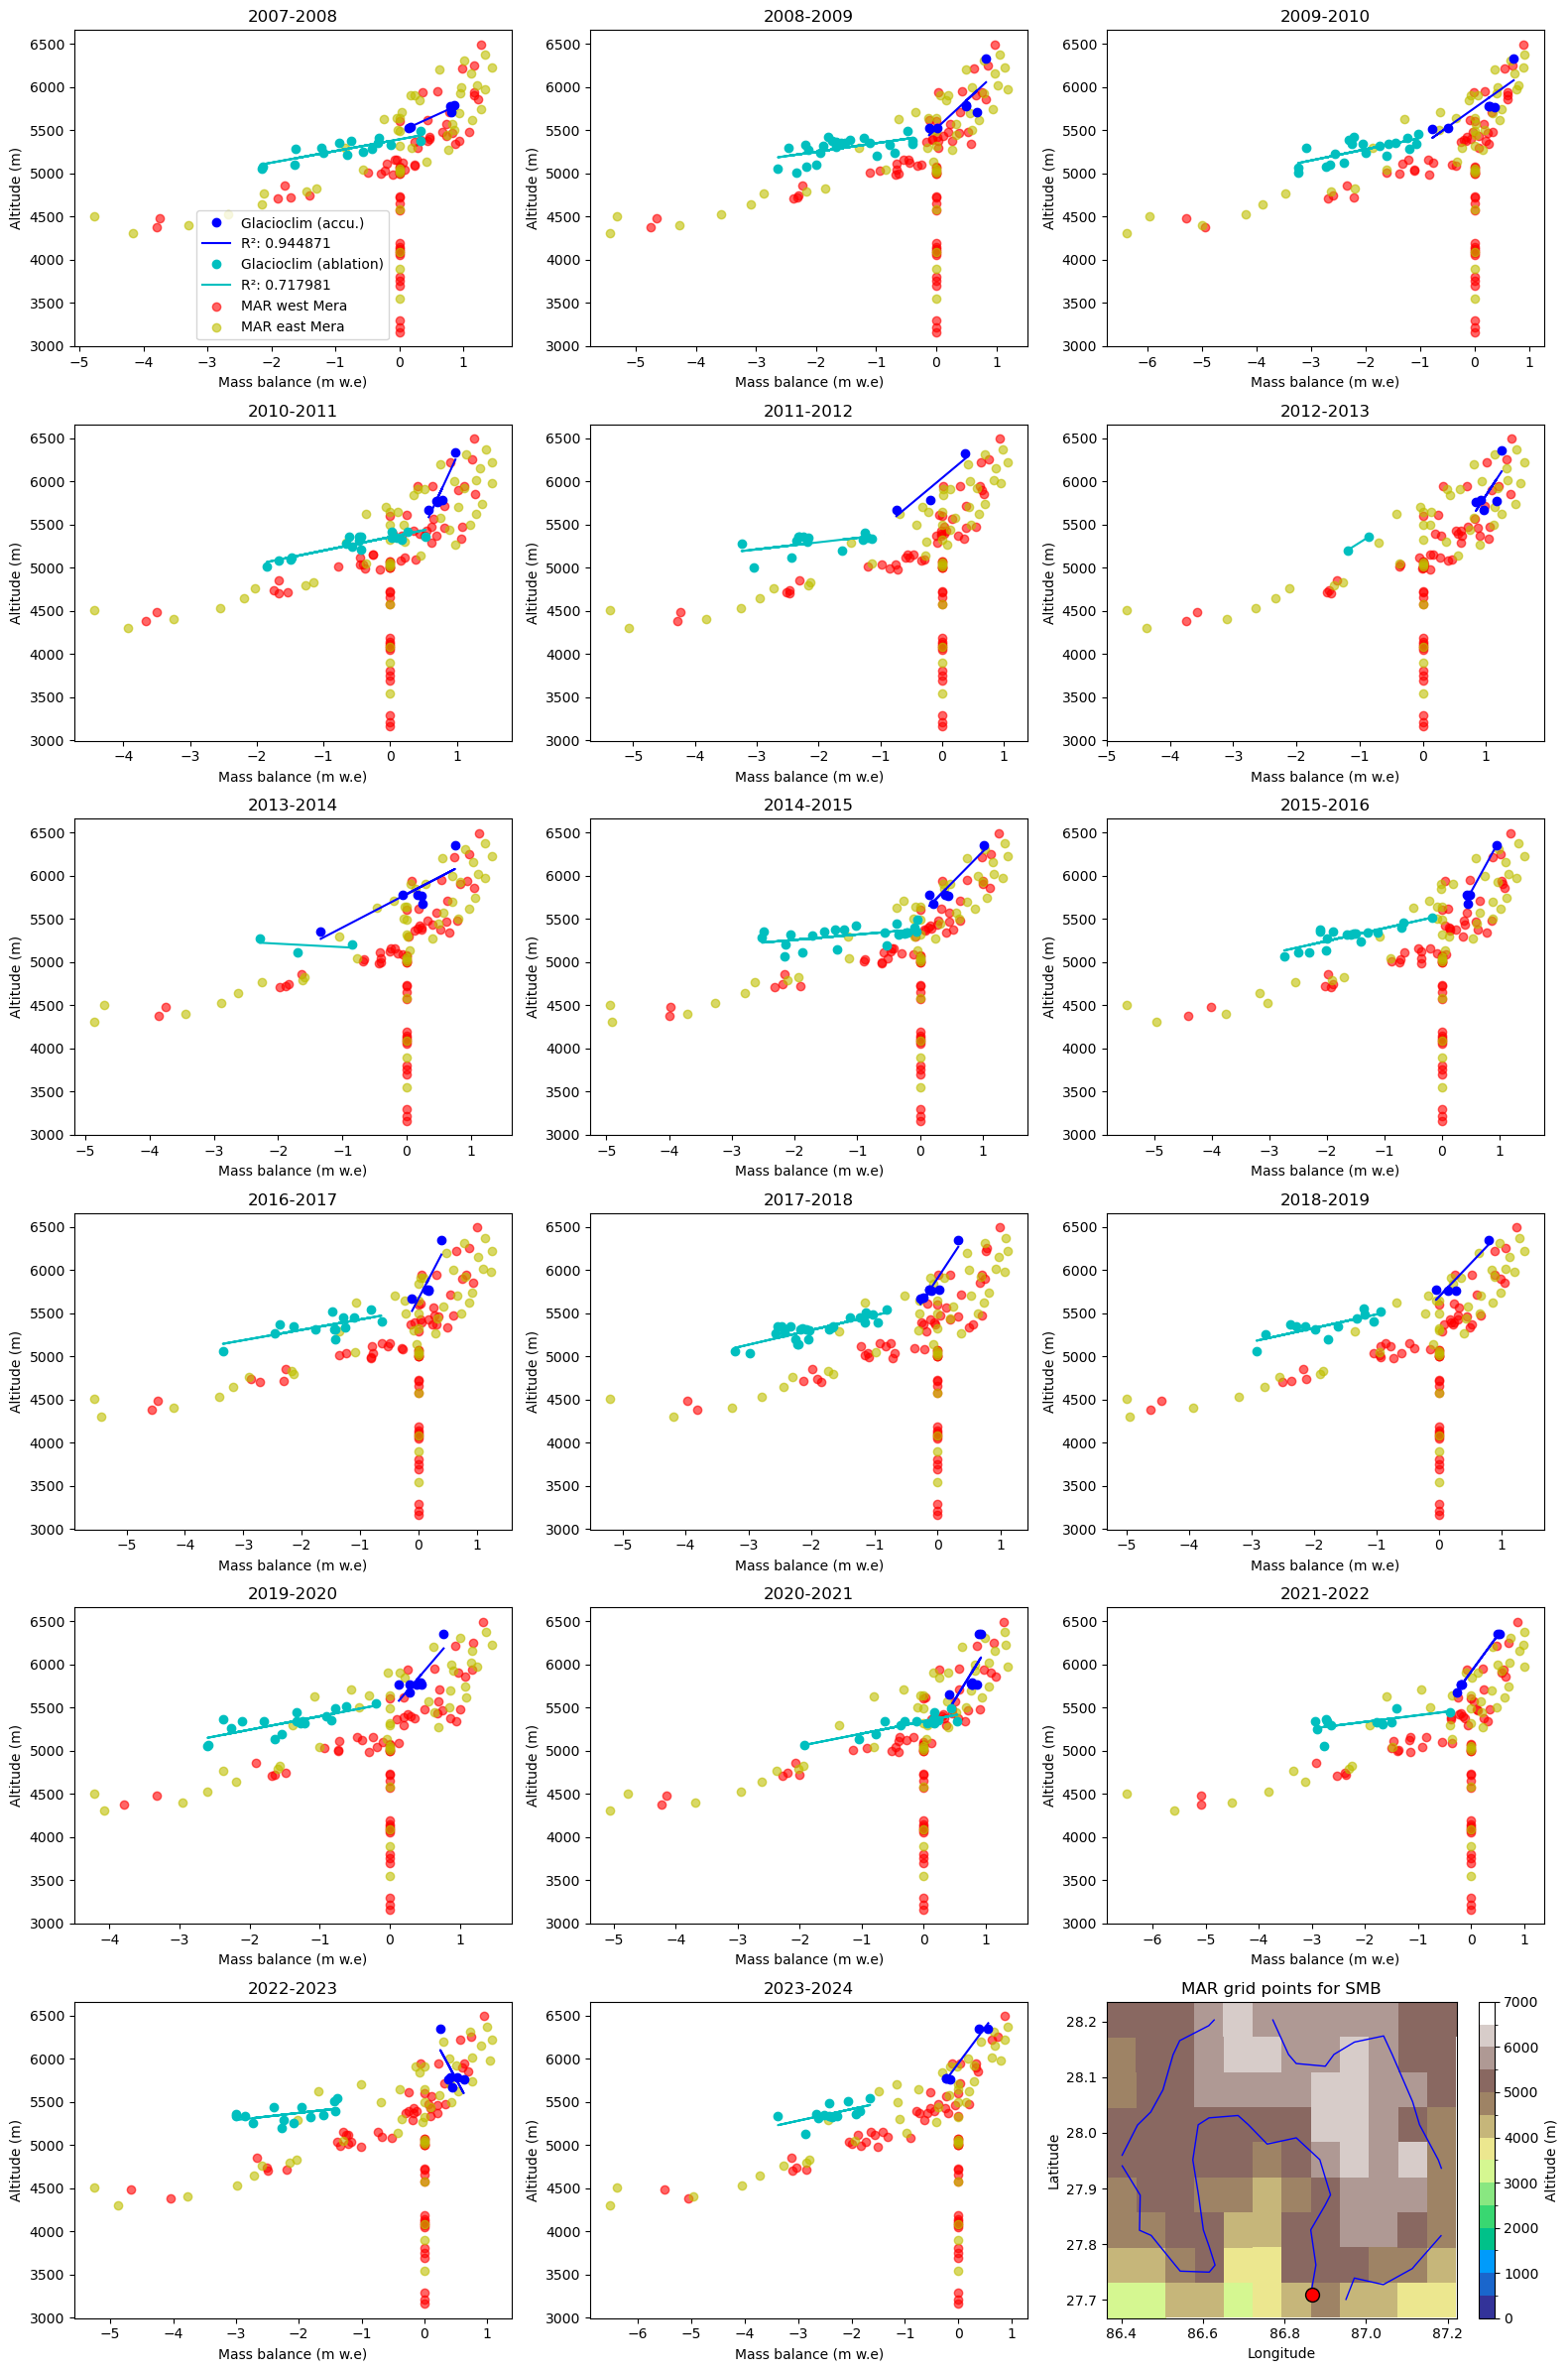

In [31]:
### Khumbu domain
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[n]
ds_SH_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne le SMB sur les grilles données
ds_lat_khumbu = ds_lat.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")


for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
    date_obs = date_obs.strftime("%Y-%m-%dT%H:%M:%S") # Formate l'écriture de la date au format MAR

    date_ref = df["Date_start"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    date_ref = date_ref.strftime("%Y-%m-%dT%H:%M:%S")
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day_khumbu = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY, iY+9), X=slice(iX-7, iX+5)) # Valeur du SMB à la date exact de l'obs (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 

    SH_MAR_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)).values.flatten() # Altitude des grilles de MAR

    lon_sep = ds_lon_khumbu.values.flatten() 

    
    # Séparation en deux catégories les sorties de MAR en fonction de leur position par rapport au point de grille du Mera 
    west = lon_sep < merap_lon
    east = lon_sep >= merap_lon

    # plot de la partie ouest et est des sorties MAR
    ax.scatter(SMB_MAR_khumbu[west], SH_MAR_khumbu[west], color="r", label="MAR west Mera", alpha=0.6)
    ax.scatter(SMB_MAR_khumbu[east], SH_MAR_khumbu[east], color="y", label="MAR east Mera", alpha=0.6)

#    ax.scatter(SMB_MAR_khumbu, SH_MAR_khumbu, color="m", label="MAR") # Affiche les points de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

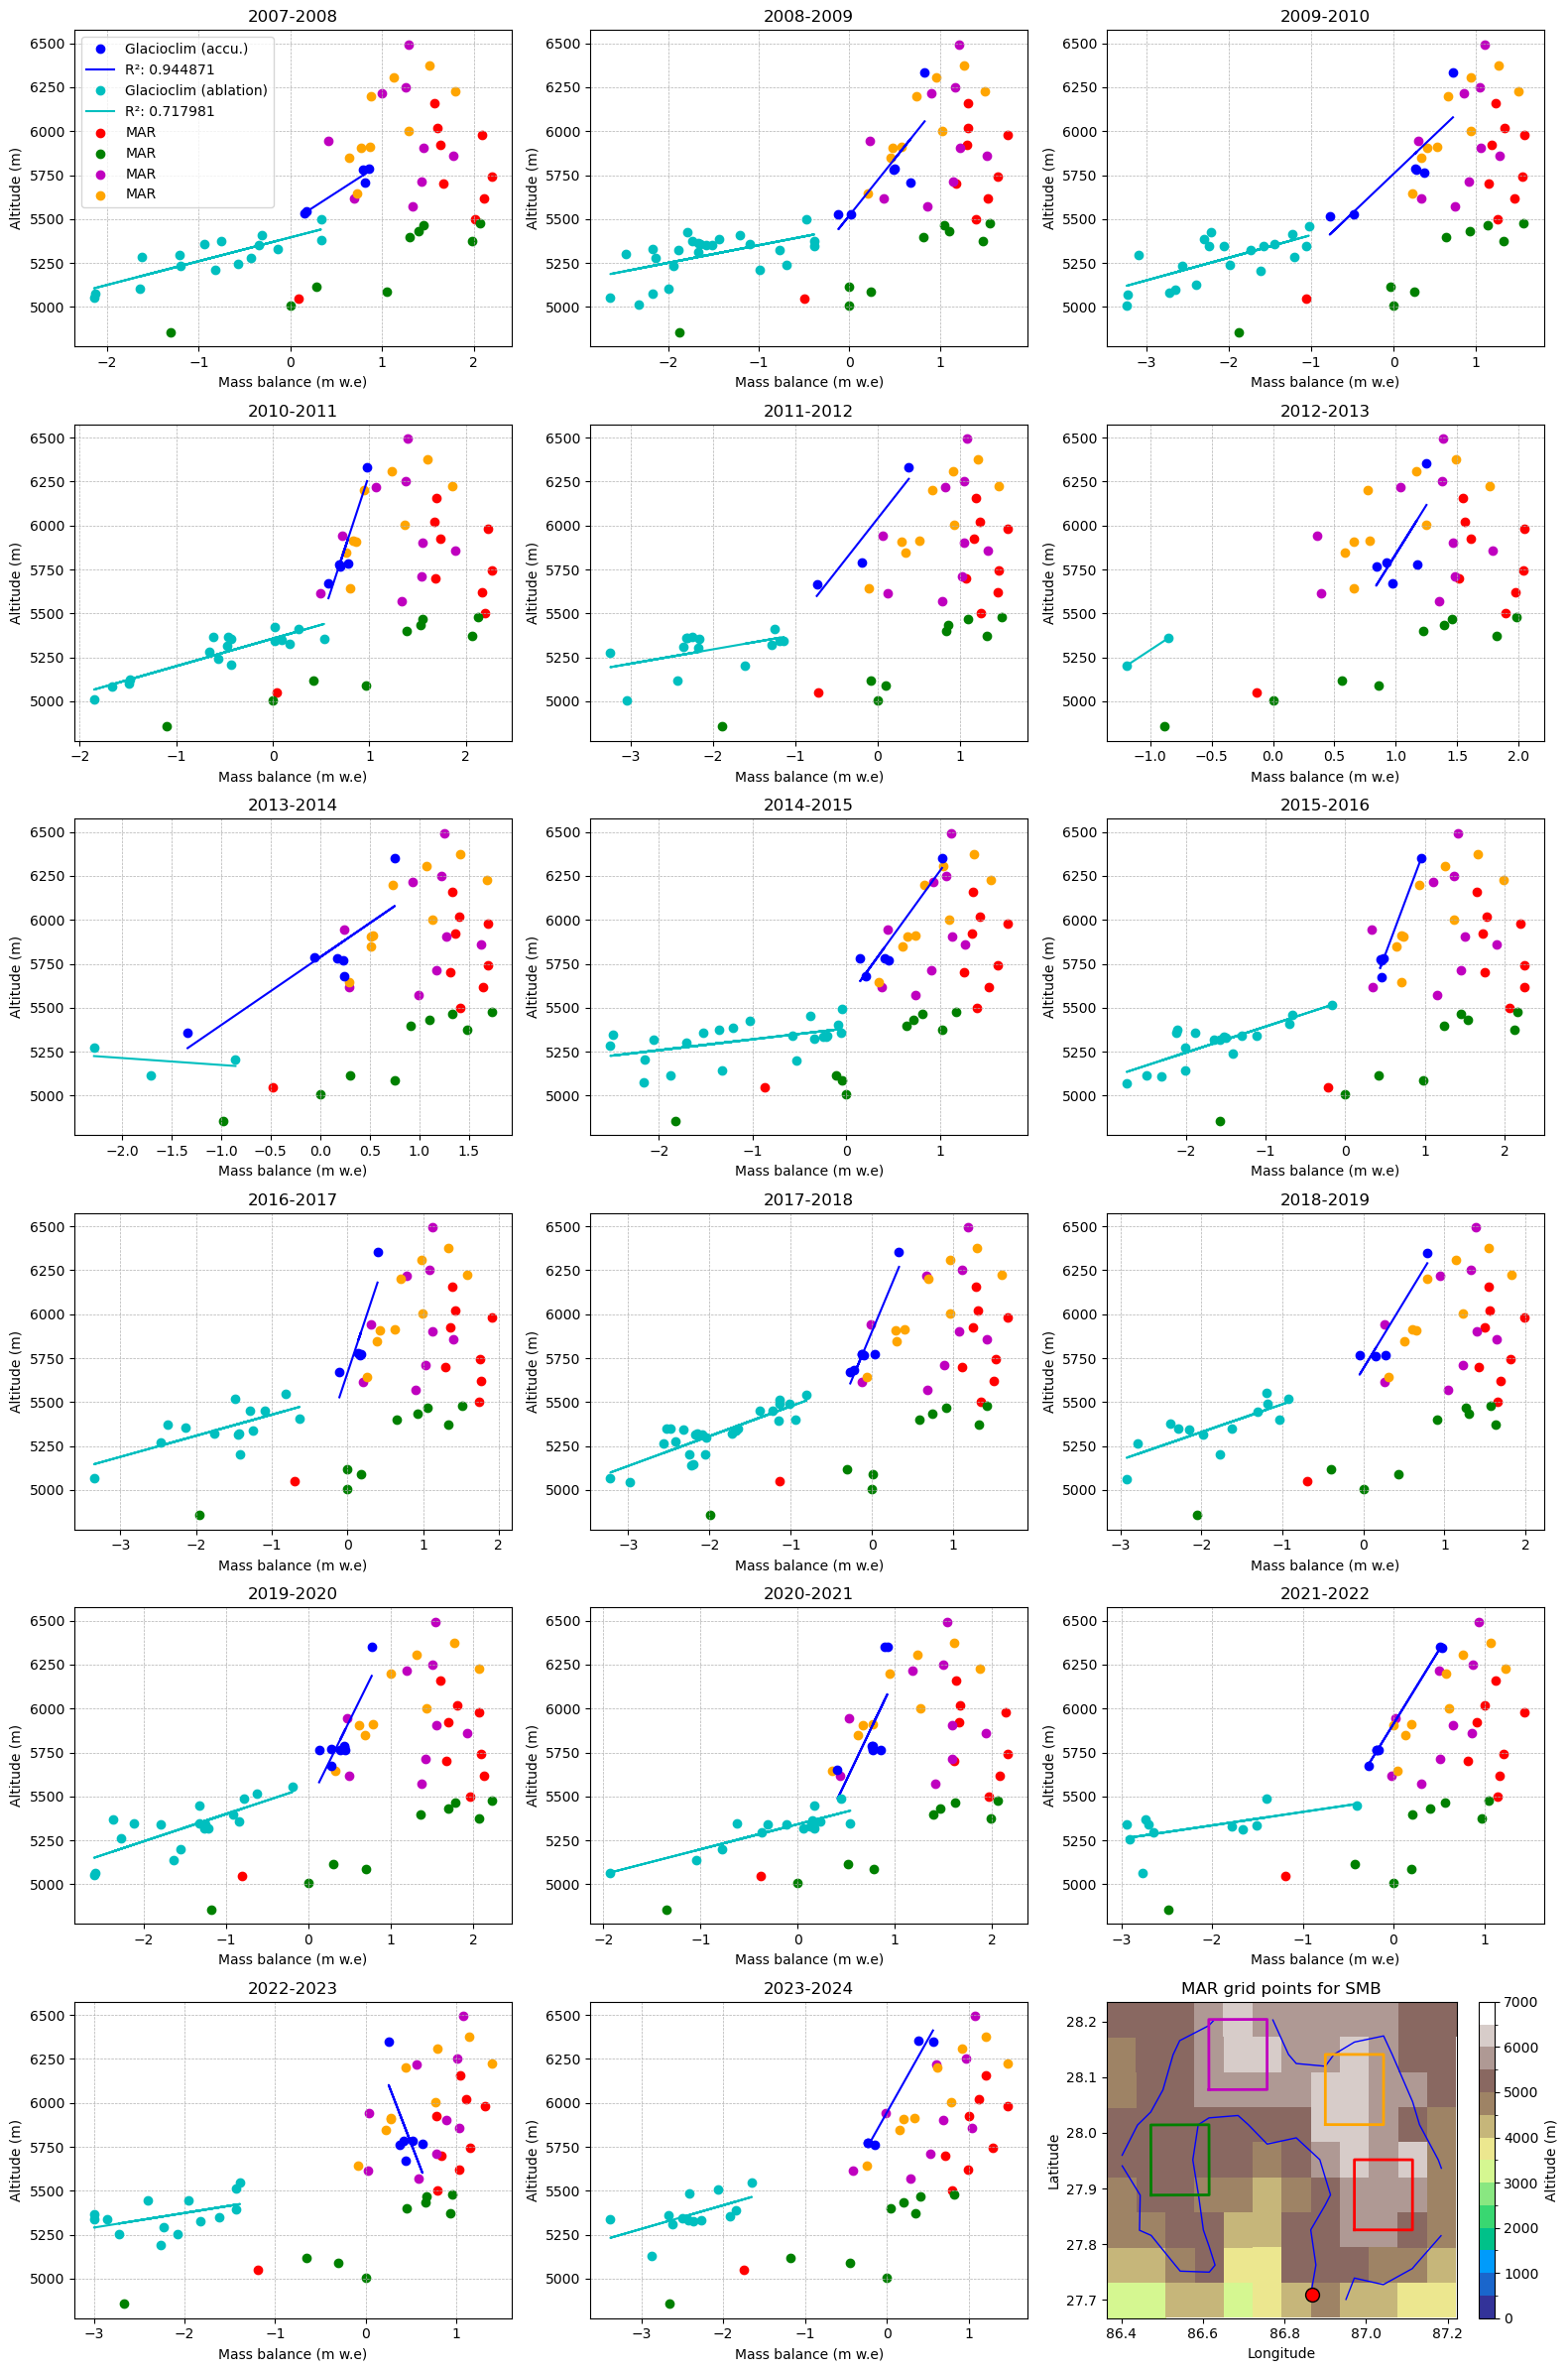

In [32]:
### Khumbu domain
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))


####### Grid on last subplot ######
ax = axes[n]
ds_SH_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne le SMB sur les grilles données
ds_lat_khumbu = ds_lat.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5))

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(2,5), slice(8,11), "r"), (slice(3,6), slice(1,4),"g"), (slice(6,9), slice(3,6), "m"), (slice(5,8), slice(7,10), "orange")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
    date_obs = date_obs.strftime("%Y-%m-%dT%H:%M:%S") # Formate l'écriture de la date au format MAR

    date_ref = df["Date_start"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    date_ref = date_ref.strftime("%Y-%m-%dT%H:%M:%S")
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day_khumbu = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY, iY+9), X=slice(iX-7, iX+5)) # Valeur du SMB à la date exact de l'obs (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        ax.scatter(SMB_subdom, SH_subdom, color=color, label='MAR')
###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

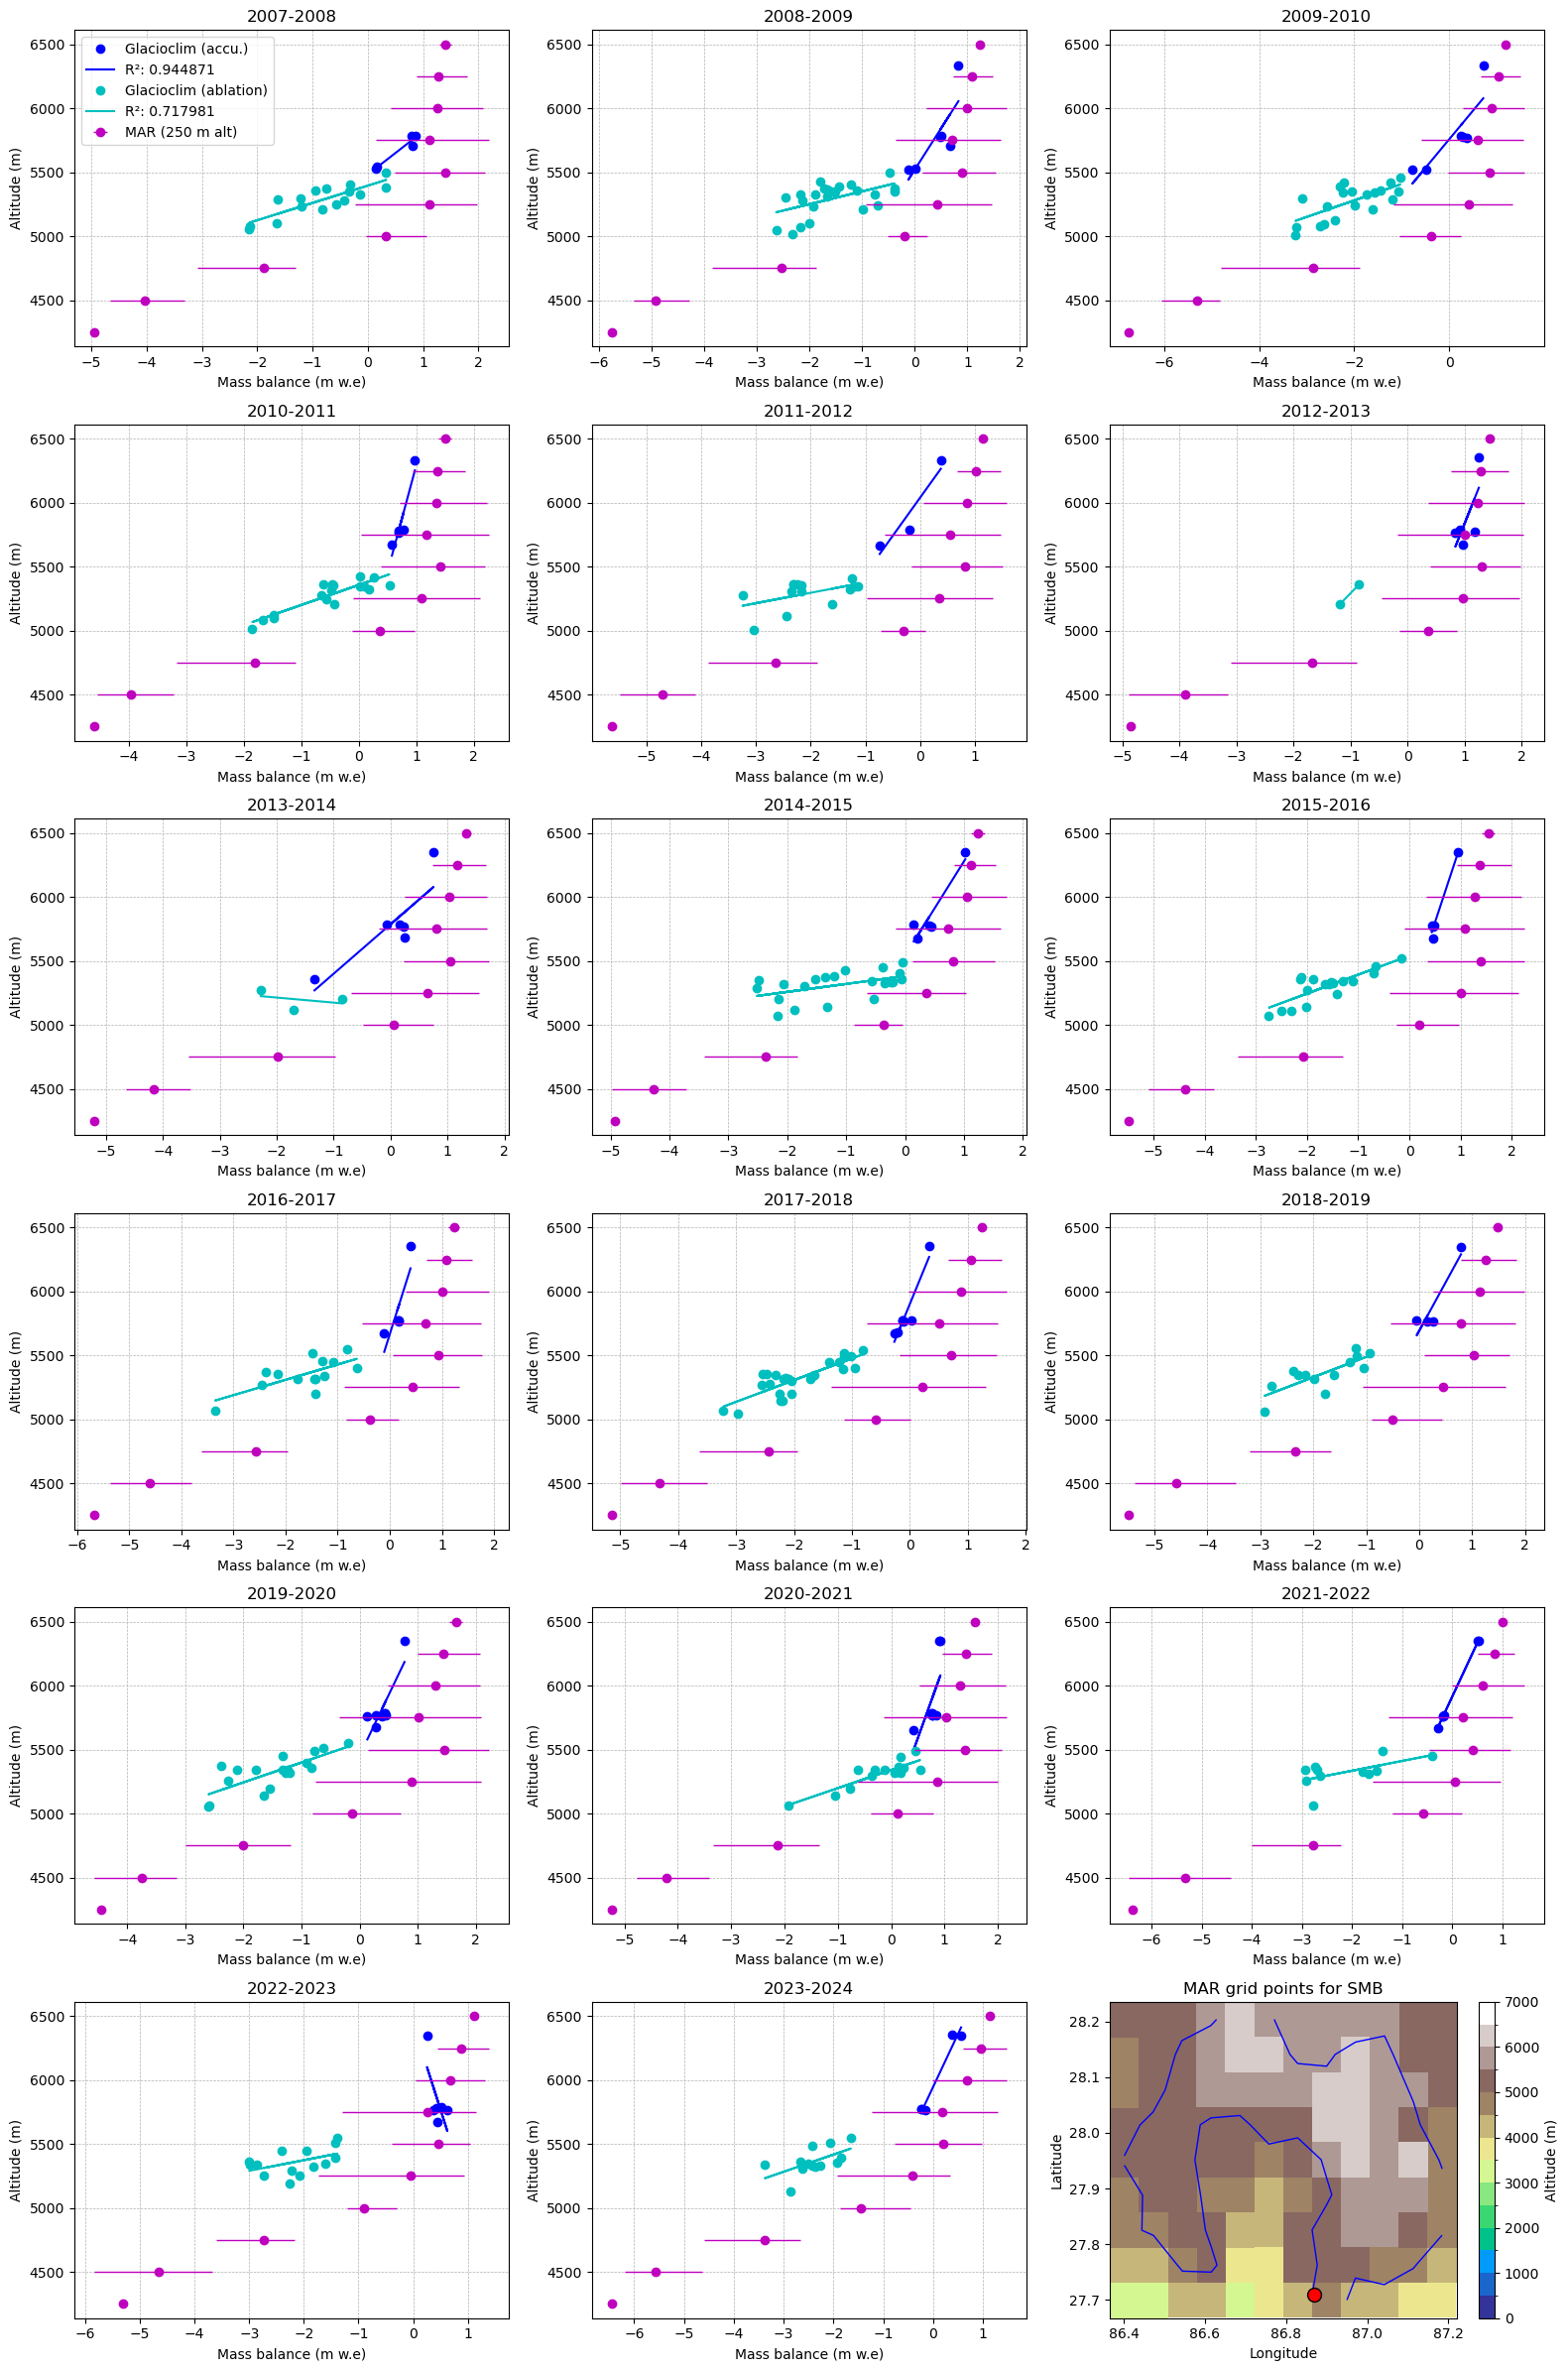

In [33]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))



for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
    date_obs = date_obs.strftime("%Y-%m-%dT%H:%M:%S") # Formate l'écriture de la date au format MAR

    date_ref = df["Date_start"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    date_ref = date_ref.strftime("%Y-%m-%dT%H:%M:%S")
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day_khumbu = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY, iY+9), X=slice(iX-7, iX+5)) # Valeur du SMB à la date exact de l'obs (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 
#    print('SMB_MAR_khumbu'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR_khumbu, 'm w.e/yr')
    
    SH_MAR_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)).values.flatten() # Altitude des grilles de MAR

    #### Création des classes d'altitude (pas de 250 m)
    alt_band = np.arange(125, 7000, 250)
    alt_classes = np.digitize(SH_MAR_khumbu, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

    SMB_mean, SMB_min, SMB_max, alt_center = [], [], [], [] # Définition des listes des moy, min et max de chaque classe d'alt

    for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
        # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
        m = (alt_classes == a) & (SMB_MAR_khumbu != 0) 

        smbk = SMB_MAR_khumbu[m]
        shk = SH_MAR_khumbu[m]

        if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
            continue
            
        # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
        SMB_mean.append(np.mean(smbk)) # Opérations ajoutés dans la liste qu'on transforme en tableau
        SMB_min.append(np.min(smbk))
        SMB_max.append(np.max(smbk))
        #alt_center.append(np.mean(shk))
        alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)


    SMB_mean = np.array(SMB_mean) # Transformation des listes en tableaux pour pouvoir les plot
    SMB_min = np.array(SMB_min)
    SMB_max = np.array(SMB_max)
    alt_center = np.array(alt_center)

    # Plot de la barre d'erreur avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
    ax.errorbar(SMB_mean, alt_center, xerr=[SMB_mean-SMB_min, SMB_max-SMB_mean], fmt="o", color="m", ecolor="m", elinewidth=1, label="MAR (250 m alt)")
        
###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

####### Grid on last subplot ######
ax = axes[n]
ds_SH_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne le SMB sur les grilles données
ds_lat_khumbu = ds_lat.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")
plt.tight_layout()

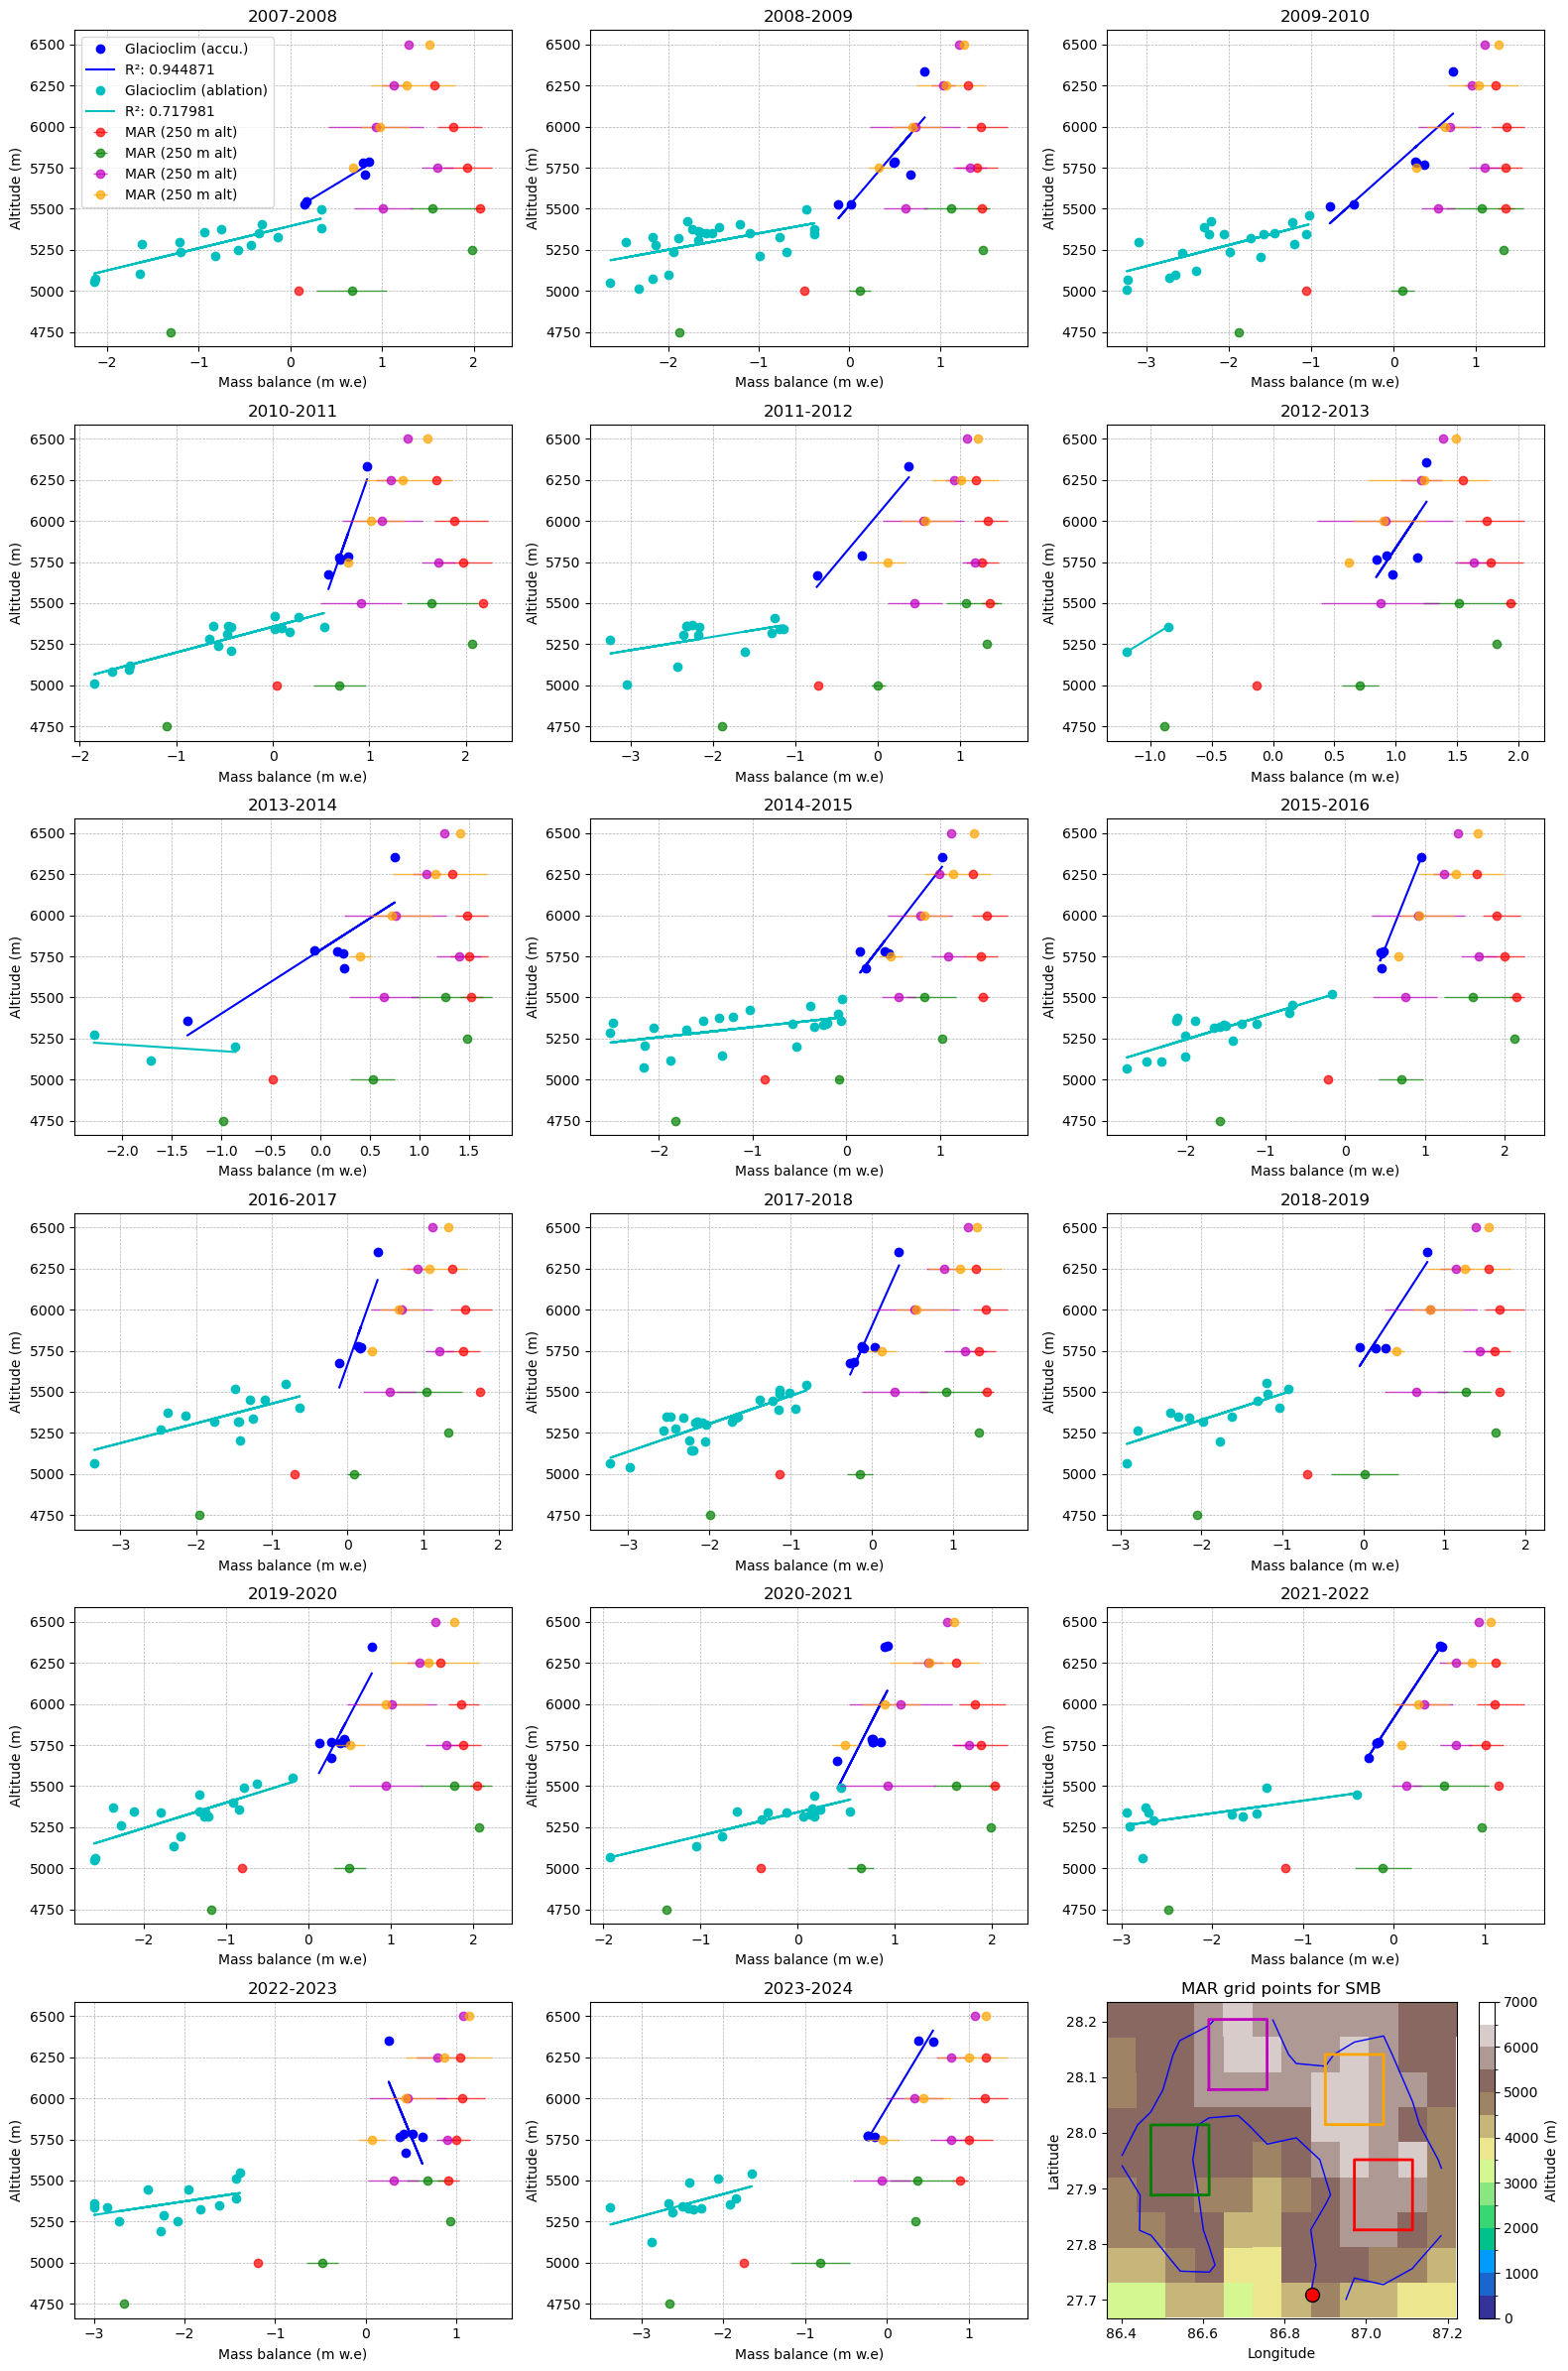

In [34]:
### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

####### Grid on last subplot ######
ax = axes[n]
ds_SH_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne le SMB sur les grilles données
ds_lat_khumbu = ds_lat.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)) # Selectionne les lon lat pour les plot
ds_lon_khumbu = ds_lon.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5))

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

plt.contour(ds_lon_khumbu, ds_lat_khumbu, ds_ICE_khumbu, levels=[ice_level], colors="b", linewidths=1) # Contours glaciers
ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_khumbu, ds_lat_khumbu, ds_SH_khumbu, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")

# Ici on définit des slices sans passer par iY et iX car on a déjà découpé le domaine sur le khumbu
# On cherche des zones dans le khumbu à partir du bas gauche du domaine (sous la forme slice(y,y),slice(x,x) --> Point en bas à gauche est (0,0)
# orange=everest / rouge=procheMera / magenta= NordOuest
subdom = [(slice(2,5), slice(8,11), "r"), (slice(3,6), slice(1,4),"g"), (slice(6,9), slice(3,6), "m"), (slice(5,8), slice(7,10), "orange")]

for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté
    lat_sub = ds_lat_khumbu.isel(y=ys, x=xs).values
    lon_sub = ds_lon_khumbu.isel(y=ys, x=xs).values

    rect_lat = [lat_sub[0,0], lat_sub[0,-1], lat_sub[-1,-1], lat_sub[-1,0], lat_sub[0,0]] # Selection des angles des sous domaines
    rect_lon = [lon_sub[0,0], lon_sub[0,-1], lon_sub[-1,-1], lon_sub[-1,0], lon_sub[0,0]]
    
    ax.plot(rect_lon, rect_lat, color=color, linewidth=2)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")

for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
    date_obs = date_obs.strftime("%Y-%m-%dT%H:%M:%S") # Formate l'écriture de la date au format MAR

    date_ref = df["Date_start"].iloc[4].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    date_ref = date_ref.strftime("%Y-%m-%dT%H:%M:%S")
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day_khumbu = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY, iY+9), X=slice(iX-7, iX+5)) # Valeur du SMB à la date exact de l'obs (glacioclim)
    SMB_sum_khumbu = SMB_day_khumbu.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR_khumbu = SMB_sum_khumbu.values.flatten() 
#    print('SMB_MAR_khumbu'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR_khumbu, 'm w.e/yr')
    
    SH_MAR_khumbu = ds_SH.isel(y=slice(iY, iY+9), x=slice(iX-7, iX+5)).values.flatten() # Altitude des grilles de MAR

    for ys, xs, color in subdom: # On a un tuple, le nom des variable n'a pas d'importance tant que l'ordre est respecté

        SMB_subdom = SMB_sum_khumbu.isel(Y=ys, X=xs).values.flatten()
        SH_subdom  = ds_SH_khumbu.isel(y=ys, x=xs).values.flatten()

        #ax.scatter(SMB_subdom, SH_subdom, color=color, label='MAR')
    
        #### Création des classes d'altitude (pas de 250 m)
        alt_band = np.arange(125, 7000, 250)
        alt_classes = np.digitize(SH_subdom, alt_band) # Digitize permet de mettre dans les classes d'altitude les différentes grilles selon leur altitudes sous forme de liste [1,2,2,1,3,2]

        SMB_mean, SMB_min, SMB_max, alt_center = [], [], [], [] # Définition des listes des moy, min et max de chaque classe d'alt

        for a in np.unique(alt_classes): # Comme alt_classes est une liste donnant un indice à chaque point de grille en fonction de l'altitude. np.unique ne regarde qu'une fois un indice déjà vu
            # Création d'un mask "m" qui va prendre la forme m = [False, True, True, False...] avec une condition sur si la classe et sur si la valeur de SMB n'est pas nulle
            m = (alt_classes == a) & (SMB_subdom != 0) 

            smbk = SMB_subdom[m]
            shk = SH_subdom[m]

            if len(smbk) == 0:   # Si la liste smbk pour une classe d'alt est vide (cad que tous les smb pour cette alt sont nuls), on passe à l'itération suivante pour éviter un bug dans la boucle
                continue

            offset = {"r": -0.15, "m": 0, "orange": 0.15}
            # Grâce au mask, on peut alors faire des opérations sur les variables restreintes aux bandes d'altitudes
            SMB_mean.append(np.mean(smbk)) # Opérations ajoutés dans la liste qu'on transforme en tableau
            SMB_min.append(np.min(smbk))
            SMB_max.append(np.max(smbk))
            #alt_center.append(np.mean(shk)) # Fais la moyenne des altitudes de chaque bande
            alt_center.append(alt_band[a-1] + 125) # Affiche simplement le centre de la bande sans moyenner ("a-1" car digitize a un indice qui commence par 1)

        SMB_mean = np.array(SMB_mean) # Transformation des listes en tableaux pour pouvoir les plot
        SMB_min = np.array(SMB_min)
        SMB_max = np.array(SMB_max)
        alt_center = np.array(alt_center)

        # Plot de la barre d'erreur avec xerr qui affiche une barre de couleur "ecolor", et de taille "capsize"
        ax.errorbar(SMB_mean, alt_center, xerr=[SMB_mean-SMB_min, SMB_max-SMB_mean], fmt="o", color=color, ecolor=color, elinewidth=1, alpha=0.7, label="MAR (250 m alt)")
        
###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.grid(linestyle = '--', linewidth = 0.5)
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

# Prise en compte des écarts réels entre deux dates

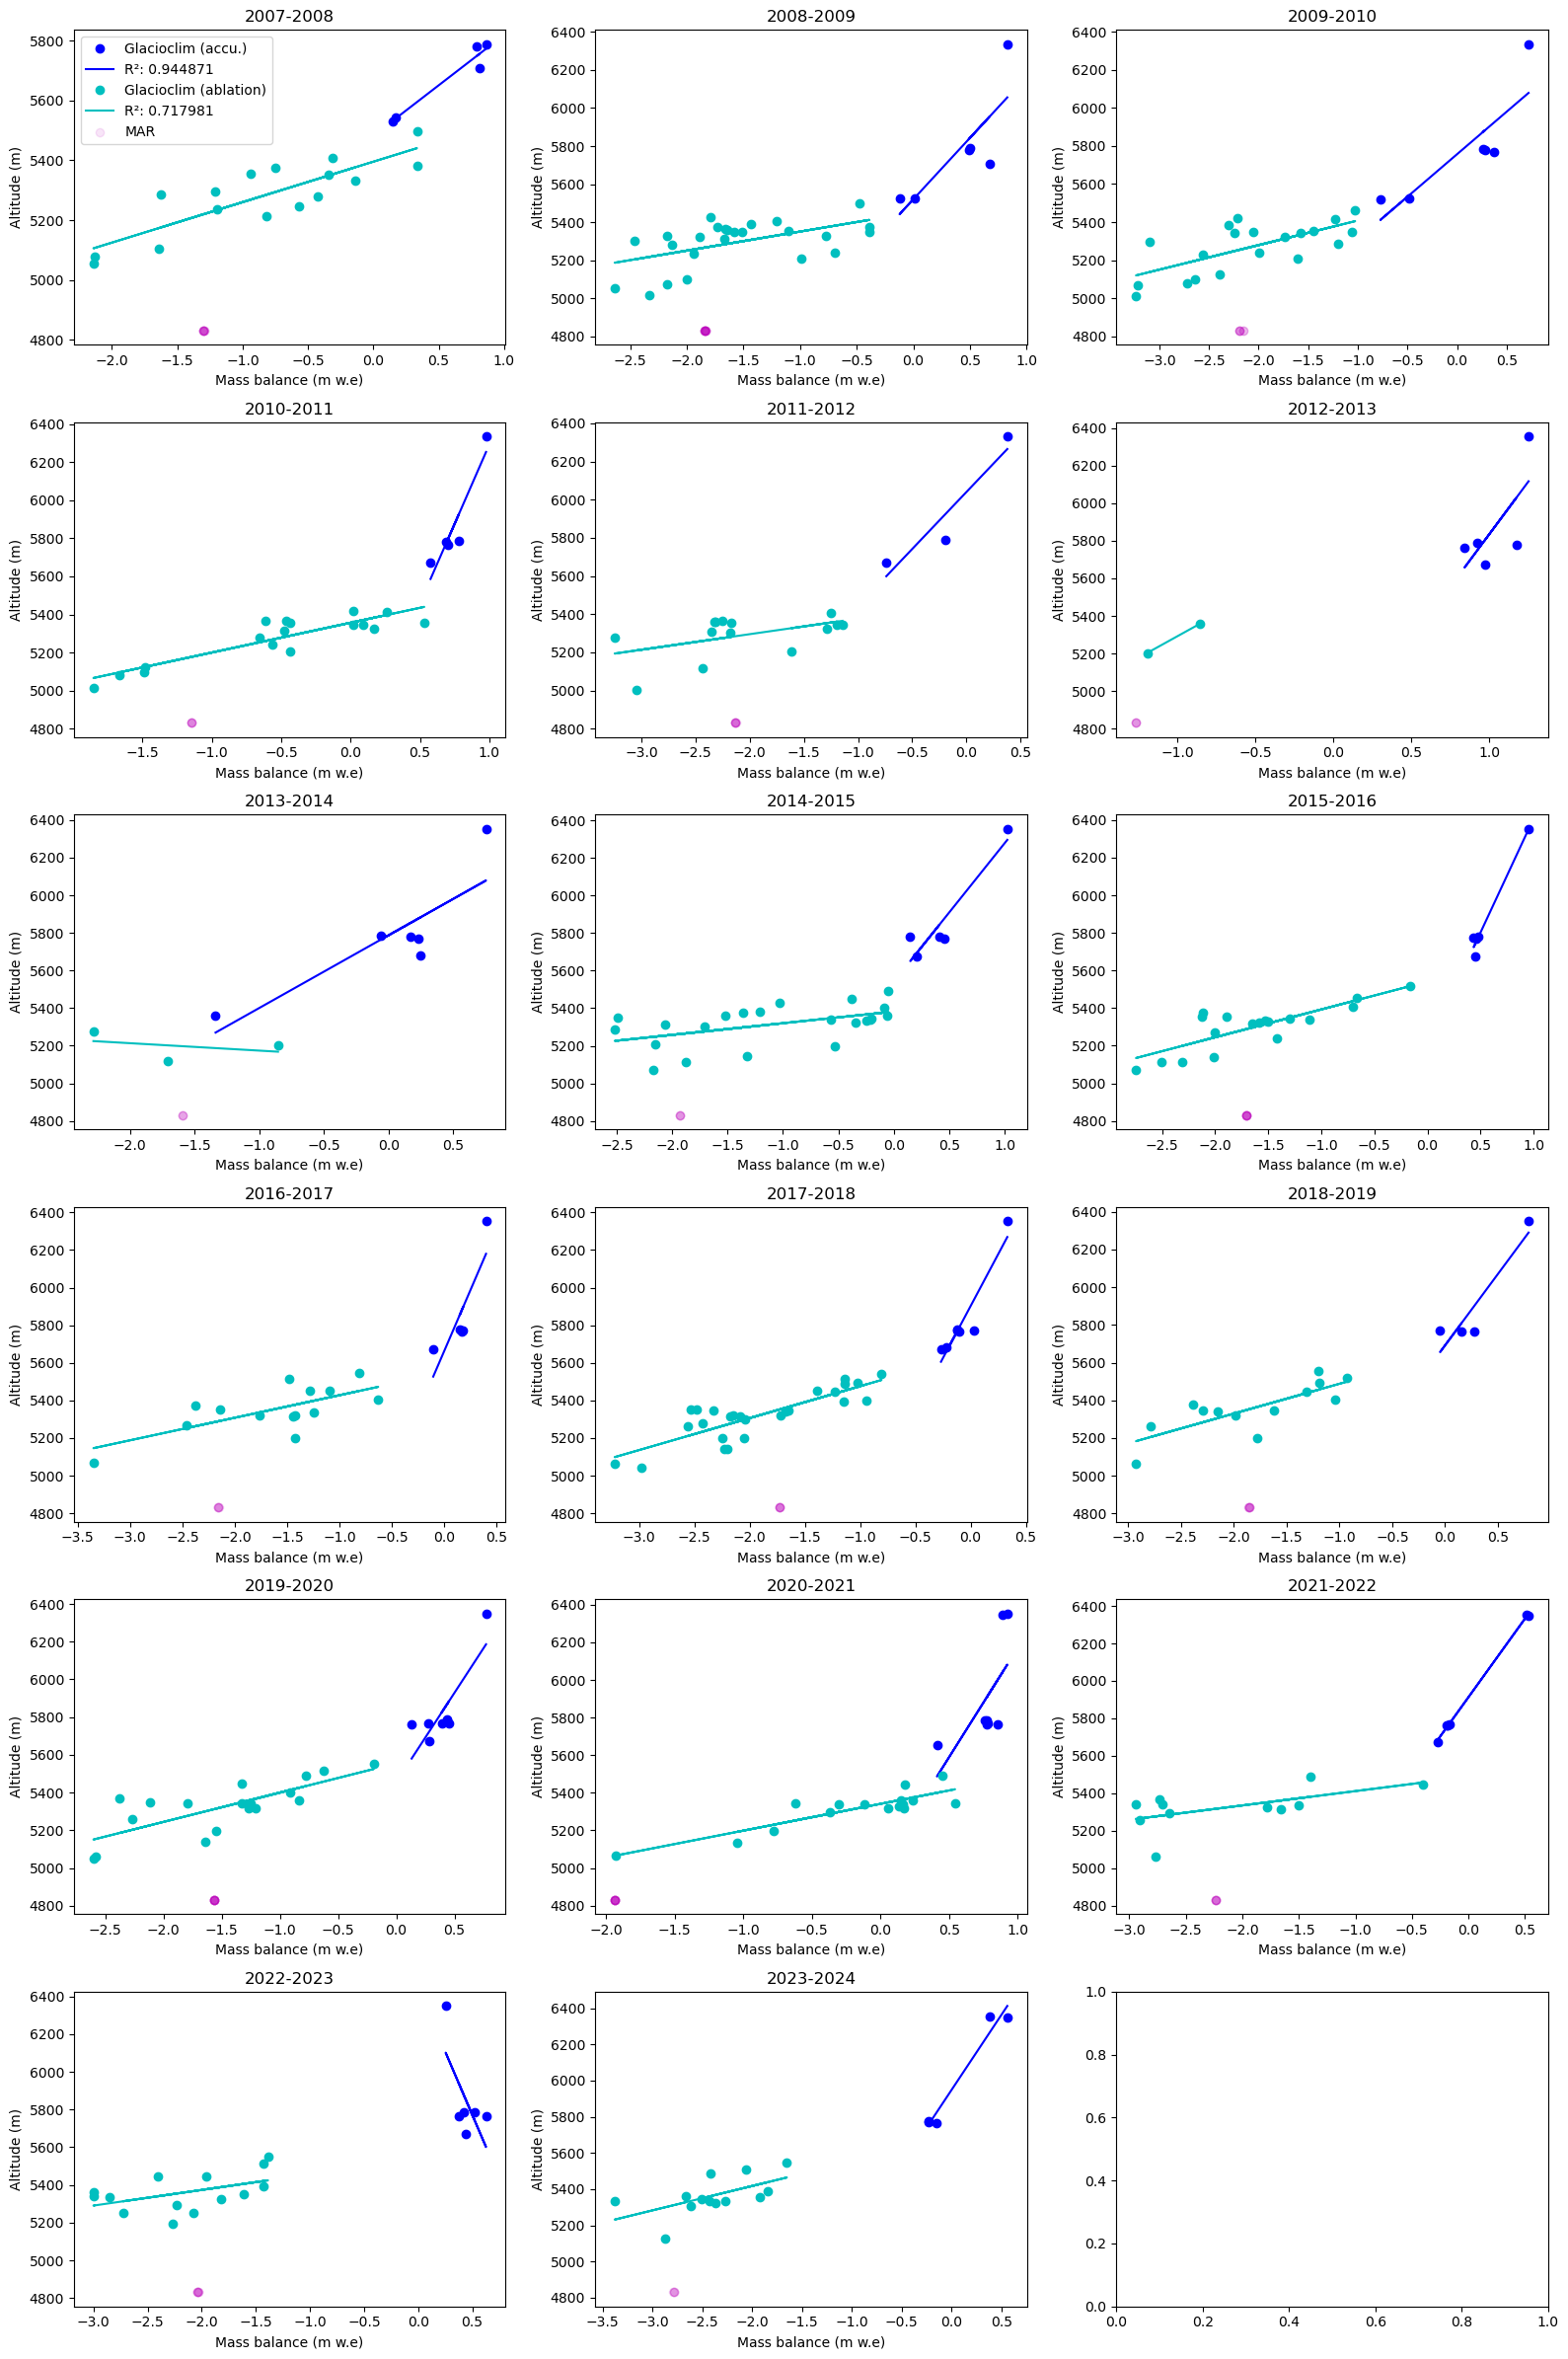

In [35]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))



for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne

    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        # La régression linéaire contient naturellement des informations comme slope = pente de regression / intercept = ordonnée à l'origine / rvalue = coeff de corrélation / pvalue
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    # Parcours l'intervale/subset des deux dates et supprime les doublons trouvés entre deux intervalles strictement identiques. Remets les indices en ordre après avoir supprimé les doublons
    df_clear = df.drop_duplicates(subset = ["Date_start", "Date_end"])
    df_clear = df_clear.dropna(subset = ["Date_start", "Date_end"]).reset_index(drop=True) # Supprime les valeurs NaT (une date a été trouvée sur les deux)
    nperiod = len(df_clear)

    MAR_label = True # Affichage d'un seul label de MAR
    
    for i in range(nperiod): # Boucle qui parcours les différents intervalles de date pour une même année
        date_obs = df_clear.loc[i, "Date_end"].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
        # Ici .loc va chercher dans df_clear les valeurs par indices (i) d'où l'intérêt de reset l'indice. Contrairement à iloc qui va chercher la position peu importe l'indice

        date_ref = df_clear.loc[i, "Date_start"].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    
        SMB_day = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=iY, X=iX) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
        SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
        SMB_MAR = SMB_sum.values 
        #print('SMB_MAR'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR, 'm w.e/yr')
#    print('Date_MAR:', ds_SMBy.sel(TIME=date_obs).TIME.values) # Affiche la date dans le fichier

        SH_MAR = ds_SH.isel(y=iY, x=iX) # Altitude de la grille de MAR au Peak Mera (coord iY,iX)
#    print('Grid alt =', SH_MAR.values, 'm')

        if MAR_label: # Affiche la légende du point MAR une fois, quand la condition est respectée
            ax.scatter(SMB_MAR, SH_MAR, color="m", alpha=0.1, label="MAR") # Affiche le point de MAR correspondant à la date des obs
            MAR_label = False
        else:
            ax.scatter(SMB_MAR, SH_MAR, color="m", alpha=0.1)

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2)
#    ax.set_ylim(4700, 6400)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

plt.tight_layout()

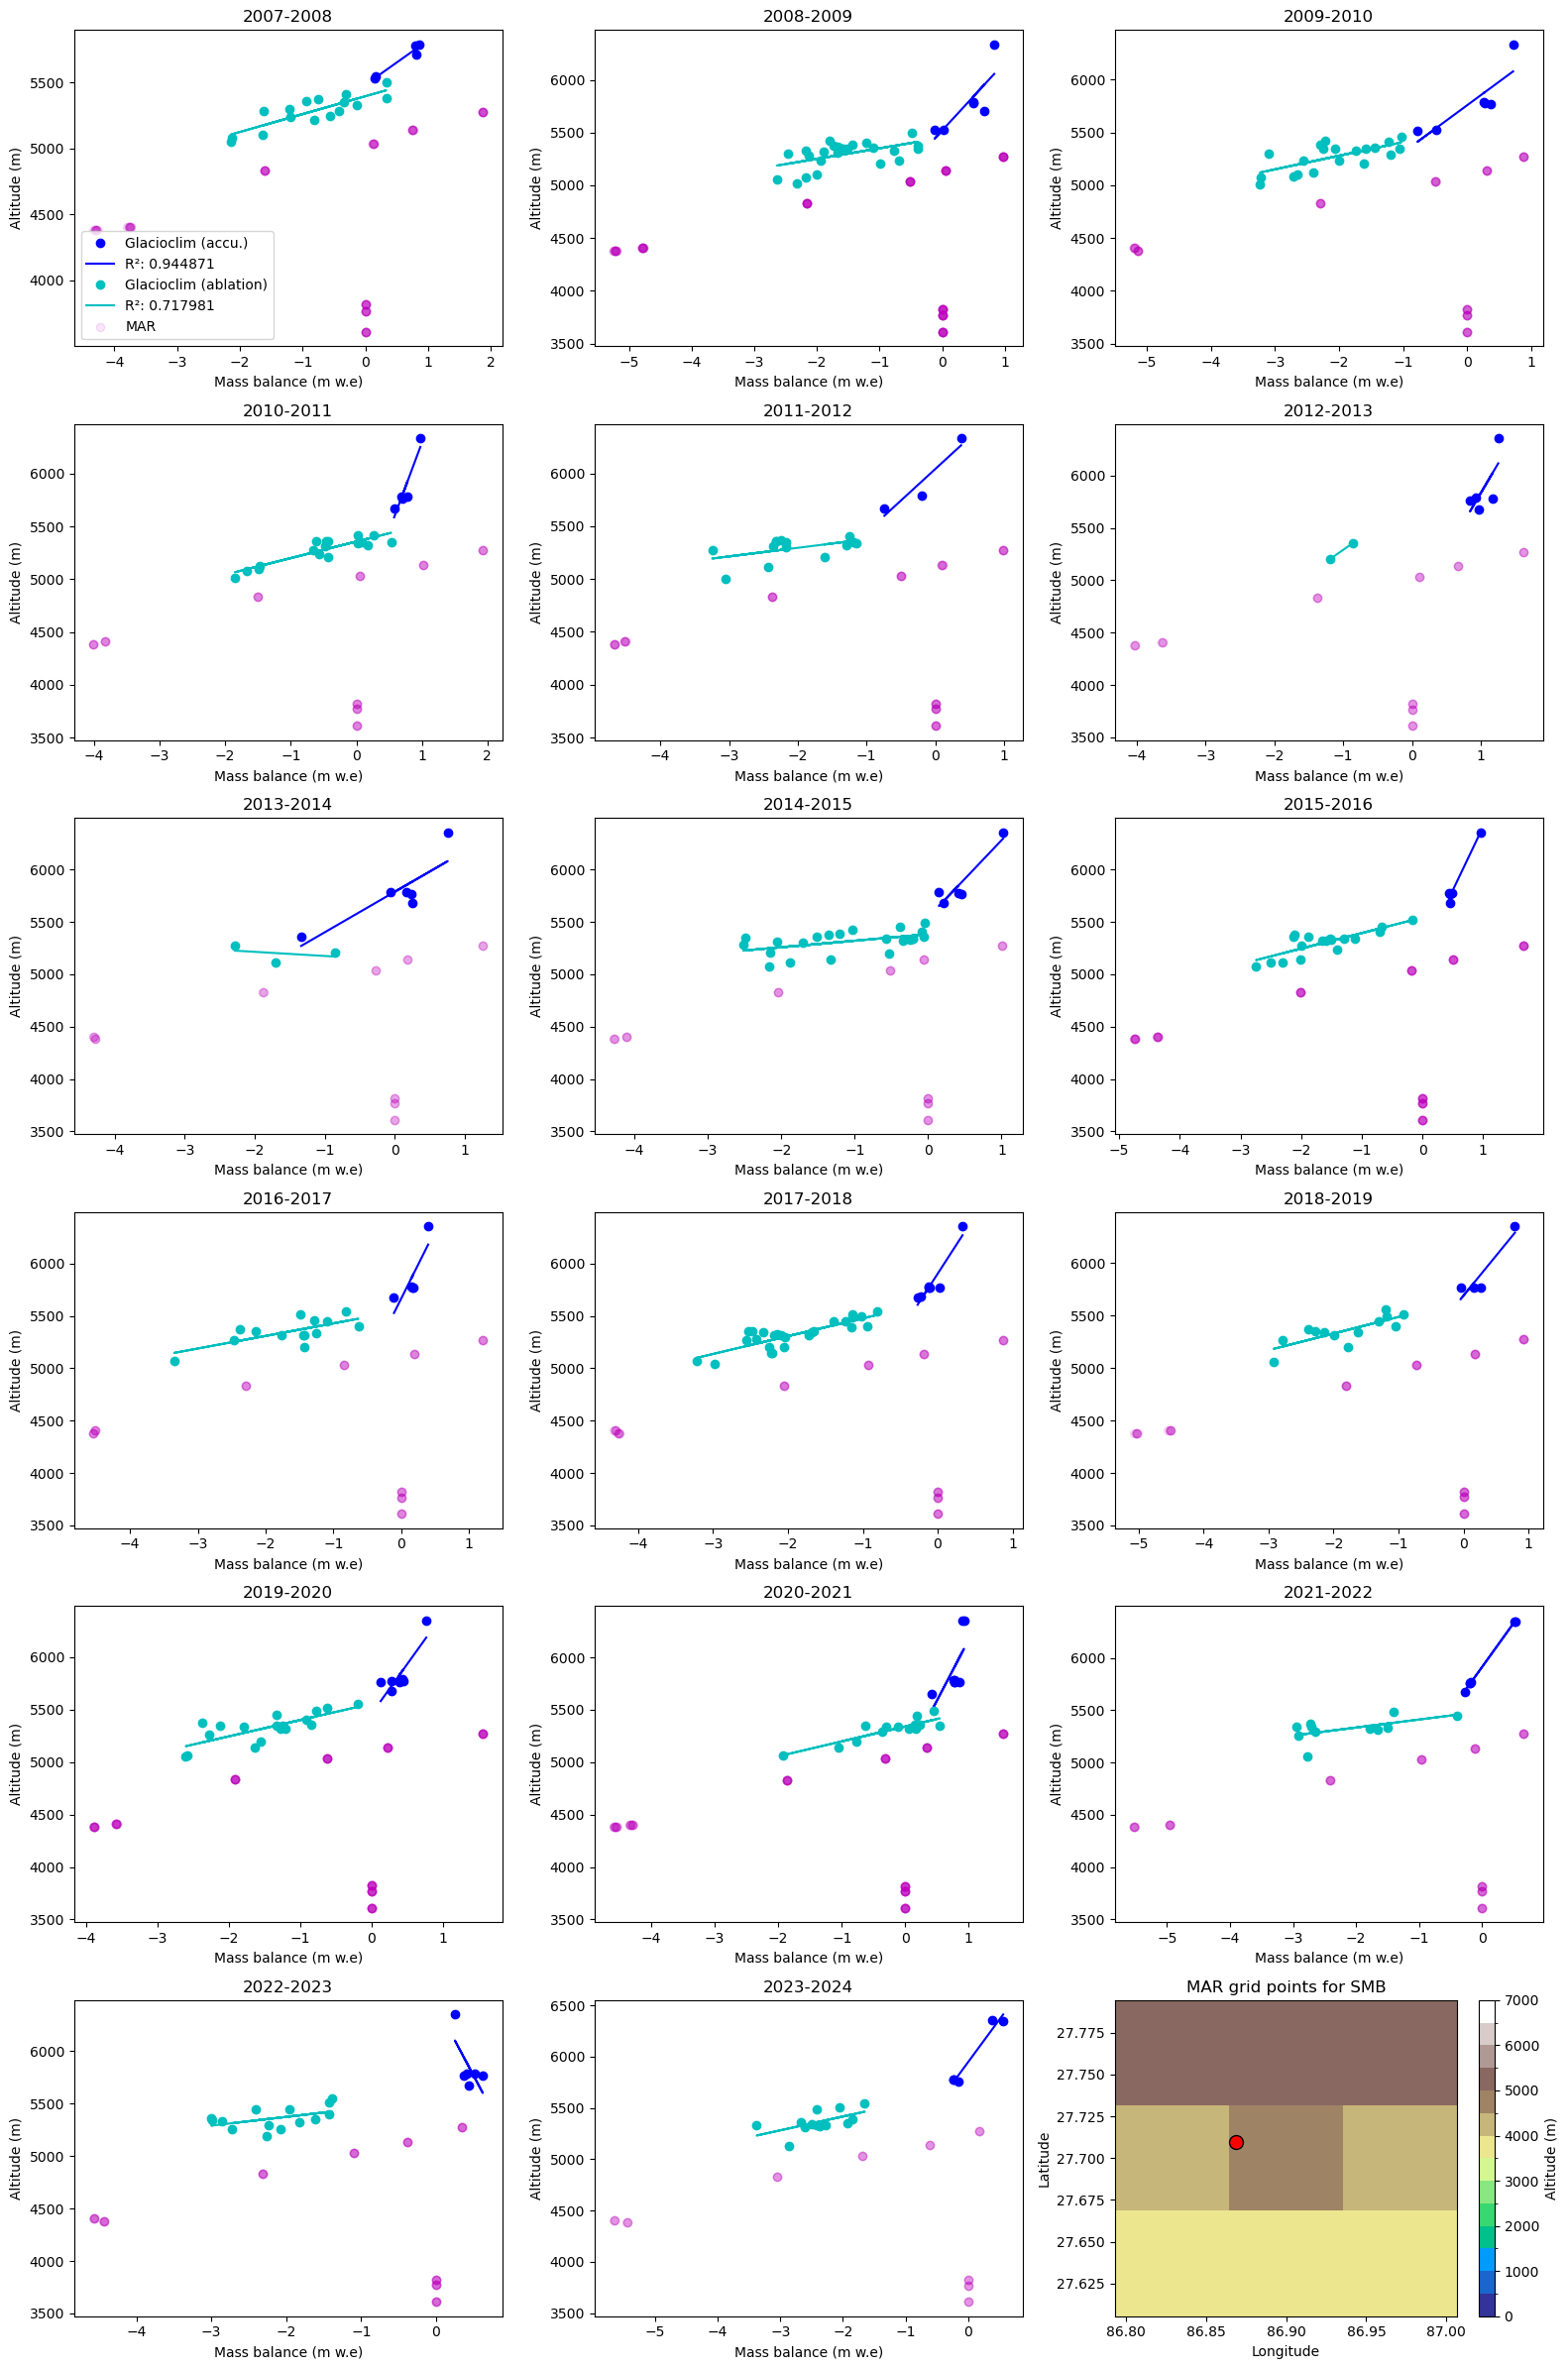

In [36]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))



for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]

    # Parcours l'intervale/subset des deux dates et supprime les doublons trouvés entre deux intervalles strictement identiques. Remets les indices en ordre après avoir supprimé les doublons
    df_clear = df.drop_duplicates(subset = ["Date_start", "Date_end"])
    df_clear = df_clear.dropna(subset = ["Date_start", "Date_end"]).reset_index(drop=True) # Supprime les valeurs NaT (une date a été trouvée sur les deux)
    nperiod = len(df_clear)

    MAR_label = True # Affichage d'un seul label de MAR

    for i in range(nperiod): # Boucle qui parcours les différents intervalles de date pour une même année
        date_obs = df_clear.loc[i, "Date_end"].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
        # Ici .loc va chercher dans df_clear les valeurs par indices (i) d'où l'intérêt de reset l'indice. Contrairement à iloc qui va chercher la position peu importe l'indice

        date_ref = df_clear.loc[i, "Date_start"].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    
        SMB_day2 = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY-1, iY+2), X=slice(iX-1, iX+2)) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
        SMB_sum2 = SMB_day2.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
        SMB_MAR2 = SMB_sum2.values.flatten() 

        SH_MAR2 = ds_SH.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)).values.flatten() # Altitude des grilles de MAR

        if MAR_label: # Affiche la légende du point MAR une fois, quand la condition est respectée
            ax.scatter(SMB_MAR2, SH_MAR2, color="m", alpha=0.1, label="MAR") # Affiche le point de MAR correspondant à la date des obs
            MAR_label = False
        else:
            ax.scatter(SMB_MAR2, SH_MAR2, color="m", alpha=0.1)
    
###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

####### Grid on last subplot ######
ax = axes[n]
ds_SH2 = ds_SH.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)) # Selectionne le SMB sur les grilles données
ds_lat_mera2 = ds_lat.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2)) # Selectionne les lon lat pour les plot
ds_lon_mera2 = ds_lon.isel(y=slice(iY-1, iY+2), x=slice(iX-1, iX+2))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_mera2, ds_lat_mera2, ds_SH2, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")
plt.tight_layout()

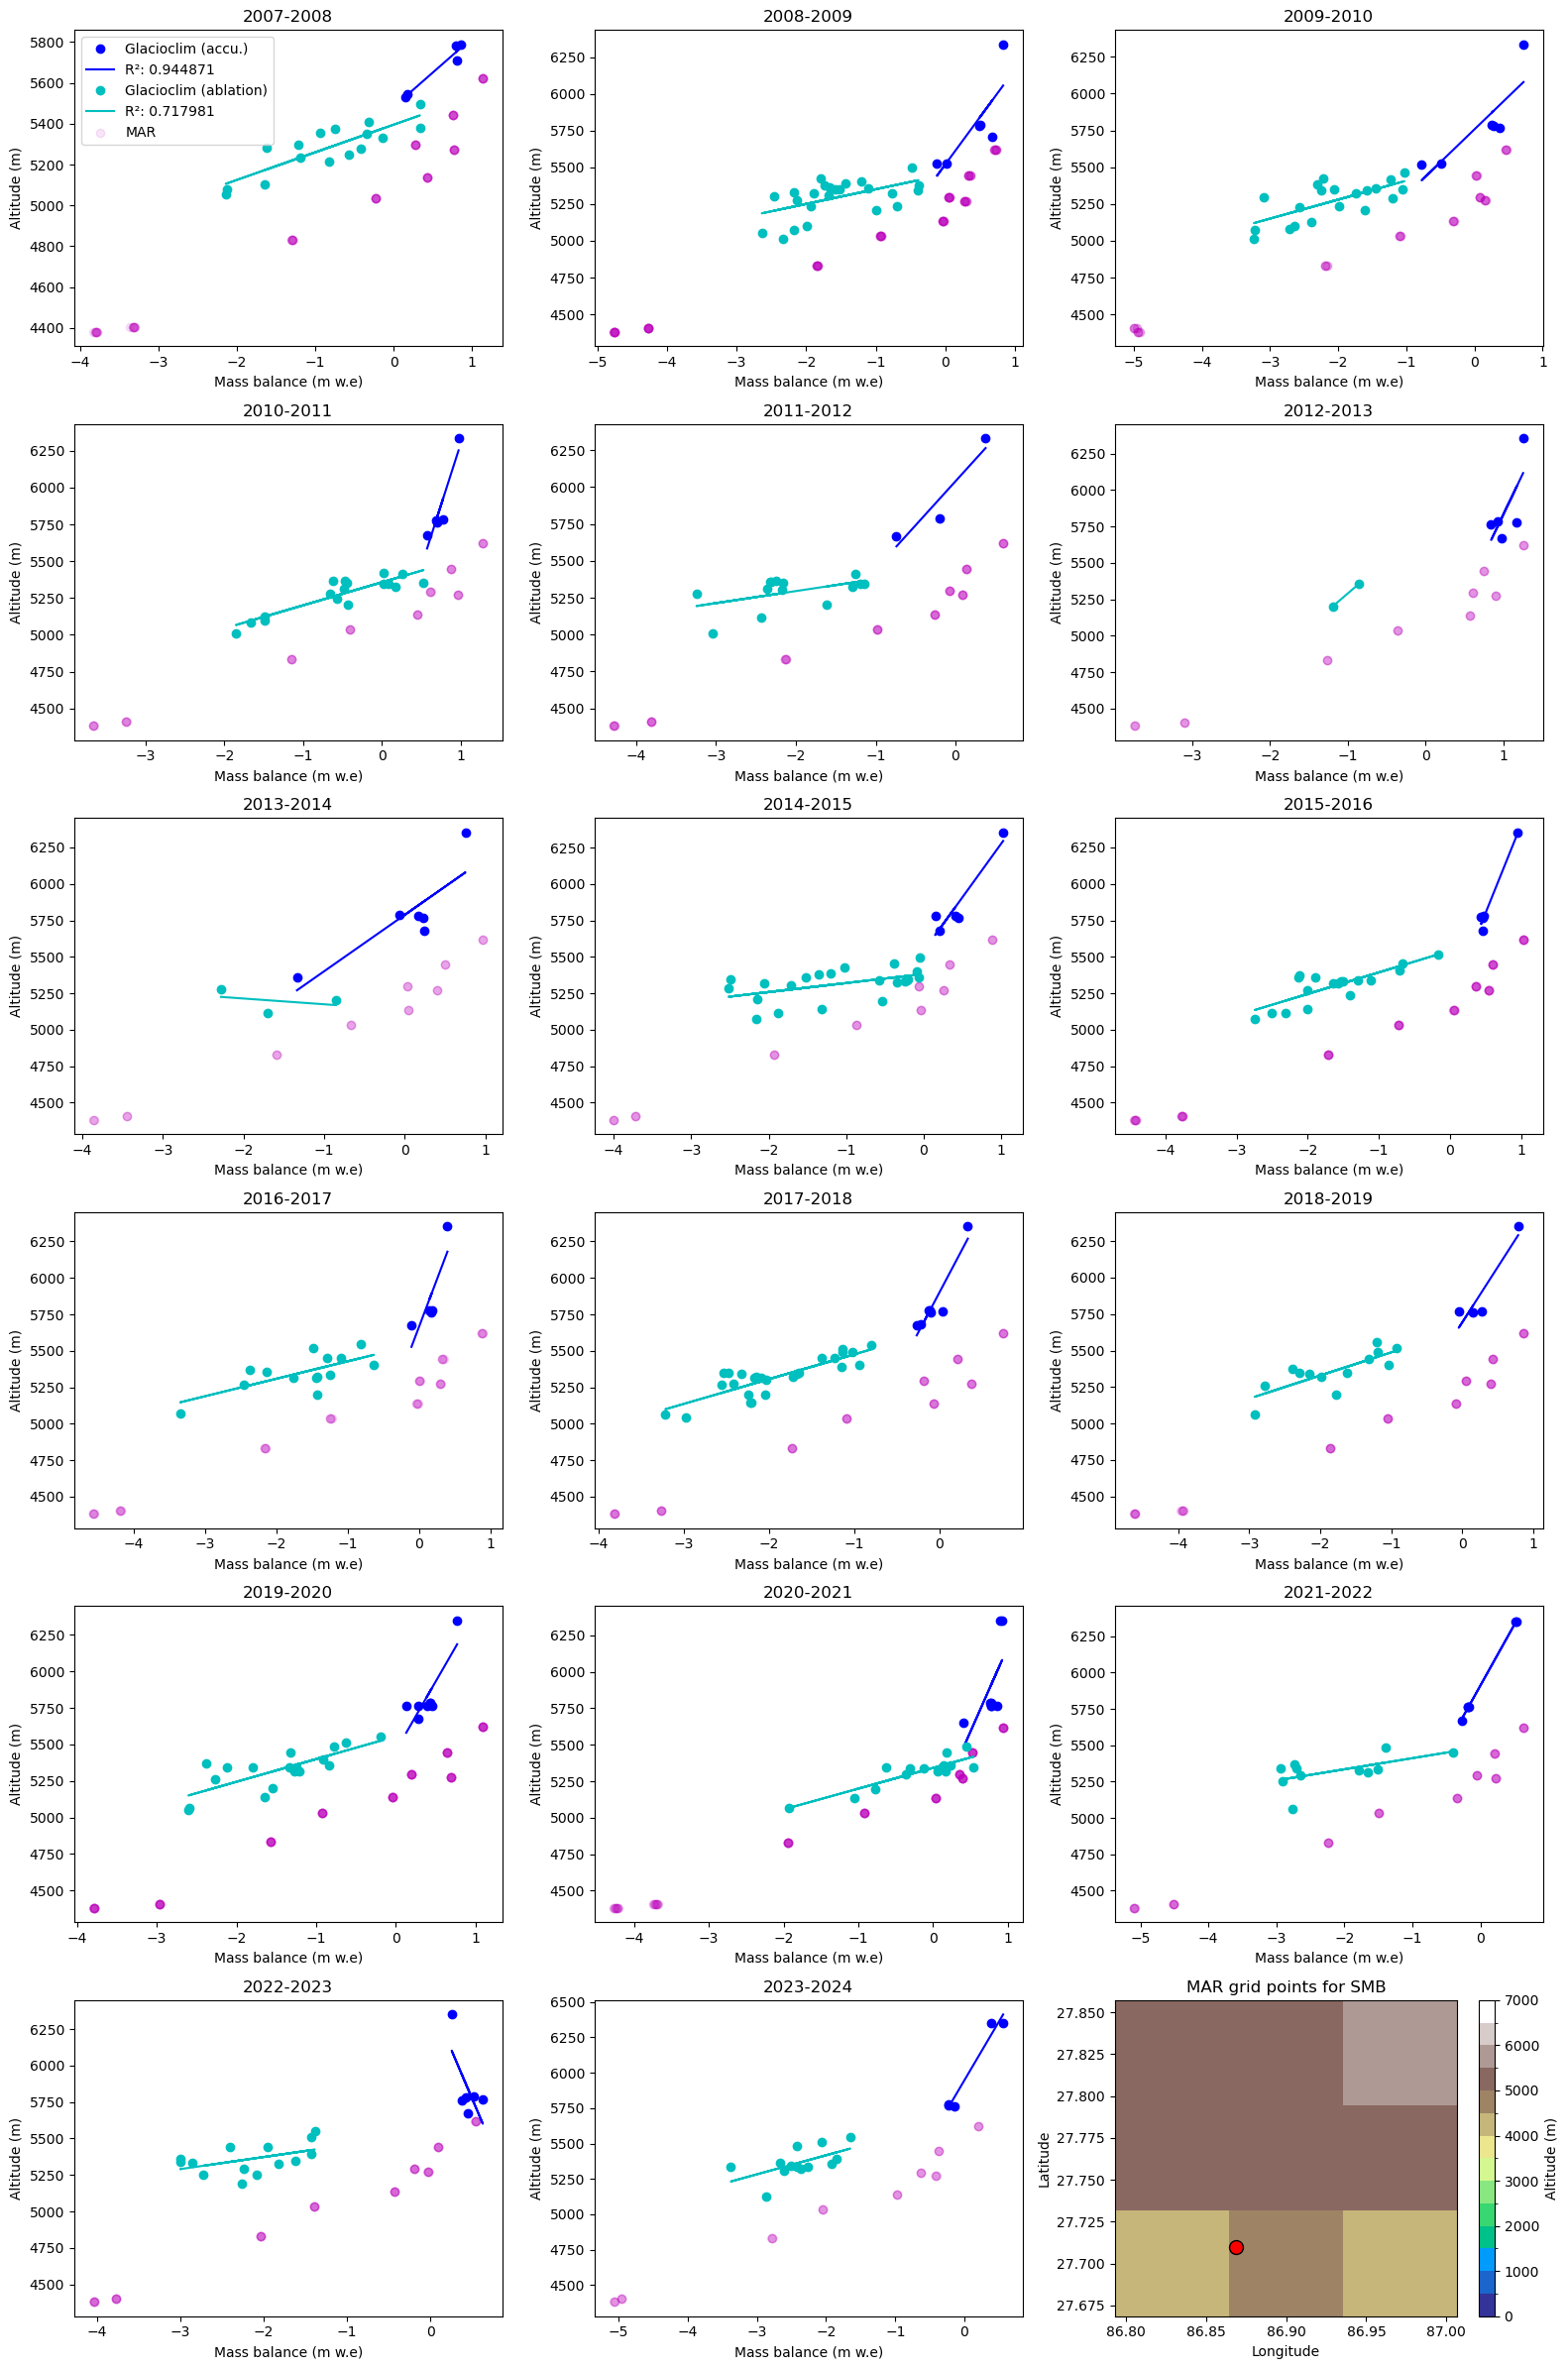

In [37]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq_bug/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

n = len(yy)-2
col = 3
line = int(np.ceil(n/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))



for j in range(n):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    
    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() 
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]

    # Parcours l'intervale/subset des deux dates et supprime les doublons trouvés entre deux intervalles strictement identiques. Remets les indices en ordre après avoir supprimé les doublons
    df_clear = df.drop_duplicates(subset = ["Date_start", "Date_end"])
    df_clear = df_clear.dropna(subset = ["Date_start", "Date_end"]).reset_index(drop=True) # Supprime les valeurs NaT (une date a été trouvée sur les deux)
    nperiod = len(df_clear)

    MAR_label = True # Affichage d'un seul label de MAR

    for i in range(nperiod): # Boucle qui parcours les différents intervalles de date pour une même année
        date_obs = df_clear.loc[i, "Date_end"].replace(hour=12, minute=0, second=0) # Récupère la date de la mesure SMB
        # Ici .loc va chercher dans df_clear les valeurs par indices (i) d'où l'intérêt de reset l'indice. Contrairement à iloc qui va chercher la position peu importe l'indice

        date_ref = df_clear.loc[i, "Date_start"].replace(hour=12, minute=0, second=0) # Récupère la précédente date de mesure de SMB pour cette balise
    
        SMB_day3 = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=slice(iY, iY+3), X=slice(iX-1, iX+2)) # Valeur du SMB à la date exact de l'obs (glacioclim)
        SMB_sum3 = SMB_day3.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
        SMB_MAR3 = SMB_sum3.values.flatten() 

        SH_MAR3 = ds_SH.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)).values.flatten() # Altitude des grilles de MAR

        if MAR_label: # Affiche la légende du point MAR une fois, quand la condition est respectée
            ax.scatter(SMB_MAR3, SH_MAR3, color="m", alpha=0.1, label="MAR") # Affiche le point de MAR correspondant à la date des obs
            MAR_label = False
        else:
            ax.scatter(SMB_MAR3, SH_MAR3, color="m", alpha=0.1)

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
#    ax.set_xlim(-4, 2) # Restriction du domaine 
#    ax.set_ylim(4700, 6400) # Restriction du domaine 
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

####### Grid on last subplot ######
ax = axes[n]
ds_SH3 = ds_SH.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)) # Selectionne le SMB sur les grilles données
ds_lat_mera3 = ds_lat.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2)) # Selectionne les lon lat pour les plot
ds_lon_mera3 = ds_lon.isel(y=slice(iY, iY+3), x=slice(iX-1, iX+2))

x, y = np.meshgrid([0,1,2], [0,1,2])

clevs = np.arange(0, 7500, 500) # Echelle de couleur de topographie de 0 à 7500 tout les 500m d'alt
cmap = plt.get_cmap("terrain") # Palette de couleur pour les reliefs 
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap.N) # Attribut à chaque bande d'altitude une couleur de la palette "terrain"

ax.plot(merap_lon, merap_lat, marker='o', markersize=10, markeredgecolor='black', markerfacecolor='red') # Mera peak

pcm = ax.pcolormesh(ds_lon_mera3, ds_lat_mera3, ds_SH3, cmap=cmap, norm=norm, shading='auto')
fig.colorbar(pcm, ax=ax, label="Altitude (m)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("MAR grid points for SMB")
plt.tight_layout()

# Annual and cumulative SMB 

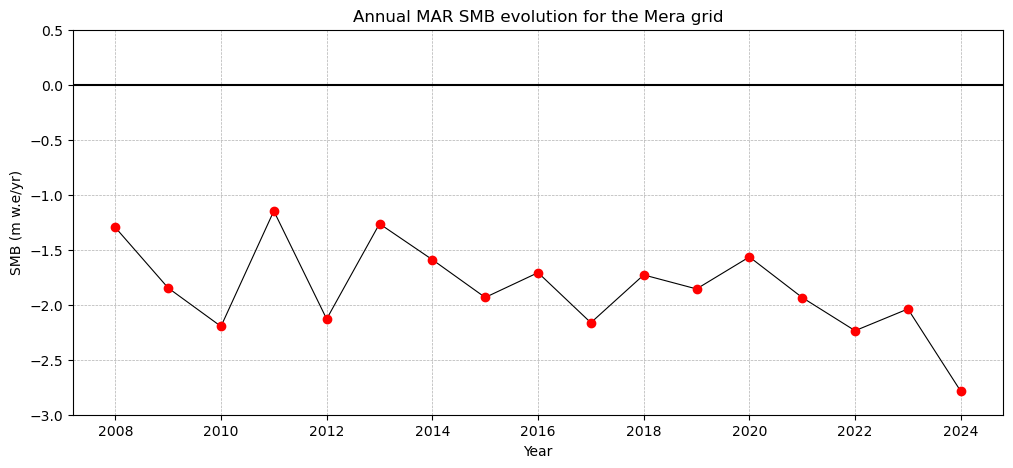

In [38]:
plt.figure(figsize=(12,5))

years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))

plt.plot(years, SMB_list, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r")
plt.axhline(0, color="k", linewidth=1.5) # Affiche une ligne à l'horizontal (ici 0)
plt.ylim(-3,0.5)
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual MAR SMB evolution for the Mera grid")
plt.grid(linestyle = '--', linewidth = 0.5)


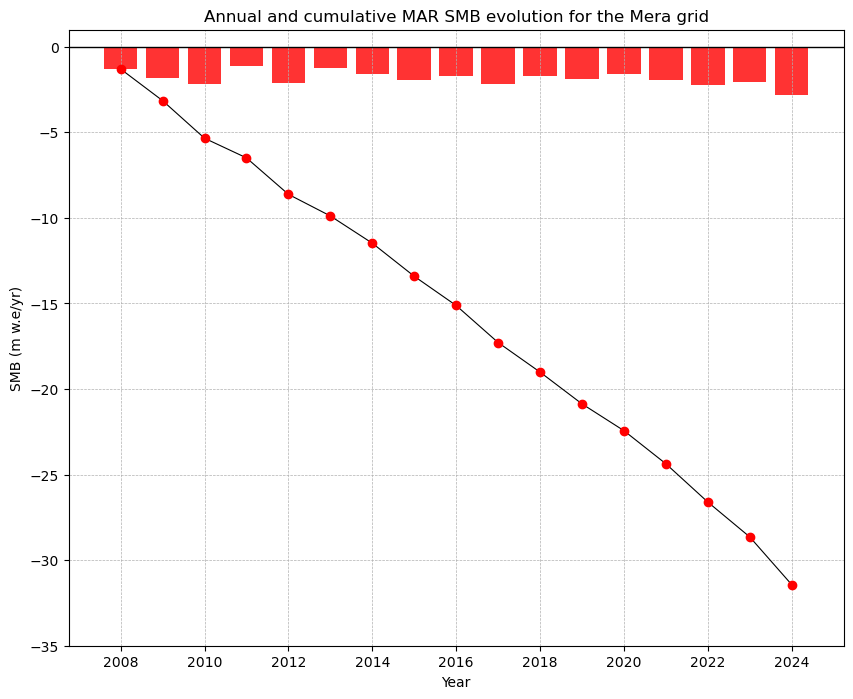

In [39]:
plt.figure(figsize=(10,8))

years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))

SMB_cum = np.cumsum(SMB_list)

plt.bar(years, SMB_list, color="r", alpha=0.8, width=0.8) # SMB annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r", markeredgecolor="r") # Cumulative SMB
plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.ylim(-35,1)
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative MAR SMB evolution for the Mera grid")
plt.grid(linestyle = '--', linewidth = 0.5)


In [40]:
# Observation d'un point de grille 3 case au nord par rapport au Mera
iYN = iY + 3
iXN = iX 

SMB_MAR07-08 = 1.0260371 m w.e/yr
SMB_MAR08-09 = 0.3013789 m w.e/yr
SMB_MAR09-10 = 0.34187108 m w.e/yr
SMB_MAR10-11 = 0.95816797 m w.e/yr
SMB_MAR11-12 = 0.12594531 m w.e/yr
SMB_MAR12-13 = 0.7758789 m w.e/yr
SMB_MAR13-14 = 0.5425293 m w.e/yr
SMB_MAR14-15 = 0.40599024 m w.e/yr
SMB_MAR15-16 = 1.05825 m w.e/yr
SMB_MAR16-17 = 0.31087306 m w.e/yr
SMB_MAR17-18 = 0.21491212 m w.e/yr
SMB_MAR18-19 = 0.6416914 m w.e/yr
SMB_MAR19-20 = 0.87377346 m w.e/yr
SMB_MAR20-21 = 0.65925974 m w.e/yr
SMB_MAR21-22 = -0.0837832 m w.e/yr
SMB_MAR22-23 = 0.22638868 m w.e/yr
SMB_MAR23-24 = -0.15042187 m w.e/yr
Grid alt = 5297.713 m


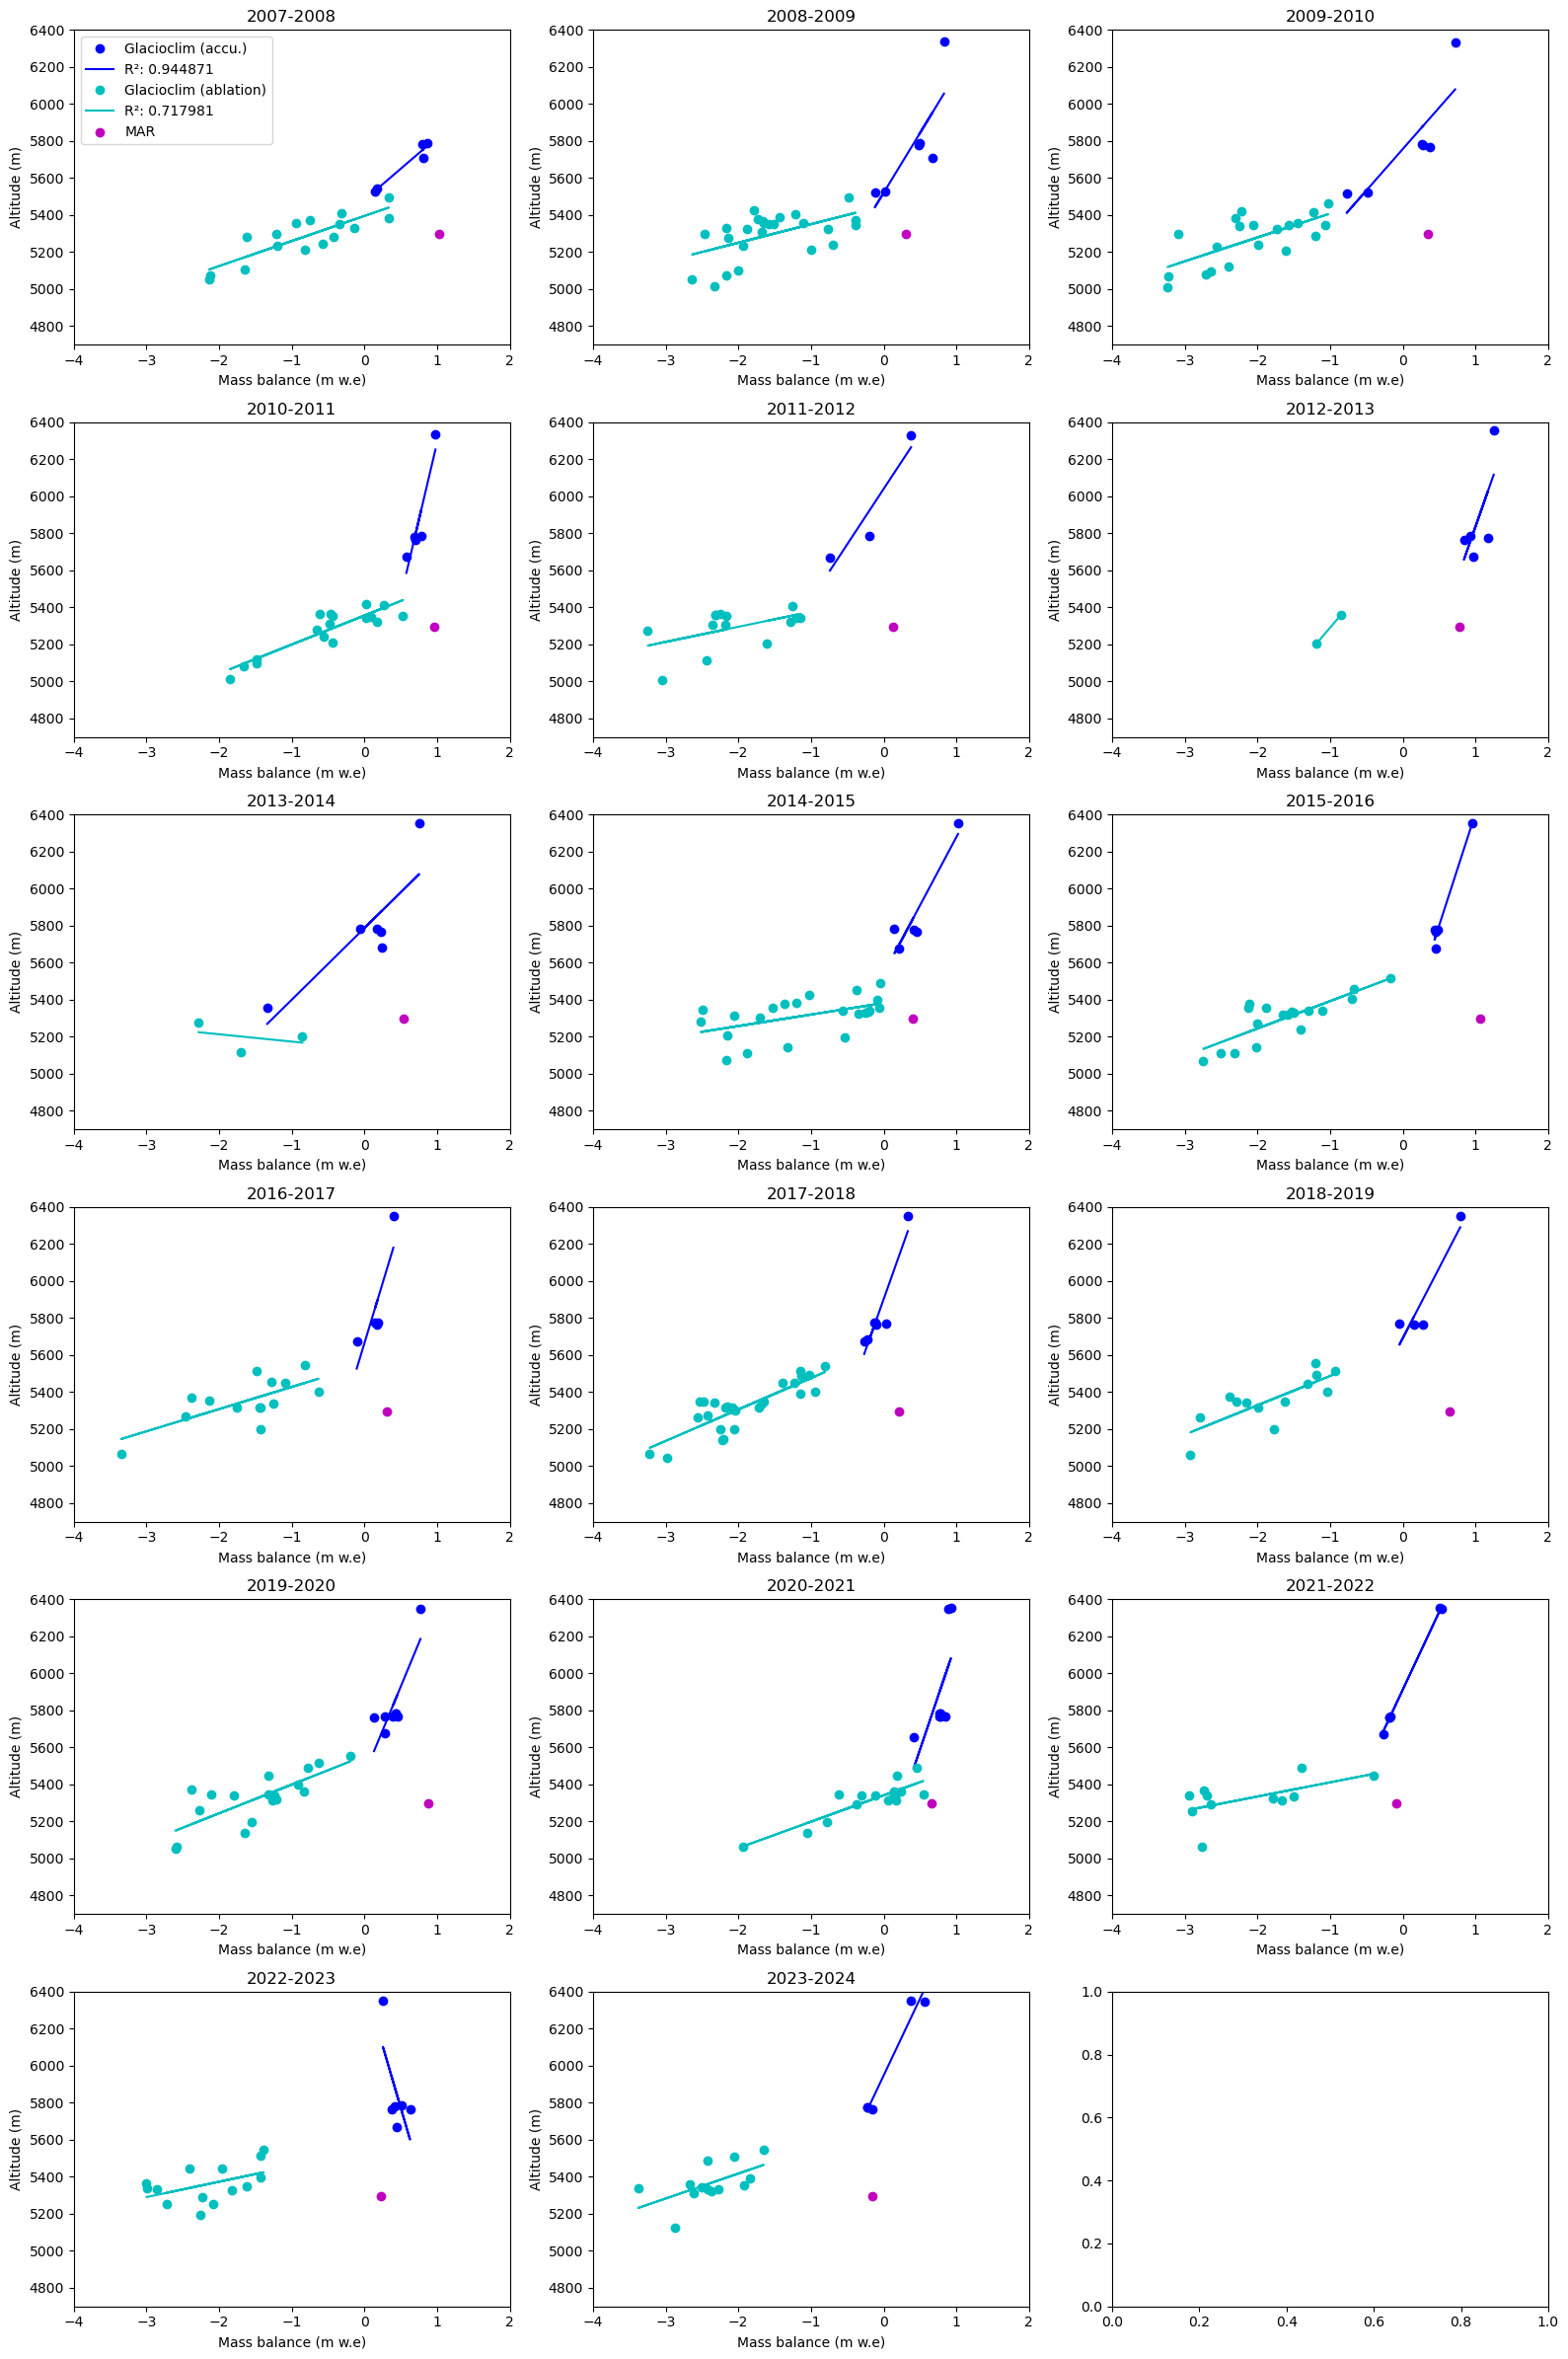

In [42]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list = []

for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4] # Je pensais que le format de date qui diffère de glacioclim à MAR était un pb, mais excel est bien en format datetime et non texte donc cela fonctionne sans correction

    date_ref = df["Date_start"].iloc[4] # Récupère la précédente date de mesure de SMB pour cette balise

    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        # La régression linéaire contient naturellement des informations comme slope = pente de regression / intercept = ordonnée à l'origine / rvalue = coeff de corrélation / pvalue
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=iYN, X=iXN) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list.append(SMB_MAR)
    print('SMB_MAR'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR, 'm w.e/yr')
#    print('Date_MAR:', ds_SMBy.sel(TIME=date_obs).TIME.values) # Affiche la date dans le fichier

    SH_MAR = ds_SH.isel(y=iYN, x=iXN) # Altitude de la grille de MAR au Peak Mera (coord iYN,iXN)
    Grid_alt = SH_MAR.values
    
    ax.scatter(SMB_MAR, SH_MAR, color="m", label="MAR") # Affiche le point de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-4, 2)
    ax.set_ylim(4700, 6400)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

print('Grid alt =', Grid_alt, 'm')
plt.tight_layout()

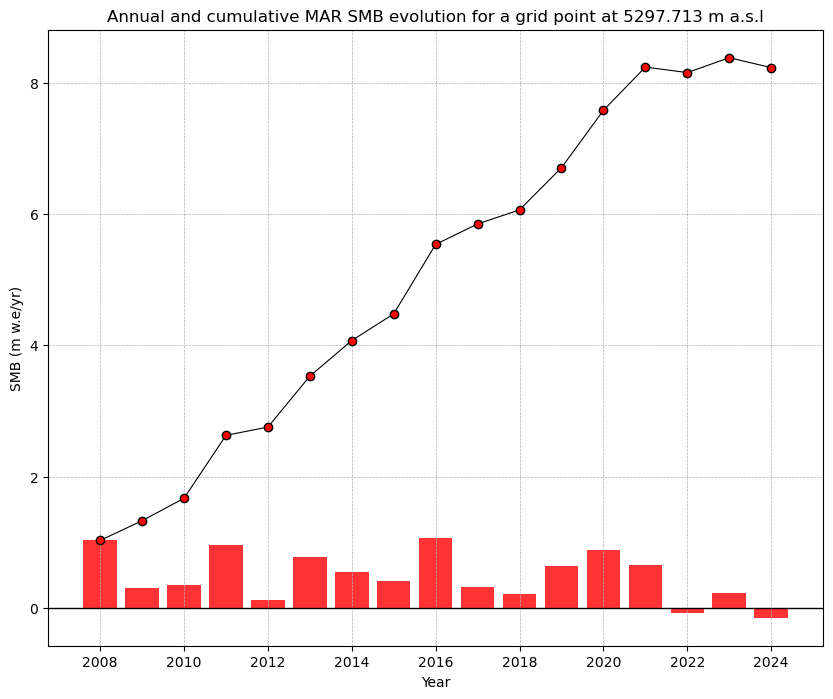

In [43]:
plt.figure(figsize=(10,8))

years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))

SMB_cum = np.cumsum(SMB_list)

plt.bar(years, SMB_list, color="r", alpha=0.8, width=0.8) # SMB annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r") # Cumulative SMB
plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative MAR SMB evolution for a grid point at "+str(Grid_alt)+" m a.s.l")
plt.grid(linestyle = '--', linewidth = 0.5)

In [44]:
# Observation d'un point de grille 3 case au nord et 1 à l'est par rapport au Mera
iYNE = iY + 3
iXNE = iX + 1

SMB_MAR07-08 = 1.6695195 m w.e/yr
SMB_MAR08-09 = 1.1721562 m w.e/yr
SMB_MAR09-10 = 1.1519902 m w.e/yr
SMB_MAR10-11 = 1.6841016 m w.e/yr
SMB_MAR11-12 = 1.0714297 m w.e/yr
SMB_MAR12-13 = 1.5110469 m w.e/yr
SMB_MAR13-14 = 1.3121114 m w.e/yr
SMB_MAR14-15 = 1.2582304 m w.e/yr
SMB_MAR15-16 = 1.7500196 m w.e/yr
SMB_MAR16-17 = 1.2921035 m w.e/yr
SMB_MAR17-18 = 1.1051426 m w.e/yr
SMB_MAR18-19 = 1.4183867 m w.e/yr
SMB_MAR19-20 = 1.6767403 m w.e/yr
SMB_MAR20-21 = 1.6157548 m w.e/yr
SMB_MAR21-22 = 0.81574607 m w.e/yr
SMB_MAR22-23 = 0.83548826 m w.e/yr
SMB_MAR23-24 = 0.7079356 m w.e/yr
Grid alt = 5700.3403 m


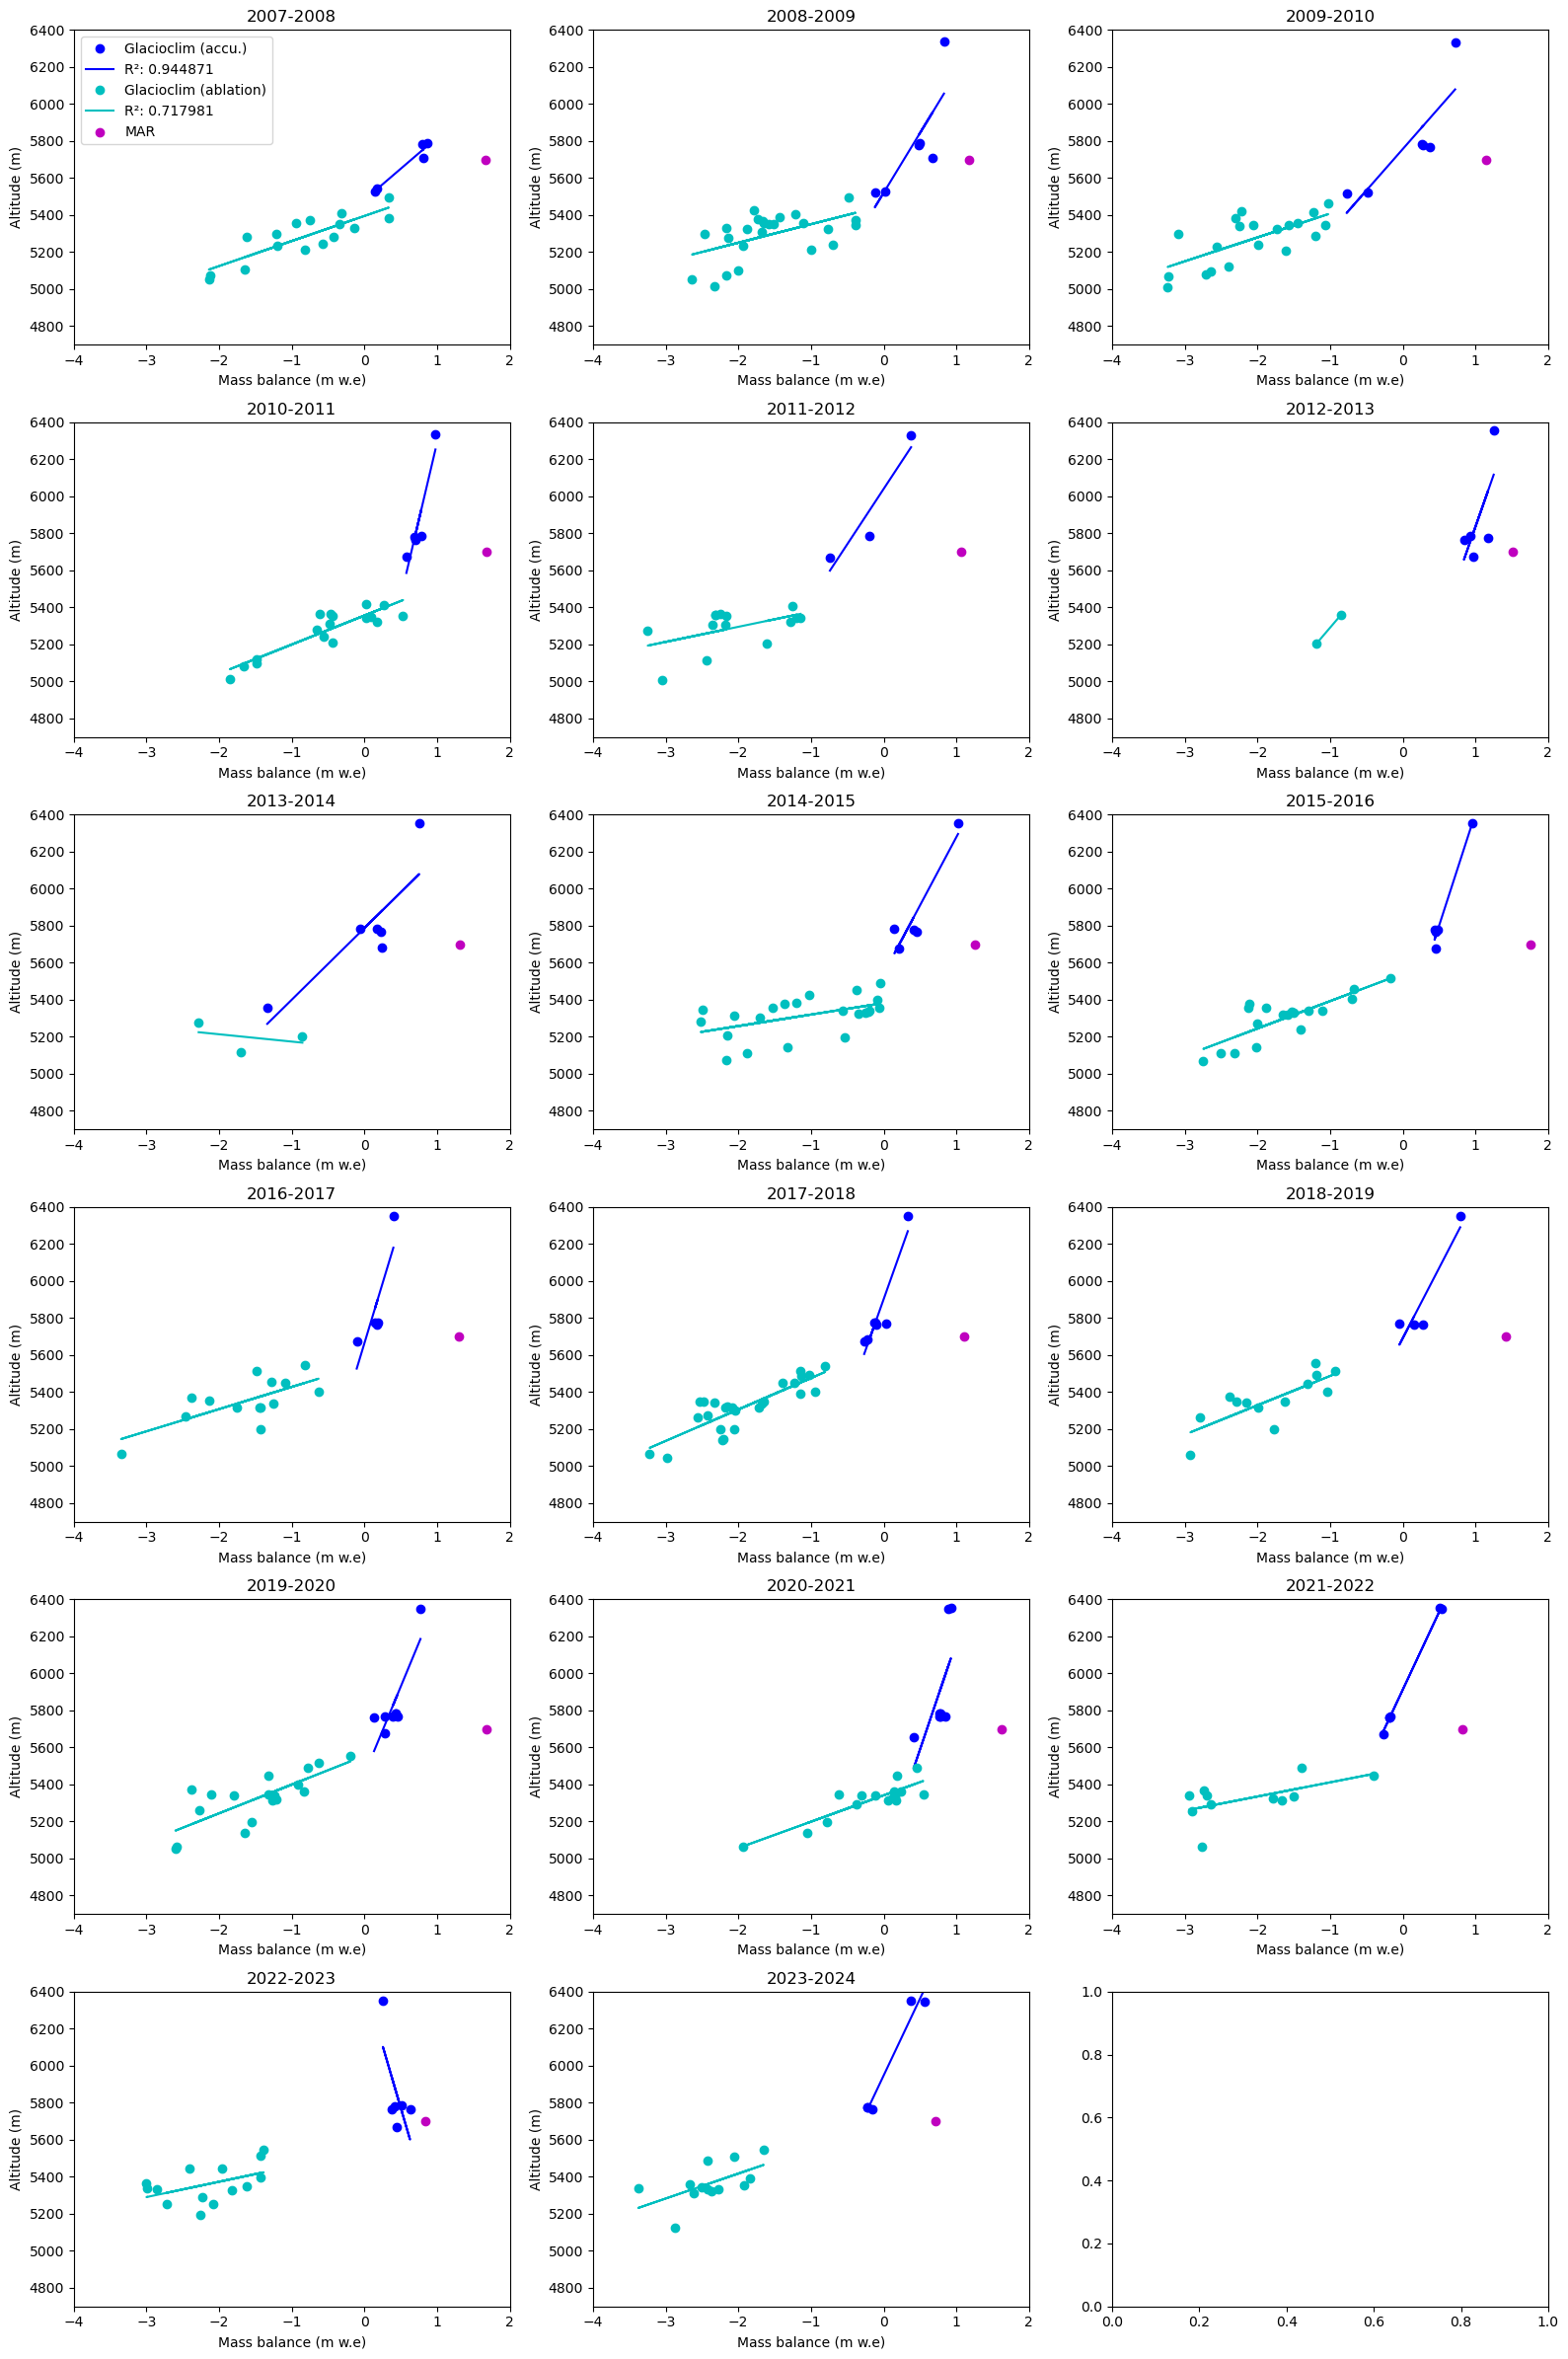

In [45]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list = []

for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4] # Je pensais que le format de date qui diffère de glacioclim à MAR était un pb, mais excel est bien en format datetime et non texte donc cela fonctionne sans correction

    date_ref = df["Date_start"].iloc[4] # Récupère la précédente date de mesure de SMB pour cette balise

    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        # La régression linéaire contient naturellement des informations comme slope = pente de regression / intercept = ordonnée à l'origine / rvalue = coeff de corrélation / pvalue
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=iYNE, X=iXNE) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list.append(SMB_MAR)
    print('SMB_MAR'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR, 'm w.e/yr')
#    print('Date_MAR:', ds_SMBy.sel(TIME=date_obs).TIME.values) # Affiche la date dans le fichier

    SH_MAR = ds_SH.isel(y=iYNE, x=iXNE) # Altitude de la grille de MAR au Peak Mera (coord iYNE,iXNE)
    Grid_alt = SH_MAR.values
    
    ax.scatter(SMB_MAR, SH_MAR, color="m", label="MAR") # Affiche le point de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-4, 2)
    ax.set_ylim(4700, 6400)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

print('Grid alt =', Grid_alt, 'm')
plt.tight_layout()

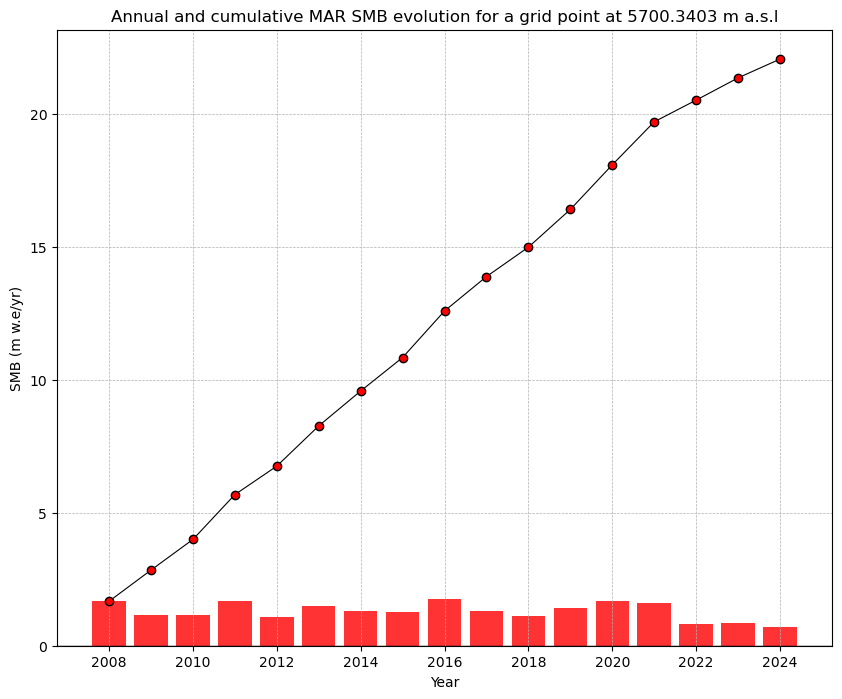

In [46]:
plt.figure(figsize=(10,8))

years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))

SMB_cum = np.cumsum(SMB_list)

plt.bar(years, SMB_list, color="r", alpha=0.8, width=0.8) # SMB annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r") # Cumulative SMB
plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative MAR SMB evolution for a grid point at "+str(Grid_alt)+" m a.s.l")
plt.grid(linestyle = '--', linewidth = 0.5)

In [47]:
# Observation d'un point de grille 3 case au nord et 1 à l'est par rapport au Mera
iY_everest = iY + 5
iX_everest = iX 

SMB_MAR07-08 = 1.7933154 m w.e/yr
SMB_MAR08-09 = 1.4908535 m w.e/yr
SMB_MAR09-10 = 1.5106797 m w.e/yr
SMB_MAR10-11 = 1.8563701 m w.e/yr
SMB_MAR11-12 = 1.4644678 m w.e/yr
SMB_MAR12-13 = 1.7657129 m w.e/yr
SMB_MAR13-14 = 1.680125 m w.e/yr
SMB_MAR14-15 = 1.5467998 m w.e/yr
SMB_MAR15-16 = 1.9856856 m w.e/yr
SMB_MAR16-17 = 1.5806211 m w.e/yr
SMB_MAR17-18 = 1.5938818 m w.e/yr
SMB_MAR18-19 = 1.8291484 m w.e/yr
SMB_MAR19-20 = 2.0739589 m w.e/yr
SMB_MAR20-21 = 1.8807548 m w.e/yr
SMB_MAR21-22 = 1.2393018 m w.e/yr
SMB_MAR22-23 = 1.3886465 m w.e/yr
SMB_MAR23-24 = 1.4694023 m w.e/yr
Grid alt = 6224.9365 m


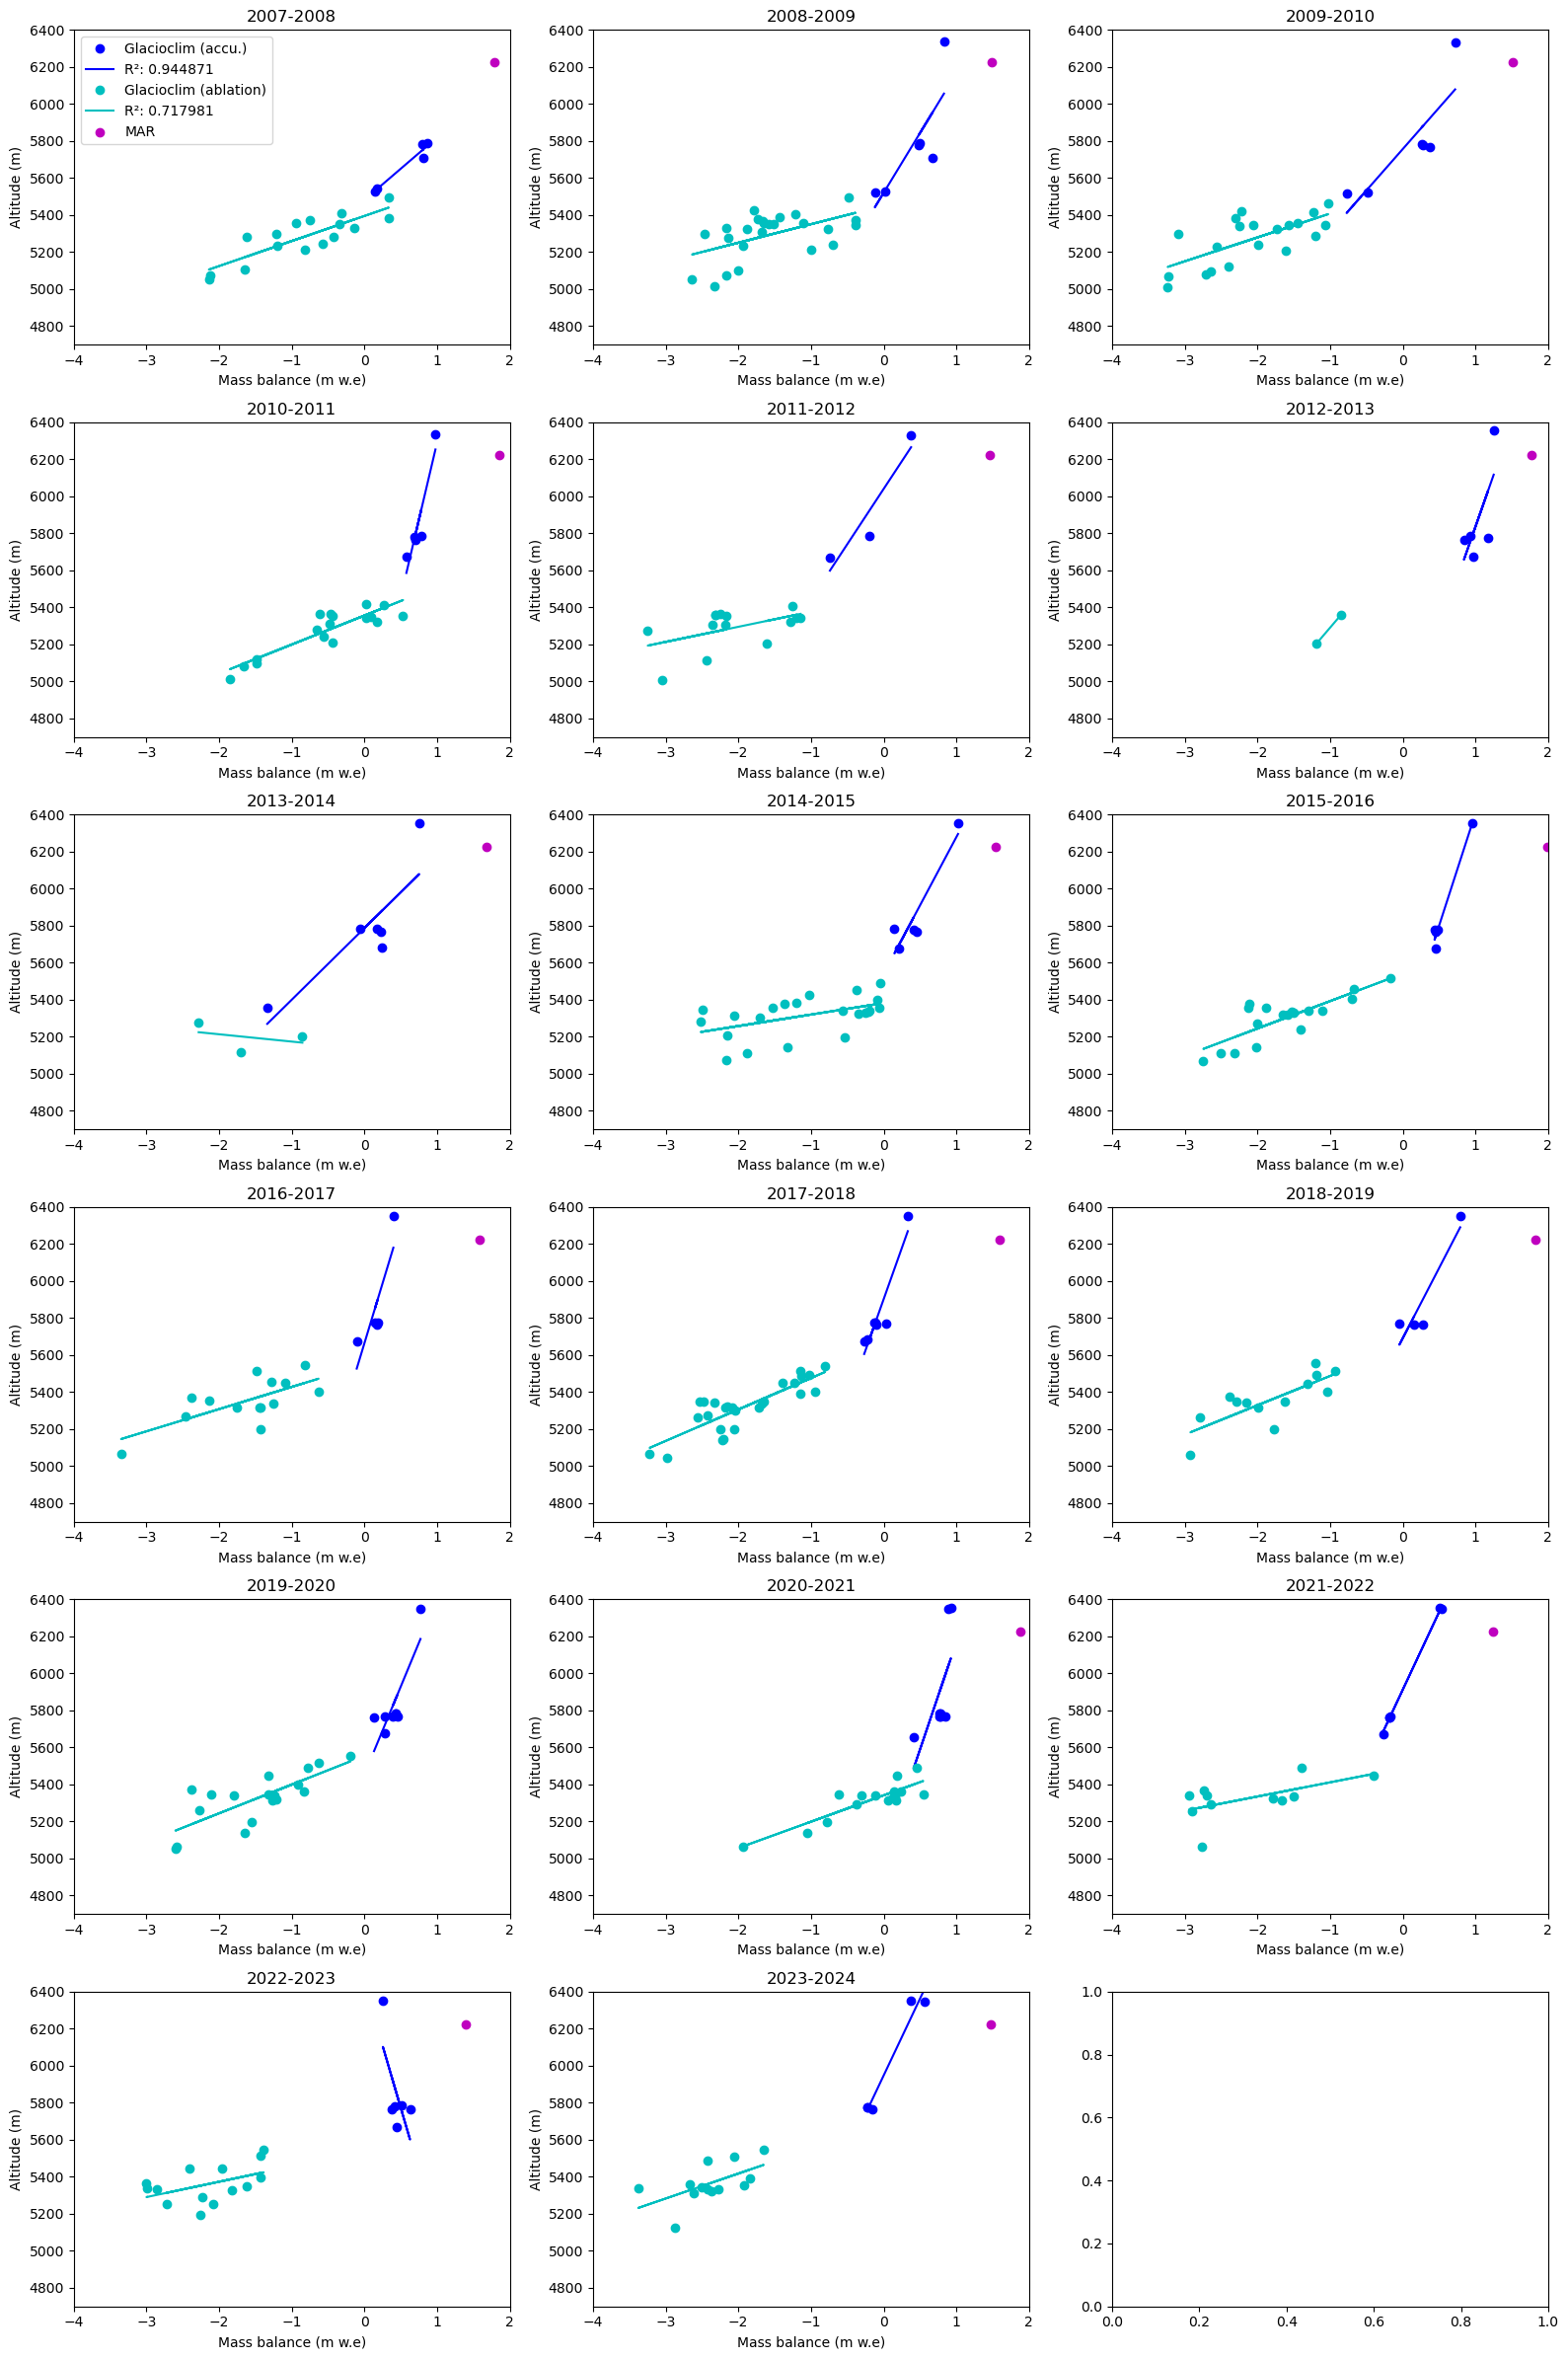

In [48]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

###### Defining subplot ######
yy = [f"{i:02}" for i in range(7, 26)] # Liste des années sous le format yy

nyy = len(yy)-2
col = 3
line = int(np.ceil(nyy/col)) # Arrondi à l'entier supérieur le nombre de colonne à plot, et le met au format 'nombre entier'
fig, axes = plt.subplots(line,col,figsize=(16,4*line))
axes = axes.flatten() # Transforme le tableau 2D en tableau 1D (accessible avec 1 indice (j))

SMB_list = []

for j in range(nyy):
    ax = axes[j] # Remplissage subplot avec indice de la boucle

###### OBS_data loading and sorting ######    
    df = pd.read_excel('/home/turpinli/Mera_SMB/AnnualMB_Mera_'+yy[j]+'_'+yy[j+1]+'.xlsx', header=1) #pandas permet ici de lire les fichiers .xlsx et prenant les colonnes à partir de la 2ème ligne
    date_obs = df["Date_end"].iloc[4] # Je pensais que le format de date qui diffère de glacioclim à MAR était un pb, mais excel est bien en format datetime et non texte donc cela fonctionne sans correction

    date_ref = df["Date_start"].iloc[4] # Récupère la précédente date de mesure de SMB pour cette balise

    MB = df.filter(regex=r"^Mass balance \(").columns[0] # Regex recupère les données dans la colonne Mass balance, peut importe ce qui suit dans la chaine de caractères 
    df[MB] = pd.to_numeric(df[MB], errors="coerce") # Force la colonne à prendre la forme d'un nombre (car unité en haut de colonne)
    df["Altitude_end"] = pd.to_numeric(df["Altitude_end"], errors="coerce") # Coerce donne NaN si la valeur n'est pas convertible en nombre

    df = df.dropna(subset=["Altitude_end",MB]) # Supprime les NaN dans les colonnes

    df_ablation = df[df["#station"].str.match(r"^\d") | (df["#station"] == "AWS")] # Catégorise les stations qui commencent par un chiffre ou qui sont strictement AWS, en ablaion
    df_accu = df[~(df["#station"].str.match(r"^\d") | (df["#station"] == "AWS"))] # Le ~ est la condition "not" --> Tout le reste / (r"^\d" identifie les chiffres) et "|" vérifie les deux conditions 

    
###### Accumulation ######
    x_accu = df_accu[MB]
    y_accu = df_accu["Altitude_end"]

    ax.plot(x_accu,y_accu, linestyle="", marker="o",color='b', label='Glacioclim (accu.)')
    
    if len(x_accu)>=2: # Regression linéaire si 2 valeurs ou plus
        res = stats.linregress(x_accu, y_accu) # Régression linéaire sur les deux séries de données
        # La régression linéaire contient naturellement des informations comme slope = pente de regression / intercept = ordonnée à l'origine / rvalue = coeff de corrélation / pvalue
        ax.plot(x_accu,res.intercept+res.slope*x_accu, 'b', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)

    
##### Ablation ######
    x_ablation = df_ablation[MB]
    y_ablation = df_ablation["Altitude_end"]

    ax.plot(x_ablation,y_ablation, linestyle="", marker="o", color='c', label='Glacioclim (ablation)')
    
    if len(x_ablation)>=2:
        res = stats.linregress(x_ablation, y_ablation) # Régression linéaire sur les deux séries de données
        ax.plot(x_ablation,res.intercept+res.slope*x_ablation, 'c', label=f"R²: {res.rvalue**2:.6f}") # \np-value: {res.pvalue:.6g}") # Trace x par y =ax+b=slope*x+intercept)
    

###### MAR_data loading and sorting  ######    
    file = variable+'_daysum_MARv3.14_ER5_spin2_GRq_20'+yy[j+1]+'.nc'
    ds_SMBy = xr.open_dataset(DataPath+file).SMB.isel(SECTOR=0).load() # Sector correspond à des types d'occupation des sols en % (ex: 30% de la grille occupé par de la végétation)
    ds_SMBy = ds_SMBy[:,k:-k,k:-k]
    
    SMB_day = ds_SMBy.sel(TIME=slice(date_ref, date_obs)).isel(Y=iY_everest, X=iX_everest) # Valeurs du SMB entre les deux dates de mesures (glacioclim)
    SMB_sum = SMB_day.sum(dim='TIME')/1000 # Somme l'entièreté de ces valeurs sur la période, et rapporte les millimètres en mètres
    SMB_MAR = SMB_sum.values
    SMB_list.append(SMB_MAR)
    print('SMB_MAR'+yy[j]+'-'+yy[j+1]+' =', SMB_MAR, 'm w.e/yr')
#    print('Date_MAR:', ds_SMBy.sel(TIME=date_obs).TIME.values) # Affiche la date dans le fichier

    SH_MAR = ds_SH.isel(y=iY_everest, x=iX_everest) # Altitude de la grille de MAR au Peak Mera (coord iY_everest,iX_everest)
    Grid_alt = SH_MAR.values
    
    ax.scatter(SMB_MAR, SH_MAR, color="m", label="MAR") # Affiche le point de MAR correspondant à la date des obs

###### Graphic features ######
    ax.set_title(f"20{yy[j]}-20{yy[j+1]}")
    ax.set_xlabel("Mass balance (m w.e)")
    ax.set_ylabel("Altitude (m)")
    ax.set_xlim(-4, 2)
    ax.set_ylim(4700, 6400)
    
    if j == 0: # Affiche la légende pour la première figure
        ax.legend()

print('Grid alt =', Grid_alt, 'm')
plt.tight_layout()

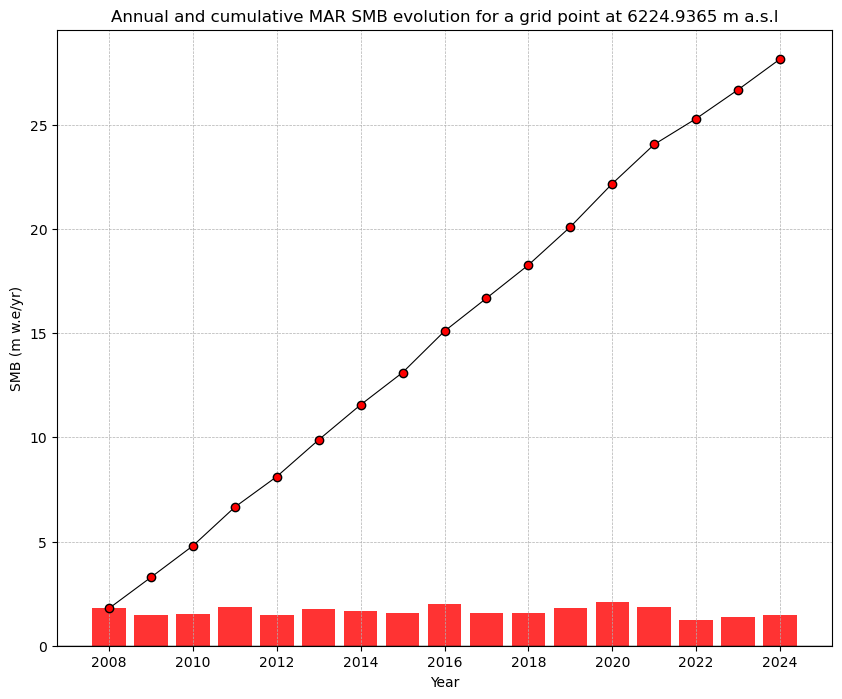

In [49]:
plt.figure(figsize=(10,8))

years = []
for j in range (nyy):
    years.append(int("20"+yy[j+1]))

SMB_cum = np.cumsum(SMB_list)

plt.bar(years, SMB_list, color="r", alpha=0.8, width=0.8) # SMB annuel sous forme de bar 
plt.plot(years, SMB_cum, color="k", linewidth=0.8, marker="o", markerfacecolor="r") # Cumulative SMB
plt.axhline(0, color="k", linewidth=1) # Affiche une ligne à l'horizontal (ici 0)

plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2)) # Force l'espace sur l'axe des x
plt.xlabel("Year")
plt.ylabel("SMB (m w.e/yr)")
plt.title("Annual and cumulative MAR SMB evolution for a grid point at "+str(Grid_alt)+" m a.s.l")
plt.grid(linestyle = '--', linewidth = 0.5)